<!-- Google Fonts -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px;
    border: 2px solid #065f46;
    padding: 10px;
    background: linear-gradient(135deg, #064e3b, #065f46 35%, #047857 70%, #10b981);
    text-align: center;
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #ffffff;
        text-shadow: 2px 2px 5px rgba(0,0,0,0.4);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        💳 Bank Churn 💸
    </h1>
</div>


# 📂 Overview

- **Background** <br>
  In the highly competitive banking industry, retaining existing customers is just as important as acquiring new ones. Customer churn can significantly impact profitability, making it essential for banks to identify customers who are likely to leave. By understanding customer demographics, financial behavior, engagement levels, and risk profiles, banks can develop targeted retention strategies and improve long-term customer loyalty.

- **Goal of the Project** <br>
  Using historical customer profile, banking activity, financial, and engagement data, this project aims to build a predictive model that estimates whether a customer is likely to leave the bank. The insights generated from this analysis help financial institutions **improve customer retention**, **identify high-risk customers**, and **optimize personalized marketing and loyalty programs**.

🎯 **Key Features**

**Target Variable**

- `exit`: Customer churn status _(1 = Exited, 0 = Retained)_

**Customer Profile** <br>

- `id`: Unique customer identifier
- `full_name`: Customer full name
- `gender`: Gender
- `age`: Customer age
- `married`: Marital status
- `occupation`: Occupation
- `origin_province`: Province of origin

**Financial Information** <br>

- `credit_sco`: Credit score
- `balance`: Account balance
- `monthly_ir`: Monthly income

**Banking Relationship** <br>

- `tenure_ye`: Customer tenure with the bank (years)
- `nums_card`: Number of bank cards owned
- `nums_service`: Number of banking services used
- `active_member`: Active membership status

**Customer Activity** <br>

- `last_active_date`: Date of the customer's last activity
- `last_transaction_month`: Month of the last transaction
- `created_date`: Customer account creation date

**Customer Analytics** <br>

- `customer_segment`: Customer segment
- `engagement_score`: Customer engagement score
- `loyalty_level`: Loyalty level
- `digital_behavior`: Digital banking behavior
- `risk_score`: Customer risk score
- `risk_segment`: Risk category
- `cluster_group`: Customer cluster generated through segmentation

**Location Information** <br>

- `address`: Customer address
- `origin_province`: Province of origin

📁 Files Provided

- `bank_churn_dataset.csv`: Main dataset used for exploratory data analysis and predictive modeling.

🚀 Project Objective

The primary objective of this project is to **perform exploratory data analysis (EDA)** and develop machine learning models to predict whether a customer is likely to leave the bank.

By leveraging these insights, banks can:

- Improve **customer retention strategies**
- Identify **customers with high churn risk**
- Enhance **customer segmentation and personalization**
- Increase **customer engagement and loyalty**
- Reduce **customer attrition and revenue loss**


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #064e3b, #065f46 35%, #047857 70%, #10b981);
    text-align: center; 
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 5px rgba(0,0,0,0.4);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [ ]:
import sys
from pathlib import Path

# Add project root to PYTHONPATH
ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

# Core Libraries
import pandas as pd              # Data handling
import numpy as np               # Numerical operations
import seaborn as sns            # Statistical plots
import matplotlib.pyplot as plt  # Visualization
from visualization.visualization_plots import (
    plot_numerical_features_v2,
    categorical_distribution,
    plot_feature_importance_comparison
)

# Project Utilities
from utils.logger import LoggerConfig
from utils.utils import Utils
from config.config import CFG
from utils.stats_utils import StatUtils
from preprocessing.validation import DataValidator

# Modeling Utilities
from models.benchmark import *
from models.oof import *

# Hyperparameter Tuning
from models.catboost_tuning import *
from models.lgbm_tunning import *
from models.xgboost_tuning import *

# Notebook Display
from IPython.display import display, HTML

# Data Splitting & Preprocessing
from sklearn.model_selection import StratifiedShuffleSplit

# Evaluation
from sklearn.metrics import classification_report

# Optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Environment Settings
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", None)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #064e3b, #065f46 35%, #047857 70%, #10b981);
    text-align: center; 
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 5px rgba(0,0,0,0.4);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>


In [2]:
# Initialize notebook logger
logger = LoggerConfig.setup_logger()

# Load datasets safely
df = Utils.read_csv_safe(path=CFG.DATA_PATH, logger=logger,
                         encodings=CFG.DEFAULT_ENCODING).pipe(Utils.clean_columns)

2026-07-24 18:58:21 | INFO     | Logging configured: level=DEBUG, format=colored
2026-07-24 18:58:21 | INFO     | Loaded file with encoding: utf-8 | Shape: (80000, 26)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #064e3b, #065f46 35%, #047857 70%, #10b981);
    text-align: center; 
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 5px rgba(0,0,0,0.4);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [3]:
# Data Preview
display(df.head())

,id,full_name,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,tenure_ye,married,nums_card,nums_service,active_member,last_active_date,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,1,Đặng Văn Vũ,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000,Phường An Hội (BT),TP. Hồ Chí Minh,0,2,4,8,True,03/04/2025,91038993,27/02/2025,False,Priority,90,Bronze,mobile,0.0359,Low,4
1,2,Bùi Hữu Phúc,689,male,45,Nội trợ/Sinh viên,1927416,5000000,Phường Bến Thành (Q1),Đồng Nai,3,1,3,2,True,14/05/2025,3255569,29/07/2021,False,Mass,63,Gold,mobile,0.2664,Low,2
2,3,Lê Văn Mai,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,4,0,2,8,False,10/09/2021,0,03/03/2021,False,Priority,36,Silver,offline,0.1343,Low,4
3,4,Dương Trần Nhiên,766,male,44,Chủ Doanh nghiệp nhỏ,50615501,79000000,Phường 7 (Q7),TP. Hồ Chí Minh,3,0,4,3,False,04/03/2025,0,12/02/2022,False,Priority,23,Bronze,offline,0.2185,Low,4
4,5,Dương Thu Linh,677,female,77,Giáo viên/Giảng viên,40532432,25000000,Phường Thắng Lợi (Q10),TP. Hồ Chí Minh,2,1,4,3,False,06/08/2022,0,24/07/2022,False,Emerging,23,Bronze,offline,0.2942,Low,2


In [4]:
# Display information about the DataFrames
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      80000 non-null  int64  
 1   full_name               80000 non-null  object 
 2   credit_sco              80000 non-null  int64  
 3   gender                  80000 non-null  object 
 4   age                     80000 non-null  int64  
 5   occupation              80000 non-null  object 
 6   balance                 80000 non-null  int64  
 7   monthly_ir              80000 non-null  int64  
 8   address                 80000 non-null  object 
 9   origin_province         80000 non-null  object 
 10  tenure_ye               80000 non-null  int64  
 11  married                 80000 non-null  int64  
 12  nums_card               80000 non-null  int64  
 13  nums_service            80000 non-null  int64  
 14  active_member           80000 non-null

<div style="
    background: linear-gradient(135deg, #064e3b, #065f46, #047857);
    color: #f8fafc;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 8px 20px rgba(20,83,45,0.35);
">
<h2 style="color:#f9e79f; margin-top:0;">📊 Insights from Initial Data Exploration</h2>

<b>Dataset Size and Structure</b>

<ul>
<li>The dataset contains <b>80,000 customer records</b> with <b>26 features</b>.</li>
<li>The dataset is sufficiently large for comprehensive <b>Exploratory Data Analysis (EDA)</b>, customer segmentation, churn analysis, and predictive machine learning models.</li>
</ul>

<b>Feature Overview</b>

<ul>
<li>The dataset provides comprehensive information describing customer profiles, banking activities, engagement, and risk characteristics:</li>

<ul>
<li><b>Customer information:</b> <code>credit_sco</code>, <code>gender</code>, <code>age</code>, <code>occupation</code>, <code>married</code>, <code>origin_province</code>.</li>

<li><b>Financial & banking features:</b> <code>balance</code>, <code>monthly_ir</code>, <code>tenure_ye</code>, <code>nums_card</code>, <code>nums_service</code>, <code>active_member</code>.</li>

<li><b>Behavioral features:</b> <code>last_active_date</code>, <code>last_transaction_month</code>, <code>engagement_score</code>, <code>digital_behavior</code>, <code>customer_segment</code>, <code>loyalty_level</code>.</li>

<li><b>Risk-related features:</b> <code>risk_score</code>, <code>risk_segment</code>, <code>cluster_group</code>.</li>
</ul>

<li>The target variable is <code>exit</code>, represented as a <b>binary outcome (True/False)</b>, indicating whether a customer has churned or remained with the bank.</li>
</ul>

<b>Data Quality and Completeness</b>

<ul>

<li>All <b>80,000 observations</b> are complete with <b>no missing values</b> across all features, indicating excellent data quality.</li>

<li>Data types are appropriate and consistent:</li>

<ul>
<li><b>Numerical:</b> int64 and float64</li>
<li><b>Categorical:</b> string</li>
<li><b>Boolean:</b> active membership and churn status</li>
</ul>

<li>Several column names are abbreviated or ambiguous (e.g., <code>credit_sco</code>, <code>monthly_ir</code>, <code>tenure_ye</code>, <code>nums_card</code>, <code>nums_service</code>, and <code>last_transaction_month</code>). These columns will be renamed using more descriptive and standardized names (e.g., <code>credit_score</code>, <code>monthly_income</code>, <code>tenure_years</code>, <code>num_cards</code>, <code>num_services</code>, and <code>last_transaction_amount</code>) to improve code readability, maintain consistency, and better reflect their actual meanings.</li>

<li>Several date-related features (<code>created_date</code> and <code>last_active_date</code>) are currently stored as strings and should be converted to datetime format during preprocessing for time-based analysis.</li>

<li>Identifier columns such as <code>id</code>, <code>full_name</code>, and <code>address</code> are primarily used for identification and are unlikely to contribute to predictive modeling.</li>

</ul>

</div>


In [5]:
# Rename columns for better readability and consistency
df = df.rename(columns={
    "credit_sco": "credit_score",
    "monthly_ir": "monthly_income",
    "tenure_ye": "tenure_years",
    "nums_card": "num_cards",
    "nums_service": "num_services",
    "last_transaction_month": "last_transaction_amount"
})

# Data Preview
display(df.head())

,id,full_name,credit_score,gender,age,occupation,balance,monthly_income,address,origin_province,tenure_years,married,num_cards,num_services,active_member,last_active_date,last_transaction_amount,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,1,Đặng Văn Vũ,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000,Phường An Hội (BT),TP. Hồ Chí Minh,0,2,4,8,True,03/04/2025,91038993,27/02/2025,False,Priority,90,Bronze,mobile,0.0359,Low,4
1,2,Bùi Hữu Phúc,689,male,45,Nội trợ/Sinh viên,1927416,5000000,Phường Bến Thành (Q1),Đồng Nai,3,1,3,2,True,14/05/2025,3255569,29/07/2021,False,Mass,63,Gold,mobile,0.2664,Low,2
2,3,Lê Văn Mai,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,4,0,2,8,False,10/09/2021,0,03/03/2021,False,Priority,36,Silver,offline,0.1343,Low,4
3,4,Dương Trần Nhiên,766,male,44,Chủ Doanh nghiệp nhỏ,50615501,79000000,Phường 7 (Q7),TP. Hồ Chí Minh,3,0,4,3,False,04/03/2025,0,12/02/2022,False,Priority,23,Bronze,offline,0.2185,Low,4
4,5,Dương Thu Linh,677,female,77,Giáo viên/Giảng viên,40532432,25000000,Phường Thắng Lợi (Q10),TP. Hồ Chí Minh,2,1,4,3,False,06/08/2022,0,24/07/2022,False,Emerging,23,Bronze,offline,0.2942,Low,2


In [ ]:
# Numerical Features
num_features = [
    "credit_score",
    "age",
    "balance",
    "monthly_income",
    "last_transaction_amount",
    "engagement_score",
    "risk_score",
]

# Categorical Features
cat_features = [
    "gender",
    "occupation",
    "origin_province",
    "married",
    "active_member",
    "customer_segment",
    "loyalty_level",
    "digital_behavior",
    "risk_segment",
    "cluster_group",
    "tenure_years",
    "num_cards",
    "num_services",
]

# Data Describe
cm = sns.light_palette("green", as_cmap=True)
display(df[num_features].describe().T.style.background_gradient(cmap=cm))

,count,mean,std,min,25%,50%,75%,max
credit_score,80000.000000,684.321137,51.169733,495.000000,649.000000,682.000000,718.000000,800.000000
age,80000.000000,49.381862,15.067480,20.000000,38.000000,47.000000,58.000000,90.000000
balance,80000.000000,61183195.397050,88686198.425266,408663.000000,14625918.250000,30902758.000000,69609941.250000,1000000000.000000
monthly_income,80000.000000,37788200.000000,36551066.202171,3000000.000000,14000000.000000,23000000.000000,47000000.000000,216000000.000000
last_transaction_amount,80000.000000,8831755.094100,33786825.350302,0.000000,0.000000,0.000000,0.000000,600000000.000000
engagement_score,80000.000000,31.725400,23.474862,7.000000,16.000000,22.000000,38.000000,100.000000
risk_score,80000.000000,0.269260,0.091891,0.017300,0.200400,0.277400,0.338900,0.540400


<div style="
    background: linear-gradient(135deg, #064e3b, #065f46, #047857);
    color: #f8fafc;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 8px 20px rgba(20,83,45,0.35);
">

<div style="
    color:#fde68a;
    margin: 0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Descriptive Statistics
</div>

<ul style="line-height: 1.8; padding-left:20px;">

<li><code>credit_score</code>: Customers have an average credit score of approximately <b>684</b>, indicating that most belong to the <b>fair-to-good credit</b> segment. This suggests a relatively healthy customer portfolio with manageable credit risk.</li>

<li><code>age</code>: The average customer age is around <b>49 years</b>, with half of customers between <b>38 and 58 years old</b>. This indicates that the bank primarily serves a mature customer base that is likely to have more stable income and established financial relationships.</li>

<li><code>balance</code>: The median account balance is approximately <b>31 million</b>, while some customers maintain balances close to <b>1 billion</b>. This highlights the coexistence of mass-market customers and high-value clients, emphasizing the need for differentiated banking strategies.</li>

<li><code>monthly_income</code>: Customers earn a median monthly income of approximately <b>23 million</b>, although a small group reports substantially higher incomes. This reflects a diverse customer portfolio ranging from middle-income earners to affluent individuals.</li>

<li><code>tenure_years</code>: Customer tenure will provide valuable insights into relationship longevity. Longer-tenured customers are generally expected to exhibit stronger loyalty and a lower likelihood of churn.</li>

<li><code>num_cards</code> and <code>num_services</code>: These variables reflect the breadth of products each customer uses. Customers adopting multiple banking products are typically more engaged and tend to have stronger long-term relationships with the bank.</li>

<li><code>last_transaction_amount</code>: More than half of customers recorded <b>no recent transaction amount</b>, while a relatively small number generated very large transactions. This may indicate a sizable inactive customer group alongside a smaller segment of highly active customers, making transaction behavior an important indicator for customer engagement analysis.</li>

<li><code>engagement_score</code>: Customer engagement levels vary considerably, suggesting opportunities to identify highly engaged customers for loyalty programs while proactively targeting low-engagement customers with retention campaigns.</li>

<li><code>risk_score</code>: Risk scores are concentrated within a relatively narrow range, indicating that the customer portfolio is generally well controlled. Combining this metric with customer activity and financial behavior may provide deeper insights into potential churn risk.</li>

</ul>

</div>


In [7]:
df = Utils.reduce_mem_usage(cols=num_features, df=df)
df = Utils.convert_cat(features=cat_features, df=df)
df.drop(columns=CFG.COLUMNS_DROP, inplace=True)

# Display information about the DataFrames
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   credit_score             80000 non-null  int16   
 1   gender                   80000 non-null  category
 2   age                      80000 non-null  int8    
 3   occupation               80000 non-null  category
 4   balance                  80000 non-null  int32   
 5   monthly_income           80000 non-null  int32   
 6   origin_province          80000 non-null  category
 7   tenure_years             80000 non-null  category
 8   married                  80000 non-null  category
 9   num_cards                80000 non-null  category
 10  num_services             80000 non-null  category
 11  active_member            80000 non-null  category
 12  last_active_date         80000 non-null  object  
 13  last_transaction_amount  80000 non-null  int32   
 14  create

In [8]:
# Data Describe
display(df[cat_features].describe().T.style.background_gradient(cmap="Greens", subset=["unique", "freq"]))

,count,unique,top,freq
gender,80000,2,male,40008
occupation,80000,10,Kỹ sư/Chuyên viên IT,8199
origin_province,80000,9,TP. Hồ Chí Minh,40148
married,80000,4,1,53399
active_member,80000,2,False,62824
customer_segment,80000,4,Emerging,31662
loyalty_level,80000,3,Bronze,69252
digital_behavior,80000,2,offline,62824
risk_segment,80000,2,Low,74753
cluster_group,80000,4,2,33785


<div style="
    background: linear-gradient(135deg, #064e3b, #065f46, #047857);
    color: #f8fafc;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 8px 20px rgba(20,83,45,0.35);
">

<div style="
    color:#fde68a;
    margin: 0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Categorical Features Overview
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><code>gender</code>: The customer base is almost evenly split between males and females, providing a balanced demographic distribution for customer behavior analysis.</li>

<li><code>occupation</code>: The dataset covers <b>10 occupations</b>, with <b>Engineers / IT Professionals</b> representing the largest group. This suggests a customer base with a strong presence of skilled professionals and stable employment.</li>

<li><code>origin_province</code>: Customers come from <b>9 provinces</b>, with <b>Ho Chi Minh City</b> accounting for approximately half of the portfolio. This reflects a strong concentration in Vietnam's largest economic center.</li>

<li><code>married</code>: The dataset includes <b>4 marital status categories</b>, with one category representing the majority of customers. Marital status may influence financial priorities, savings behavior, and product preferences.</li>

<li><code>active_member</code>: Most customers are currently marked as <b>inactive</b>, suggesting that improving customer engagement and reactivation could be an important business opportunity.</li>

<li><code>customer_segment</code>: Customers are divided into <b>4 business segments</b>, with <b>Emerging</b> being the largest group. This indicates that the bank serves a substantial number of customers with growth potential.</li>

<li><code>loyalty_level</code>: The majority of customers belong to the <b>Bronze</b> loyalty tier, highlighting opportunities to increase customer value through loyalty and relationship management programs.</li>

<li><code>digital_behavior</code>: Most customers are classified as <b>offline users</b>, suggesting considerable potential to expand digital banking adoption and improve customer convenience.</li>

<li><code>risk_segment</code>: Most customers fall into the <b>Low Risk</b> segment, indicating a relatively healthy customer portfolio from a credit risk perspective.</li>

<li><code>cluster_group</code>: Customers are categorized into <b>4 behavioral clusters</b>, providing a foundation for personalized marketing strategies and customer segmentation initiatives.</li>

<li><code>tenure_years</code>: Customer relationships span <b>5 tenure groups</b>, enabling analysis of how relationship duration influences customer loyalty and churn behavior.</li>

<li><code>num_cards</code>: Customers hold up to <b>5 bank cards</b>, with <b>2 cards</b> being the most common. This reflects moderate product adoption and cross-selling opportunities.</li>

<li><code>num_services</code>: Customers use <b>8 different banking services</b>, with <b>3 services</b> being the most common. This suggests that many customers already maintain multiple banking relationships, while additional service adoption remains a growth opportunity.</li>

</ul>

</div>


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #064e3b, #065f46 35%, #047857 70%, #10b981);
    text-align: center; 
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 5px rgba(0,0,0,0.4);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>


## Missing Value


In [9]:
logger.info("Start checking NULL values")
logger.info("-" * 80)
logger.info(f"Checking missing values for {CFG.DATASET_NAME}...")
DataValidator.checkNULL(df=df, logger=logger)
logger.info("-" * 80)
logger.info("Completed checking for NULL values across datasets.")

2026-07-24 18:58:22 | INFO     | Start checking NULL values
2026-07-24 18:58:22 | INFO     | --------------------------------------------------------------------------------
2026-07-24 18:58:22 | INFO     | Checking missing values for Bank Churn Dataset...
2026-07-24 18:58:22 | INFO     | No missing values detected in 80,000 rows.
2026-07-24 18:58:22 | INFO     | --------------------------------------------------------------------------------
2026-07-24 18:58:22 | INFO     | Completed checking for NULL values across datasets.


## Checking duplicate Value


In [10]:
logger.info("Start checking duplicate values")
logger.info("-" * 80)
logger.info(f"Data duplicate Analysis...")
DataValidator.checkDuplicate(df=df, logger=logger)
logger.info("-" * 80)
logger.info("Duplicate value inspection successfully completed across datasets.")

2026-07-24 18:58:22 | INFO     | Start checking duplicate values
2026-07-24 18:58:22 | INFO     | --------------------------------------------------------------------------------
2026-07-24 18:58:22 | INFO     | Data duplicate Analysis...
2026-07-24 18:58:22 | INFO     | No duplicate rows found out of 80,000 total rows.
2026-07-24 18:58:22 | INFO     | --------------------------------------------------------------------------------
2026-07-24 18:58:22 | INFO     | Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value


In [11]:
logger.info("-" * 80)
outlier_data = DataValidator.checkOutlier(df=df, dataset_name=CFG.DATASET_NAME, 
                                          list_feature=num_features, logger=logger)
if not outlier_data.empty:
    logger.warning("\n" + outlier_data.to_string())

logger.info("-" * 80)
logger.info("Outlier checking successfully completed across datasets.")

2026-07-24 18:58:22 | INFO     | --------------------------------------------------------------------------------
2026-07-24 18:58:22 | INFO     | Checking outliers for Bank Churn Dataset...
2026-07-24 18:58:22 | INFO     | --------------------------------------------------------------------------------
2026-07-24 18:58:22 | WARNING  | [Bank Churn Dataset] credit_score: 155 outliers detected (lower=545.500, upper=821.500)
2026-07-24 18:58:22 | WARNING  | [Bank Churn Dataset] age: 1,633 outliers detected (lower=8.000, upper=88.000)
2026-07-24 18:58:22 | WARNING  | [Bank Churn Dataset] balance: 7,489 outliers detected (lower=-67850116.250, upper=152085975.750)
2026-07-24 18:58:22 | WARNING  | [Bank Churn Dataset] monthly_income: 8,160 outliers detected (lower=-35500000.000, upper=96500000.000)
2026-07-24 18:58:22 | WARNING  | [Bank Churn Dataset] last_transaction_amount: 17,176 outliers detected (lower=0.000, upper=0.000)
2026-07-24 18:58:22 | WARNING  | [Bank Churn Dataset] engagement_s

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #064e3b, #065f46 35%, #047857 70%, #10b981);
    text-align: center; 
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


## Loan Status Distribution


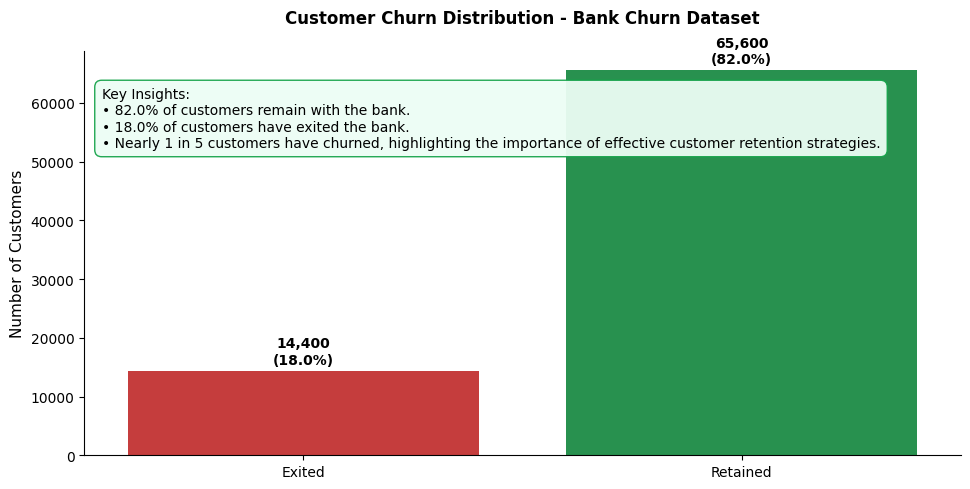

In [12]:
df_churn = df.copy()
mapping = {False: "Retained", True: "Exited"}
df_churn[CFG.TARGET_FEATURE] = df_churn[CFG.TARGET_FEATURE].map(mapping)
order = ["Exited", "Retained"]
exit_distribution = (df_churn[CFG.TARGET_FEATURE].value_counts().reindex(order))

# Plot Style
colors = ["#DC2626", "#16A34A"]
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
# ax.set_facecolor("#FAFAFA")

# Count Plot
sns.countplot(data=df_churn, x=CFG.TARGET_FEATURE, order=order, palette=colors, ax=ax)
ax.set_title(f"Customer Churn Distribution - {CFG.DATASET_NAME}", fontsize=12, fontweight="bold", pad=20)
ax.set_xlabel("")
ax.set_ylabel("Number of Customers", fontsize=11)
sns.despine()
# ax.grid(axis="y", linestyle="--", alpha=0.25)

# Add Count + Percentage
total = len(df_churn)
for container in ax.containers:
    labels = [f"{int(v.get_height()):,}\n({v.get_height()/total:.1%})" for v in container]
    ax.bar_label(container, labels=labels, fontsize=10, fontweight="bold", padding=3)

# Business Insight
exit_pct = exit_distribution["Exited"] / total * 100
retain_pct = exit_distribution["Retained"] / total * 100
insight = (
    "Key Insights:\n"
    f"• {retain_pct:.1f}% of customers remain with the bank.\n"
    f"• {exit_pct:.1f}% of customers have exited the bank.\n"
    "• Nearly 1 in 5 customers have churned, highlighting the importance of effective customer retention strategies."
)

ax.text(0.02, 0.91, insight, transform=ax.transAxes, fontsize=10, va="top",
        bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#ECFDF5",
        edgecolor="#16A34A",
        alpha=0.95
    )
)

plt.tight_layout()
plt.show()

## Numerical Feature Distributions


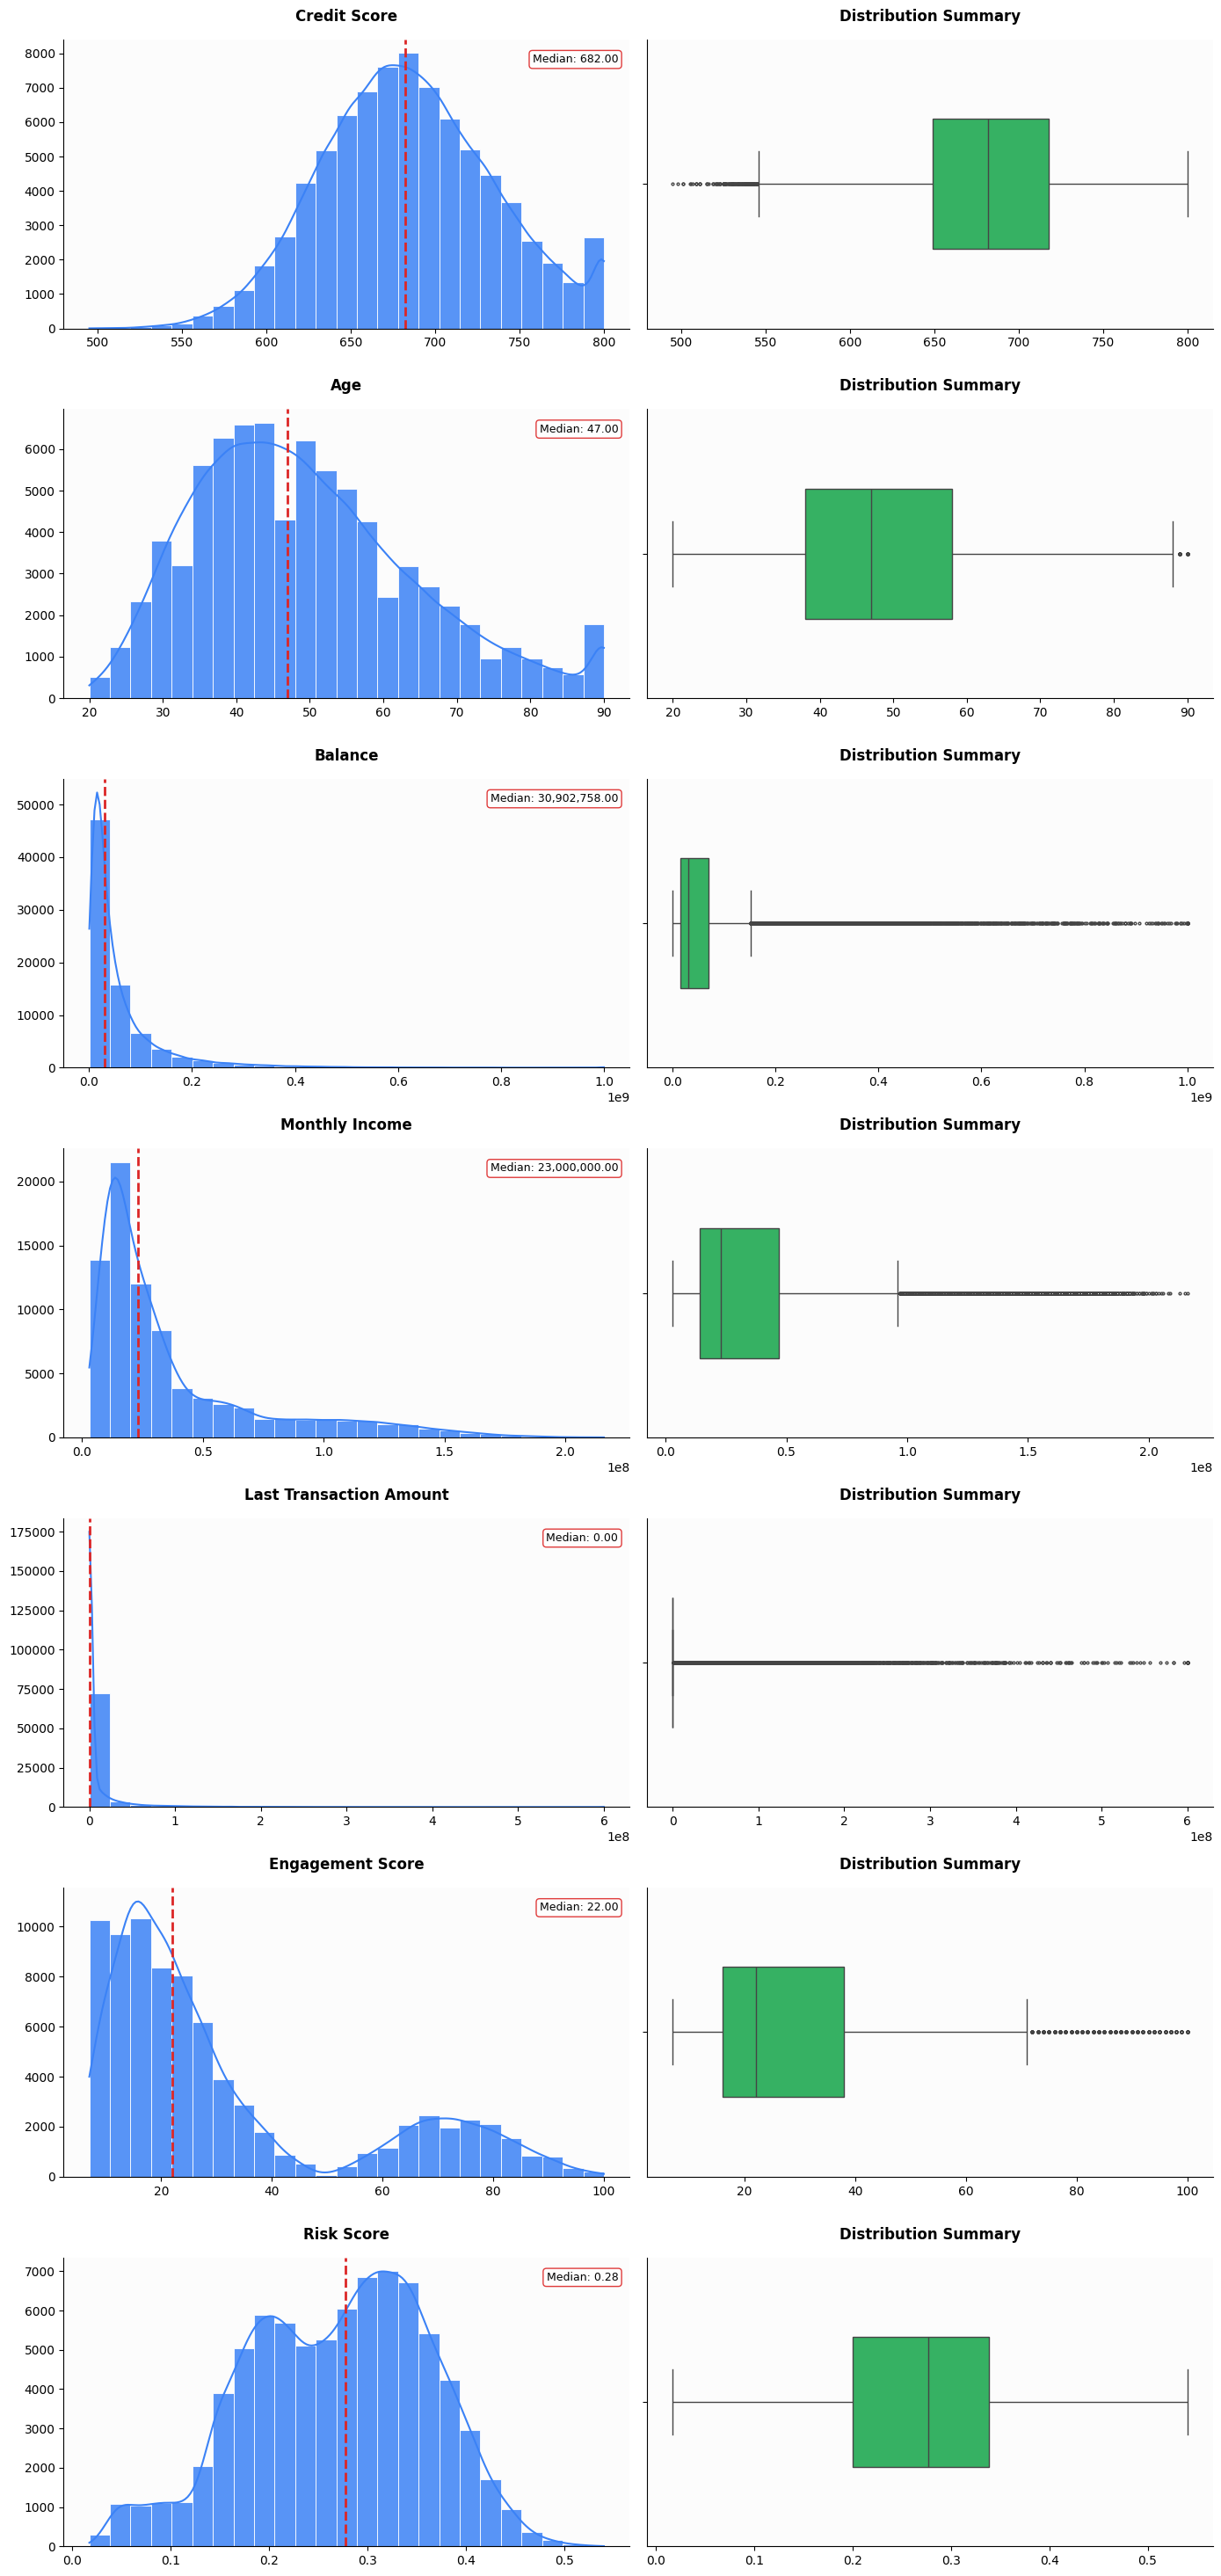

In [13]:
plot_numerical_features_v2(df=df_churn, numerical_features=num_features)

In [14]:
logger.info("-" * 80)
skew_feature = DataValidator.check_skewness(data=df_churn, dataset_name= CFG.DATASET_NAME, 
                                            numerical_features=num_features, logger=logger)
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-07-24 18:58:28 | INFO     | --------------------------------------------------------------------------------
2026-07-24 18:58:28 | INFO     | Skewness analysis for Bank Churn Dataset
2026-07-24 18:58:28 | INFO     | Total numerical features checked: 7
2026-07-24 18:58:28 | DEBUG    | ----------------------------------------------------------------------
2026-07-24 18:58:28 | DEBUG    | Feature                        | Skewness  | Remark
2026-07-24 18:58:28 | DEBUG    | ----------------------------------------------------------------------
2026-07-24 18:58:28 | DEBUG    | last_transaction_amount        |   +8.2167 | Highly skewed
2026-07-24 18:58:28 | DEBUG    | balance                        |   +4.1196 | Highly skewed
2026-07-24 18:58:28 | DEBUG    | monthly_income                 |   +1.7322 | Highly skewed
2026-07-24 18:58:28 | DEBUG    | engagement_score               |   +1.1839 | Highly skewed
2026-07-24 18:58:28 | DEBUG    | age                            |   +0.6389 | Mode

<div style="
    background: linear-gradient(135deg, #064e3b, #065f46, #047857);
    color: #f8fafc;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 8px 20px rgba(20,83,45,0.35);
">

<div style="
    color:#fde68a;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Distribution & Skewness Insights
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><b>5 out of 7 numerical features</b> exhibit noticeable positive skewness (<code>|skew| &gt; 0.5</code>), indicating that most customers fall within lower value ranges while a relatively small group holds exceptionally large values.</li>

<li><code>last_transaction_amount</code>, <code>balance</code>, and <code>monthly_income</code> are <b>highly right-skewed</b>, reflecting the presence of high-value customers with significantly larger balances, incomes, or transaction amounts than the average customer.</li>

<li><code>credit_score</code> and <code>risk_score</code> are <b>approximately symmetric</b>, suggesting a stable distribution of customer credit quality and risk levels across the portfolio.</li>

<li>The observed skewness is consistent with real-world banking data and mainly reflects customer diversity rather than data quality issues. For machine learning models sensitive to feature distributions, transformations such as <b>log</b>, <b>Box-Cox</b>, or <b>Yeo-Johnson</b> may improve performance.</li>

</ul>

</div>


## Correlation Analysis of Numerical Features


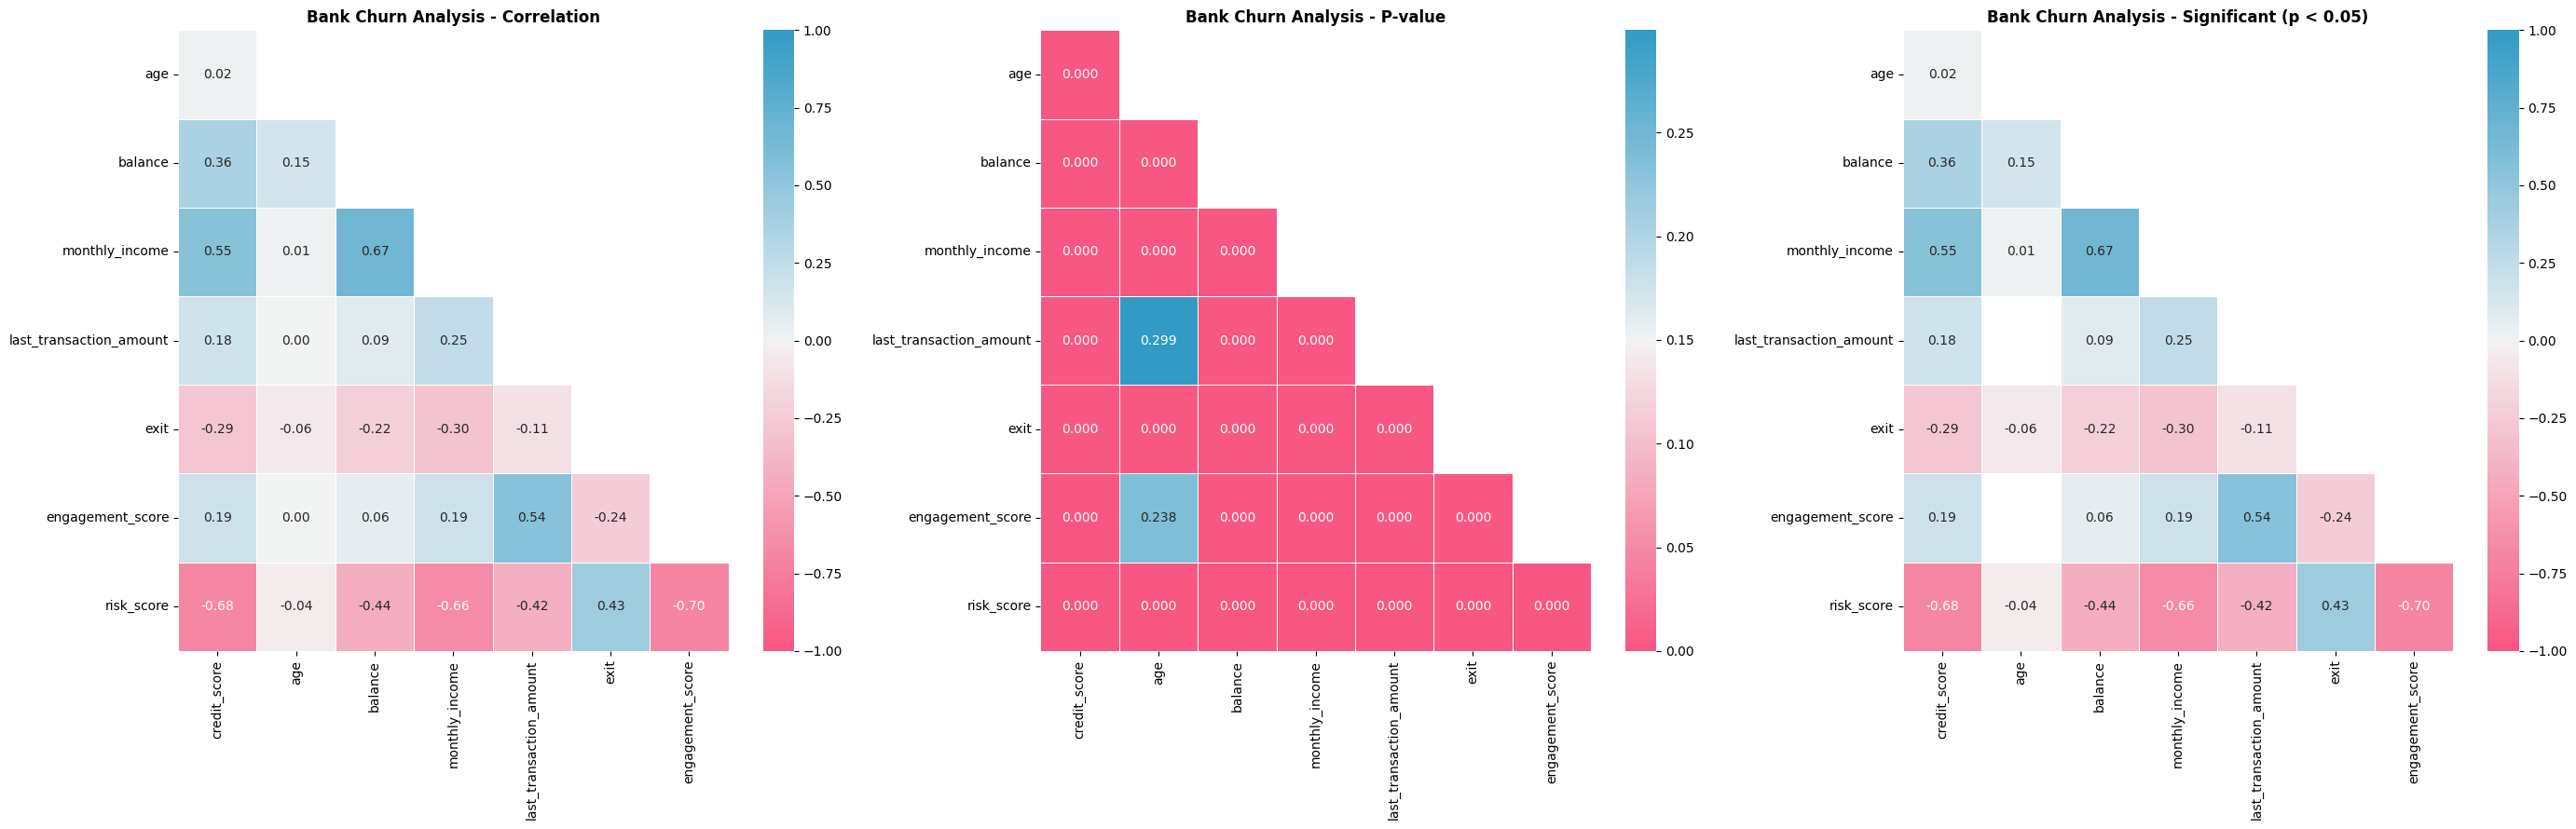

In [15]:
mapping = {"Retained": 0, "Exited": 1}
df_churn[CFG.TARGET_FEATURE] = df_churn[CFG.TARGET_FEATURE].map(mapping)

StatUtils.plot_correlation_with_pvalue_single(df_origin= df_churn, origin_name="Bank Churn Analysis")

<div style="
    background: linear-gradient(135deg, #064e3b, #065f46, #047857);
    color: #f8fafc;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 8px 20px rgba(20,83,45,0.35);
">

<div style="
    color:#fde68a;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Correlation Analysis Insights
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li>Most feature pairs exhibit <b>weak to moderate correlations</b>, indicating limited multicollinearity and suggesting that each variable contributes distinct information for customer analysis.</li>

<li><code>balance</code> and <code>monthly_income</code> show the strongest positive relationship (<b>r = 0.67</b>), indicating that customers with higher incomes generally maintain larger account balances.</li>

<li><code>risk_score</code> is strongly <b>negatively correlated</b> with <code>credit_score</code> (<b>r = -0.68</b>) and <code>monthly_income</code> (<b>r = -0.66</b>), suggesting that financially stronger customers tend to have lower estimated risk.</li>

<li><code>exit</code> has a <b>moderate negative correlation</b> with <code>monthly_income</code> (<b>r = -0.30</b>) and <code>credit_score</code> (<b>r = -0.29</b>), implying that customers with higher income and better credit profiles are generally less likely to leave the bank.</li>

<li>Nearly all correlations are <b>statistically significant</b> (<code>p &lt; 0.05</code>), while the relationship between <code>age</code> and <code>last_transaction_amount</code> is not statistically significant, indicating little evidence of a meaningful linear association.</li>

</ul>

</div>


## Categorical Feature Distributions


In [16]:
# ----- Run for all categorical features -----
for feature in cat_features:
    categorical_distribution(df=df, feature=feature, logger=logger)

2026-07-24 18:58:29 | INFO     | --------------------------------------------------------------------------------
2026-07-24 18:58:29 | INFO     | Analyzing categorical feature: gender
2026-07-24 18:58:29 | INFO     | Number of categories: 2
2026-07-24 18:58:29 | INFO     | 
Categorical Distribution - gender
Category  Count  Percentage (%)
    male  40008           50.01
  female  39992           49.99
2026-07-24 18:58:29 | INFO     | Completed analysis for: gender
2026-07-24 18:58:29 | INFO     | --------------------------------------------------------------------------------
2026-07-24 18:58:29 | INFO     | --------------------------------------------------------------------------------
2026-07-24 18:58:29 | INFO     | Analyzing categorical feature: occupation
2026-07-24 18:58:29 | INFO     | Number of categories: 10
2026-07-24 18:58:29 | INFO     | 
Categorical Distribution - occupation
                     Category  Count  Percentage (%)
         Kỹ sư/Chuyên viên IT   8199        

<div style="
    background: linear-gradient(135deg, #14532d, #166534, #15803d);
    color: #f0fdf4;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#dcfce7;
    margin: 0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Categorical Features Insights
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><code>gender</code> is almost perfectly balanced (<b>50% male</b> vs <b>50% female</b>), minimizing gender-related sampling bias.</li>

<li><code>occupation</code> is well distributed across <b>10 occupations</b>, providing a diverse representation of customer professions.</li>

<li><code>origin_province</code> is concentrated in <b>Ho Chi Minh City (~50%)</b>, indicating that the customer base is primarily urban.</li>

<li><code>married</code> is dominated by category <b>1 (~67%)</b>, suggesting one marital status represents the majority of customers.</li>

<li>Only <b>21.5%</b> of customers are <code>active_member</code>, indicating a relatively low level of active engagement.</li>

<li><code>customer_segment</code> is led by the <b>Emerging</b> segment (~40%), showing that the bank mainly serves growing retail customers.</li>

<li>Most customers belong to the <b>Bronze</b> loyalty tier (~86.6%), leaving significant opportunities for loyalty upgrades.</li>

<li><code>digital_behavior</code> is heavily skewed toward <b>offline</b> transactions (~78.5%), suggesting room to increase digital banking adoption.</li>

<li>The portfolio is predominantly <b>Low Risk</b> (~93.4%), indicating a generally healthy customer base.</li>

<li>Customers most commonly own <b>2 bank cards</b> and use <b>2–4 banking services</b>, reflecting moderate product adoption with potential for cross-selling.</li>

</ul>

</div>


## Multivariate Statistical Analysis


,exit,Count,Mean,Median,Std
0,Retained,65600,691.197271,689.000000,50.332884
1,Exited,14400,652.996528,653.000000,42.529961


2026-07-24 18:58:29 | INFO     | Checking normality of feature 'credit_score' by groups of 'exit'...
2026-07-24 18:58:29 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-24 18:58:29 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:29 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-24 18:58:29 | DEBUG    | [exit=Exited] skew=0.0061, kurtosis=0.0028 → Approximately symmetric, Normal tails
2026-07-24 18:58:29 | DEBUG    | [exit=Retained] skew=0.0782, kurtosis=-0.3088 → Approximately symmetric, Normal tails
2026-07-24 18:58:29 | INFO     | Generating Q–Q plots for visual assessment...


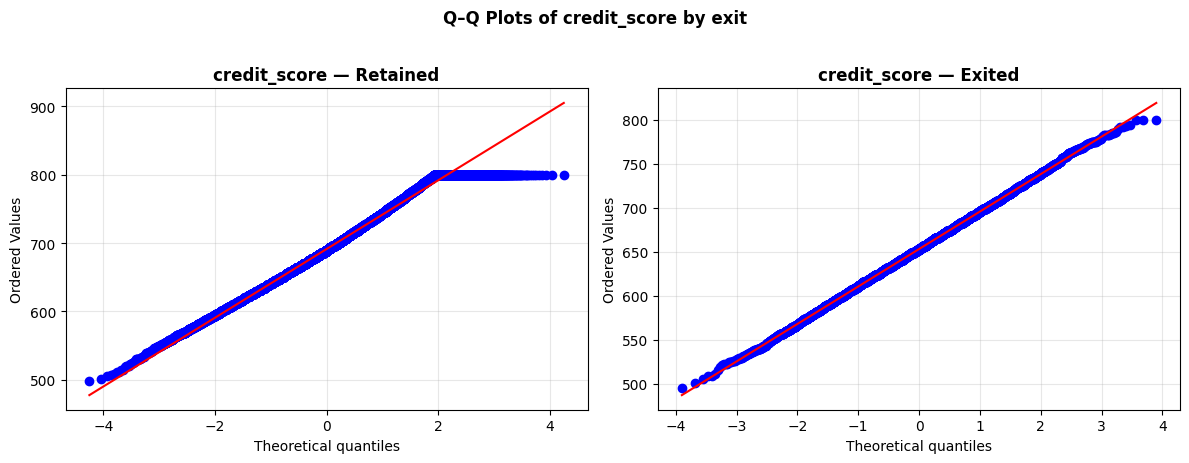

,Feature,Group,Skewness,Kurtosis,Remark
0,credit_score,Exited,0.0061,0.0028,"Approximately symmetric, Normal tails"
1,credit_score,Retained,0.0782,-0.3088,"Approximately symmetric, Normal tails"


2026-07-24 18:58:29 | INFO     | All groups approximately follow a normal distribution.
2026-07-24 18:58:29 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-07-24 18:58:29 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,601.9484
1,p-value,0.000000
2,Max/Min Variance Ratio,1.40


2026-07-24 18:58:30 | INFO     | Interpretation:
2026-07-24 18:58:30 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-07-24 18:58:30 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-07-24 18:58:30 | INFO     | Running Independent Two-Sample T-Test: 'credit_score' ~ 'exit'
2026-07-24 18:58:30 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:30 | DEBUG    | Test Type: Welch’s T-Test (unequal variances)
2026-07-24 18:58:30 | INFO     | Comparing groups: 'Retained' vs 'Exited'
2026-07-24 18:58:30 | INFO     | p-value: 0.000000
2026-07-24 18:58:30 | INFO     | Cohen's d: 0.820
2026-07-24 18:58:30 | DEBUG    | t-statistic: 94.264
2026-07-24 18:58:30 | DEBUG    | Group means → Retained: 691.197, Exited: 652.997
2026-07-24 18:58:30 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-07-24 18:58:30 | INFO     | Conclusion: Significant difference between the two grou

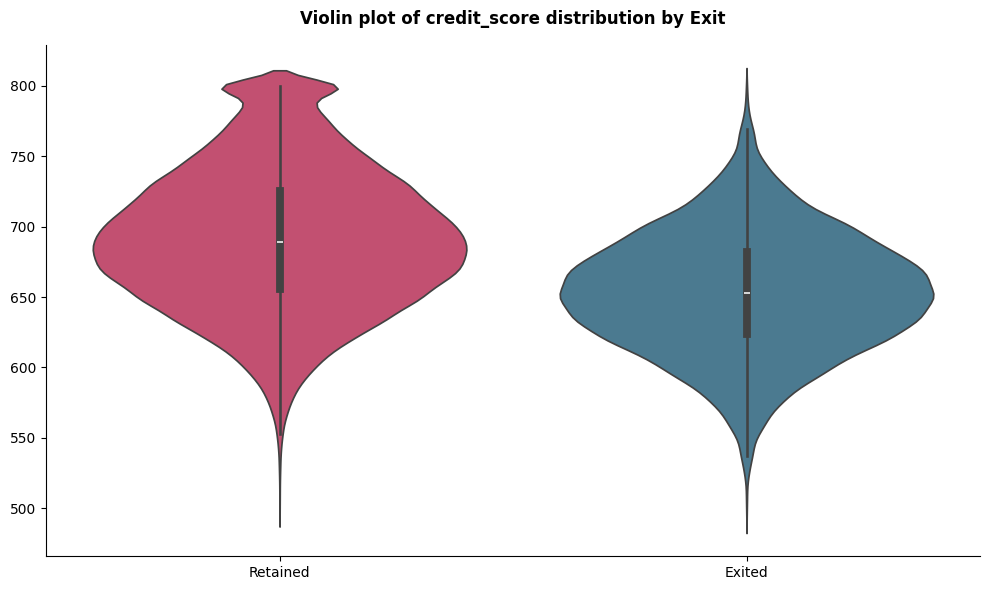

,exit,Count,Mean,Median,Std
0,Retained,65600,49.776616,48.000000,15.028871
1,Exited,14400,47.583542,45.000000,15.112724


2026-07-24 18:58:30 | INFO     | Checking normality of feature 'age' by groups of 'exit'...
2026-07-24 18:58:30 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-24 18:58:30 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:30 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-24 18:58:30 | DEBUG    | [exit=Exited] skew=0.7215, kurtosis=0.1388 → Moderately skewed, Normal tails
2026-07-24 18:58:30 | DEBUG    | [exit=Retained] skew=0.6254, kurtosis=-0.0192 → Moderately skewed, Normal tails
2026-07-24 18:58:30 | INFO     | Generating Q–Q plots for visual assessment...


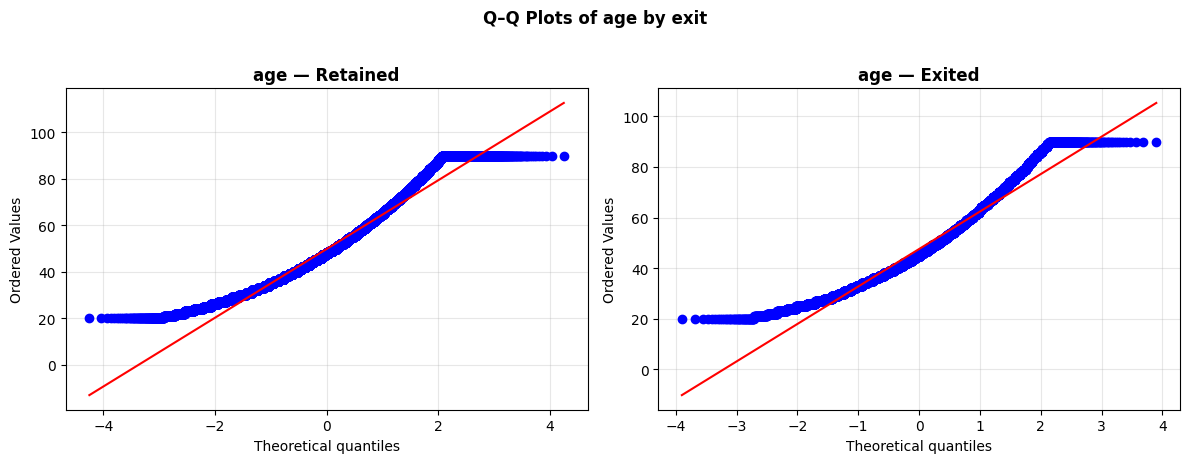

,Feature,Group,Skewness,Kurtosis,Remark
0,age,Exited,0.7215,0.1388,"Moderately skewed, Normal tails"
1,age,Retained,0.6254,-0.0192,"Moderately skewed, Normal tails"


2026-07-24 18:58:31 | WARNING  | Normality assumption violated in at least one group.
2026-07-24 18:58:31 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-07-24 18:58:31 | INFO     | Running Mann–Whitney U Test: 'age' by 'exit'...
2026-07-24 18:58:31 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:31 | INFO     | U statistic: 515304952.0
2026-07-24 18:58:31 | INFO     | p-value    : 0.000000
2026-07-24 18:58:31 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-07-24 18:58:31 | INFO     | Conclusion: Significant difference between the two groups.
2026-07-24 18:58:31 | INFO     | Effect size (r): 0.0606
2026-07-24 18:58:31 | INFO     | Effect size interpretation: Negligible
2026-07-24 18:58:31 | INFO     | Cliff's Delta: -0.0910
2026-07-24 18:58:31 | INFO     | Effect size (Cliff's Delta) interpretation: Negligible


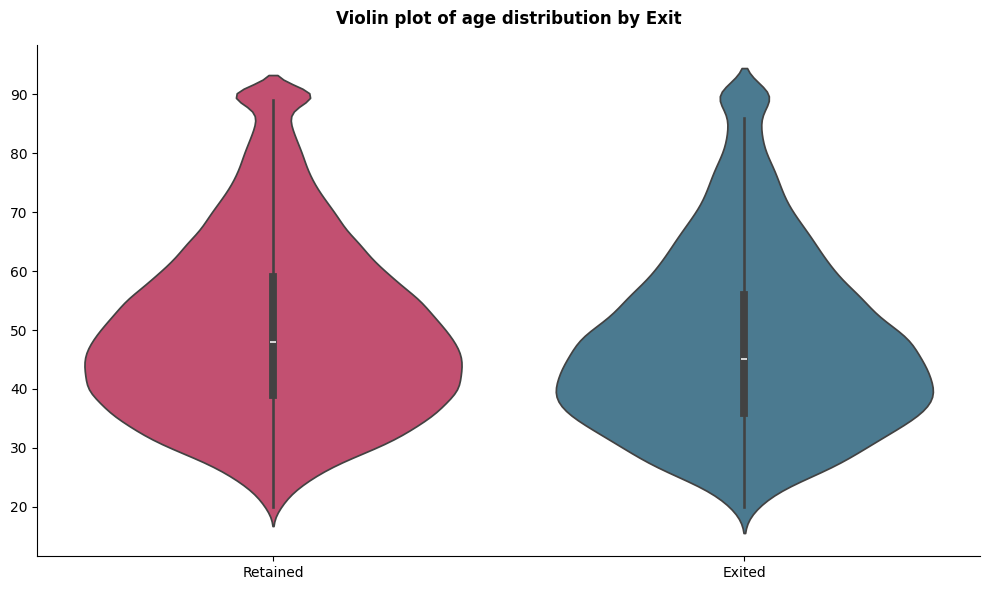

,exit,Count,Mean,Median,Std
0,Retained,65600,70309137.879405,38083040.000000,95082168.479826
1,Exited,14400,19609457.421875,13706650.500000,20076879.294348


2026-07-24 18:58:31 | INFO     | Checking normality of feature 'balance' by groups of 'exit'...
2026-07-24 18:58:31 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-24 18:58:31 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:31 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-24 18:58:32 | DEBUG    | [exit=Exited] skew=4.1706, kurtosis=41.7660 → Highly skewed, Heavy/light tails
2026-07-24 18:58:32 | DEBUG    | [exit=Retained] skew=3.8104, kurtosis=21.6466 → Highly skewed, Heavy/light tails
2026-07-24 18:58:32 | INFO     | Generating Q–Q plots for visual assessment...


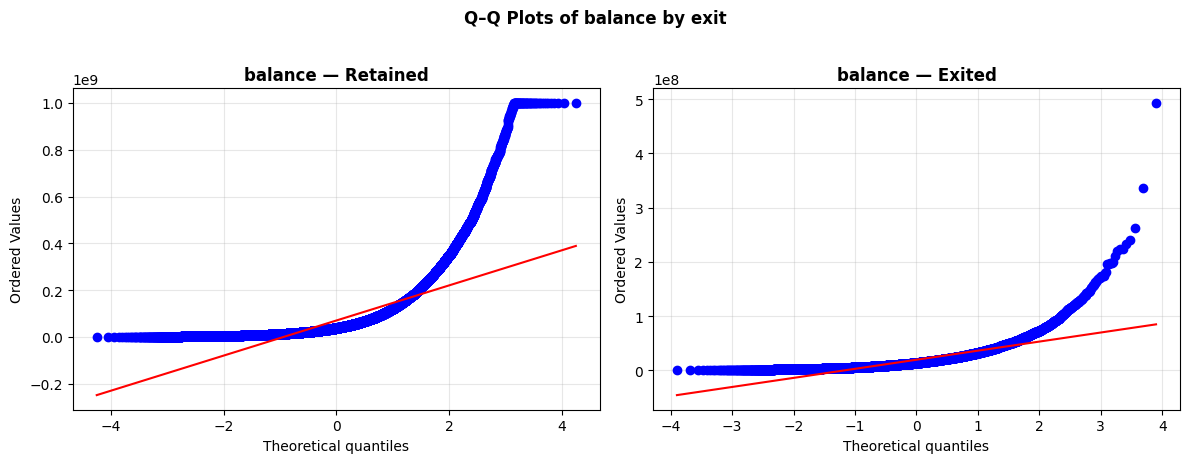

,Feature,Group,Skewness,Kurtosis,Remark
0,balance,Exited,4.1706,41.7660,"Highly skewed, Heavy/light tails"
1,balance,Retained,3.8104,21.6466,"Highly skewed, Heavy/light tails"


2026-07-24 18:58:32 | WARNING  | Normality assumption violated in at least one group.
2026-07-24 18:58:32 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-07-24 18:58:32 | INFO     | Running Mann–Whitney U Test: 'balance' by 'exit'...
2026-07-24 18:58:32 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:32 | INFO     | U statistic: 727873688.5
2026-07-24 18:58:32 | INFO     | p-value    : 0.000000
2026-07-24 18:58:32 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-07-24 18:58:32 | INFO     | Conclusion: Significant difference between the two groups.
2026-07-24 18:58:32 | INFO     | Effect size (r): 0.3600
2026-07-24 18:58:32 | INFO     | Effect size interpretation: Medium
2026-07-24 18:58:32 | INFO     | Cliff's Delta: -0.5411
2026-07-24 18:58:32 | INFO     | Effect size (Cliff's Delta) interpretation: Large


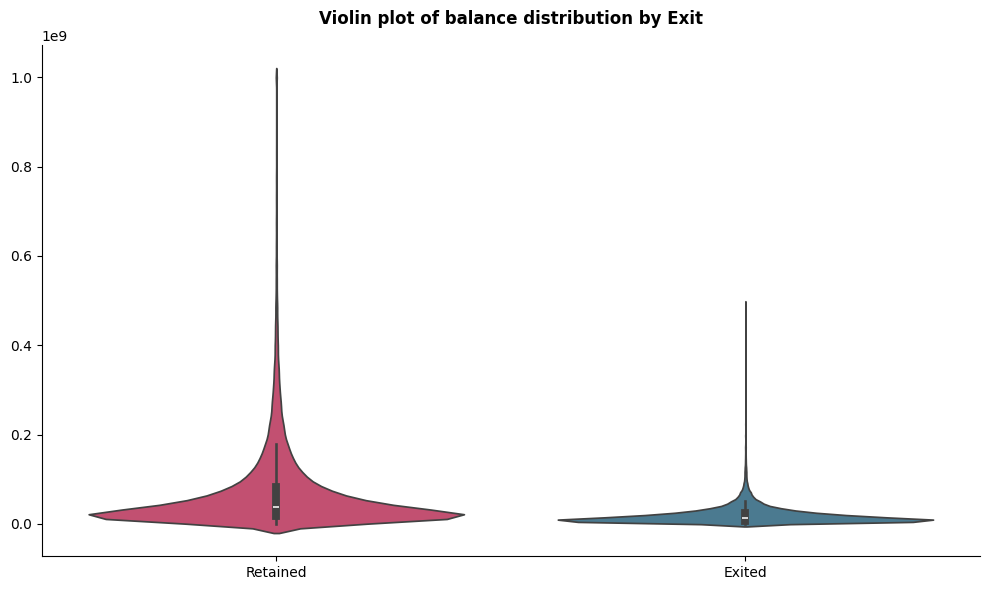

,exit,Count,Mean,Median,Std
0,Retained,65600,42909527.439024,28000000.000000,38342661.993346
1,Exited,14400,14457708.333333,13000000.000000,7806270.548567


2026-07-24 18:58:33 | INFO     | Checking normality of feature 'monthly_income' by groups of 'exit'...
2026-07-24 18:58:33 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-24 18:58:33 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:33 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-24 18:58:33 | DEBUG    | [exit=Exited] skew=1.3883, kurtosis=3.0846 → Highly skewed, Heavy/light tails
2026-07-24 18:58:33 | DEBUG    | [exit=Retained] skew=1.4904, kurtosis=1.4763 → Highly skewed, Normal tails
2026-07-24 18:58:33 | INFO     | Generating Q–Q plots for visual assessment...


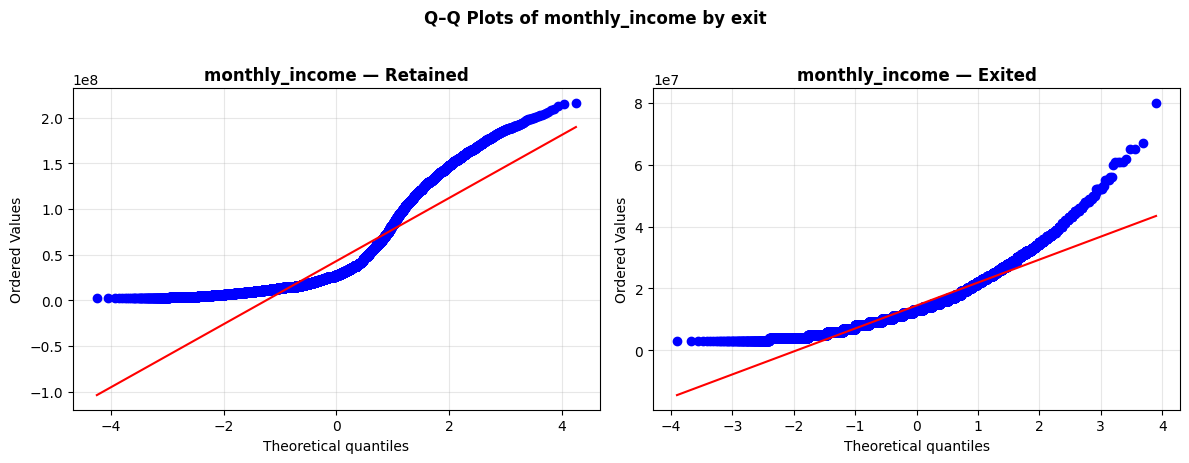

,Feature,Group,Skewness,Kurtosis,Remark
0,monthly_income,Exited,1.3883,3.0846,"Highly skewed, Heavy/light tails"
1,monthly_income,Retained,1.4904,1.4763,"Highly skewed, Normal tails"


2026-07-24 18:58:33 | WARNING  | Normality assumption violated in at least one group.
2026-07-24 18:58:33 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-07-24 18:58:33 | INFO     | Running Mann–Whitney U Test: 'monthly_income' by 'exit'...
2026-07-24 18:58:33 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:33 | INFO     | U statistic: 755068247.5
2026-07-24 18:58:33 | INFO     | p-value    : 0.000000
2026-07-24 18:58:33 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-07-24 18:58:33 | INFO     | Conclusion: Significant difference between the two groups.
2026-07-24 18:58:33 | INFO     | Effect size (r): 0.3983
2026-07-24 18:58:33 | INFO     | Effect size interpretation: Medium
2026-07-24 18:58:33 | INFO     | Cliff's Delta: -0.5986
2026-07-24 18:58:33 | INFO     | Effect size (Cliff's Delta) interpretation: Large


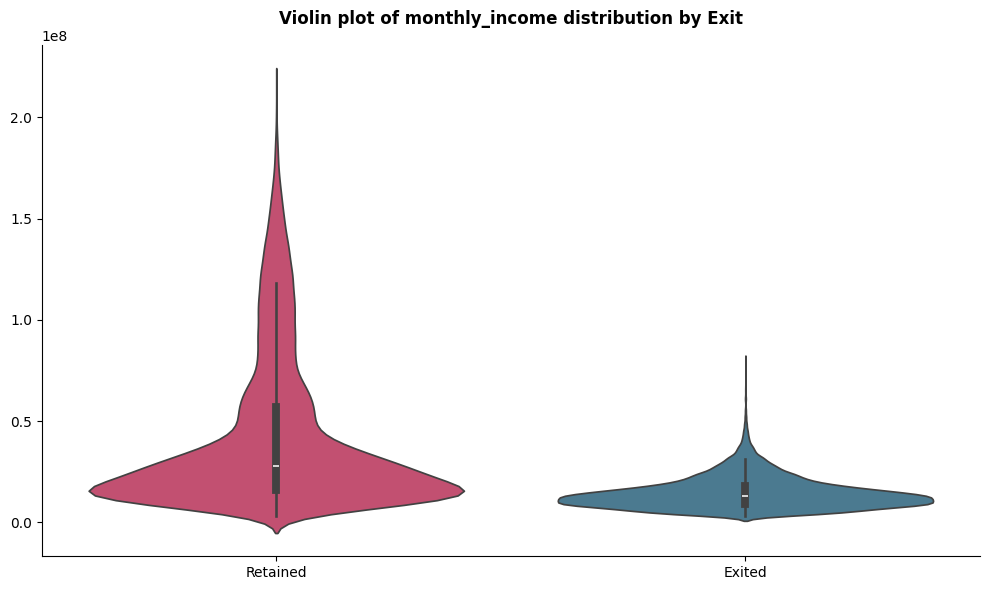

,exit,Count,Mean,Median,Std
0,Retained,65600,10538833.957287,0.000000,37003343.864259
1,Exited,14400,1055062.495139,0.000000,5524919.618051


2026-07-24 18:58:34 | INFO     | Checking normality of feature 'last_transaction_amount' by groups of 'exit'...
2026-07-24 18:58:34 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-24 18:58:34 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:34 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-24 18:58:34 | DEBUG    | [exit=Exited] skew=9.2763, kurtosis=121.9259 → Highly skewed, Heavy/light tails
2026-07-24 18:58:34 | DEBUG    | [exit=Retained] skew=7.4876, kurtosis=80.0760 → Highly skewed, Heavy/light tails
2026-07-24 18:58:34 | INFO     | Generating Q–Q plots for visual assessment...


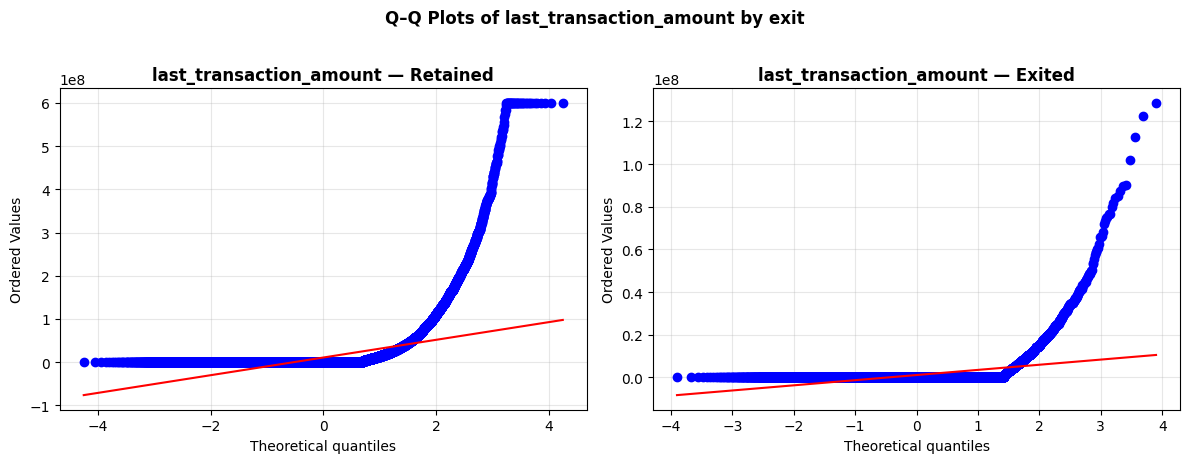

,Feature,Group,Skewness,Kurtosis,Remark
0,last_transaction_amount,Exited,9.2763,121.9259,"Highly skewed, Heavy/light tails"
1,last_transaction_amount,Retained,7.4876,80.0760,"Highly skewed, Heavy/light tails"


2026-07-24 18:58:34 | WARNING  | Normality assumption violated in at least one group.
2026-07-24 18:58:34 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-07-24 18:58:34 | INFO     | Running Mann–Whitney U Test: 'last_transaction_amount' by 'exit'...
2026-07-24 18:58:34 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:34 | INFO     | U statistic: 555298189.5
2026-07-24 18:58:34 | INFO     | p-value    : 0.000000
2026-07-24 18:58:35 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-07-24 18:58:35 | INFO     | Conclusion: Significant difference between the two groups.
2026-07-24 18:58:35 | INFO     | Effect size (r): 0.1169
2026-07-24 18:58:35 | INFO     | Effect size interpretation: Small
2026-07-24 18:58:35 | INFO     | Cliff's Delta: -0.1757
2026-07-24 18:58:35 | INFO     | Effect size (Cliff's Delta) interpretation: Small


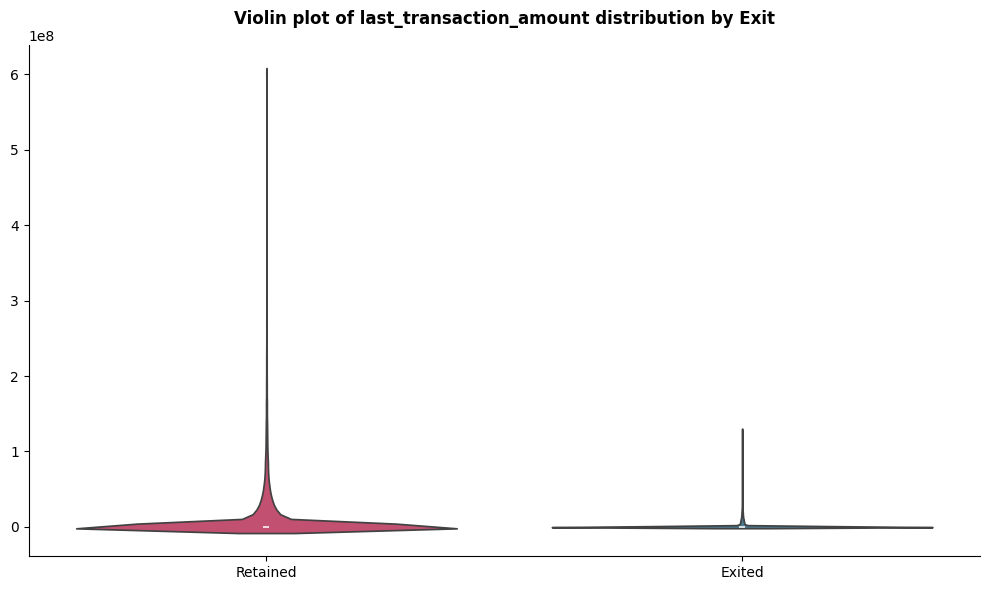

,exit,Count,Mean,Median,Std
0,Retained,65600,34.313323,25.000000,24.181895
1,Exited,14400,19.935972,16.000000,15.102568


2026-07-24 18:58:35 | INFO     | Checking normality of feature 'engagement_score' by groups of 'exit'...
2026-07-24 18:58:35 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-24 18:58:35 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:35 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-24 18:58:35 | DEBUG    | [exit=Exited] skew=2.5143, kurtosis=6.0031 → Highly skewed, Heavy/light tails
2026-07-24 18:58:35 | DEBUG    | [exit=Retained] skew=1.0147, kurtosis=-0.3527 → Highly skewed, Normal tails
2026-07-24 18:58:35 | INFO     | Generating Q–Q plots for visual assessment...


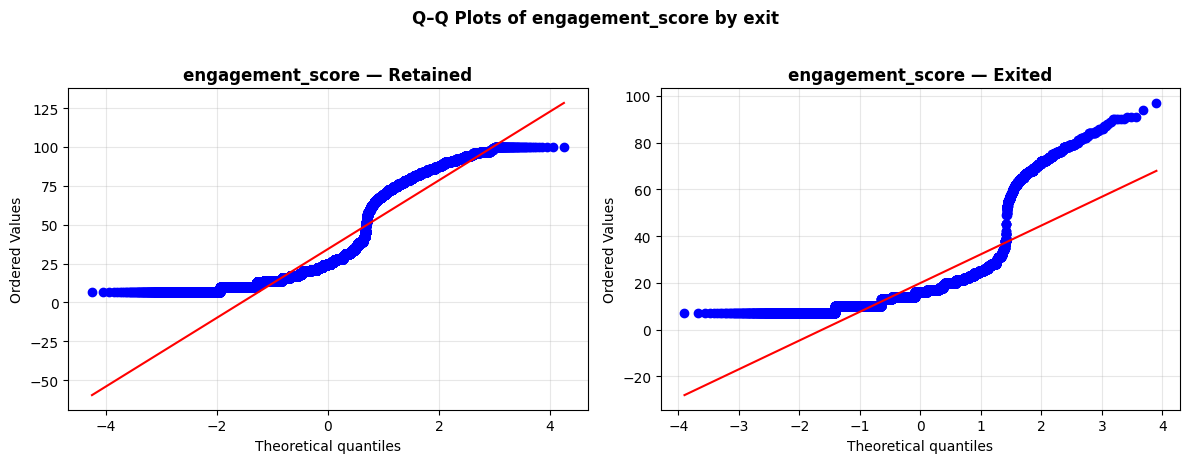

,Feature,Group,Skewness,Kurtosis,Remark
0,engagement_score,Exited,2.5143,6.0031,"Highly skewed, Heavy/light tails"
1,engagement_score,Retained,1.0147,-0.3527,"Highly skewed, Normal tails"


2026-07-24 18:58:35 | WARNING  | Normality assumption violated in at least one group.
2026-07-24 18:58:35 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-07-24 18:58:35 | INFO     | Running Mann–Whitney U Test: 'engagement_score' by 'exit'...
2026-07-24 18:58:35 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:35 | INFO     | U statistic: 679864241.5
2026-07-24 18:58:35 | INFO     | p-value    : 0.000000
2026-07-24 18:58:36 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-07-24 18:58:36 | INFO     | Conclusion: Significant difference between the two groups.
2026-07-24 18:58:36 | INFO     | Effect size (r): 0.2924
2026-07-24 18:58:36 | INFO     | Effect size interpretation: Small
2026-07-24 18:58:36 | INFO     | Cliff's Delta: -0.4394
2026-07-24 18:58:36 | INFO     | Effect size (Cliff's Delta) interpretation: Medium


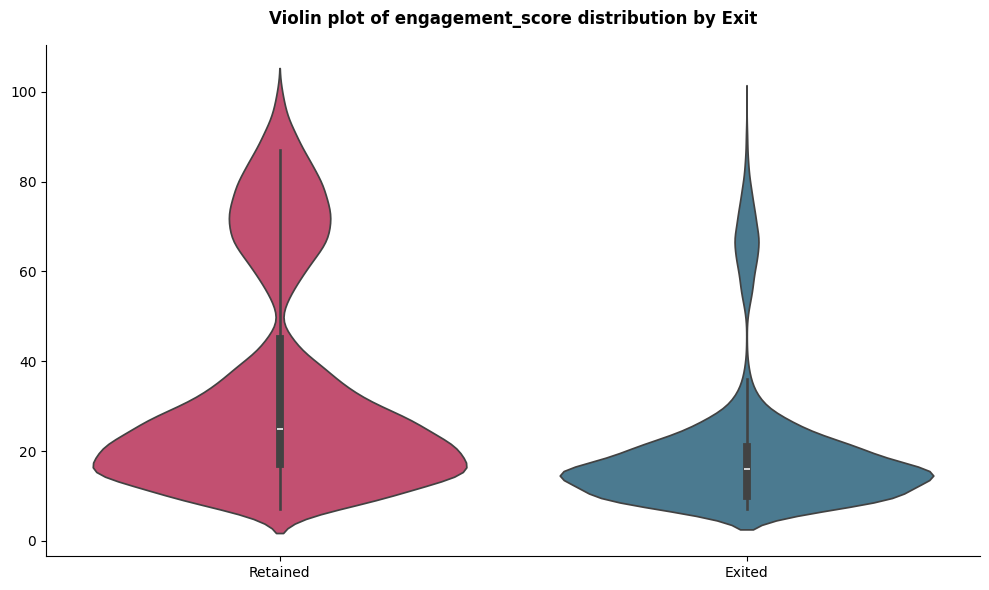

,exit,Count,Mean,Median,Std
0,Exited,14400,0.354277,0.356000,0.057684
1,Retained,65600,0.250598,0.252500,0.087363


2026-07-24 18:58:36 | INFO     | Checking normality of feature 'risk_score' by groups of 'exit'...
2026-07-24 18:58:36 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-07-24 18:58:36 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:36 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-07-24 18:58:36 | DEBUG    | [exit=Exited] skew=-0.3019, kurtosis=0.3208 → Approximately symmetric, Normal tails
2026-07-24 18:58:36 | DEBUG    | [exit=Retained] skew=-0.1498, kurtosis=-0.4466 → Approximately symmetric, Normal tails
2026-07-24 18:58:36 | INFO     | Generating Q–Q plots for visual assessment...


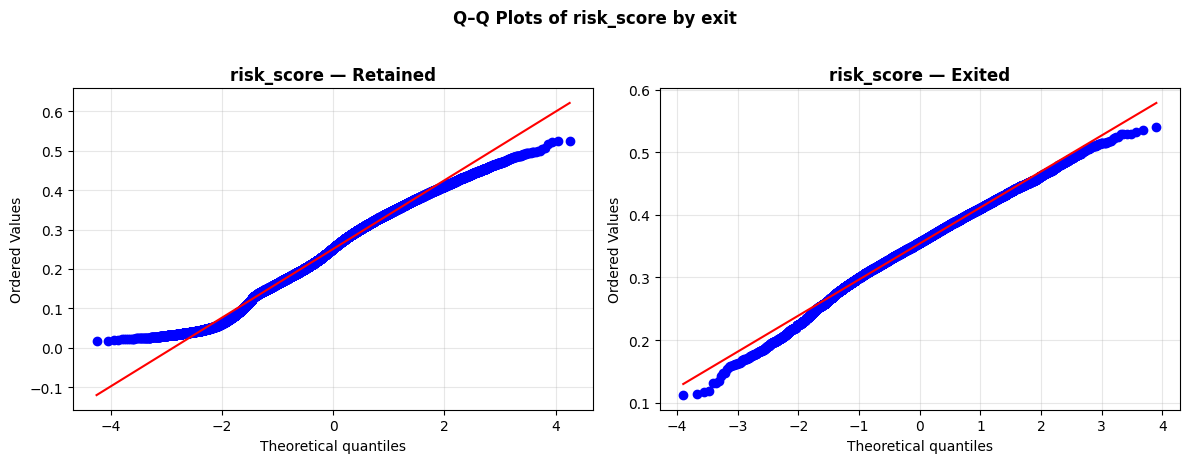

,Feature,Group,Skewness,Kurtosis,Remark
0,risk_score,Exited,-0.3019,0.3208,"Approximately symmetric, Normal tails"
1,risk_score,Retained,-0.1498,-0.4466,"Approximately symmetric, Normal tails"


2026-07-24 18:58:37 | INFO     | All groups approximately follow a normal distribution.
2026-07-24 18:58:37 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-07-24 18:58:37 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,3875.0635
1,p-value,0.000000
2,Max/Min Variance Ratio,2.29


2026-07-24 18:58:37 | INFO     | Interpretation:
2026-07-24 18:58:37 | INFO     | - Status: Strong variance heterogeneity detected.
2026-07-24 18:58:37 | INFO     | - Recommendation: Use Kruskal–Wallis or Mann–Whitney U test.
2026-07-24 18:58:37 | INFO     | Running Mann–Whitney U Test: 'risk_score' by 'exit'...
2026-07-24 18:58:37 | DEBUG    | Number of groups detected: 2
2026-07-24 18:58:37 | INFO     | U statistic: 155827200.0
2026-07-24 18:58:37 | INFO     | p-value    : 0.000000
2026-07-24 18:58:37 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-07-24 18:58:37 | INFO     | Conclusion: Significant difference between the two groups.
2026-07-24 18:58:37 | INFO     | Effect size (r): 0.4459
2026-07-24 18:58:37 | INFO     | Effect size interpretation: Medium
2026-07-24 18:58:37 | INFO     | Cliff's Delta: 0.6701
2026-07-24 18:58:37 | INFO     | Effect size (Cliff's Delta) interpretation: Large


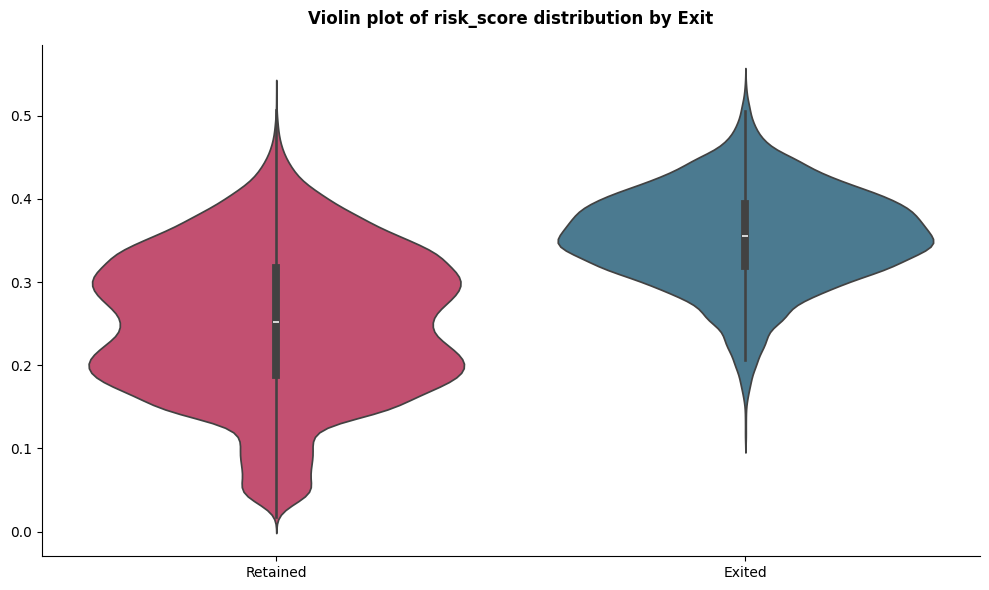

In [17]:
mapping = {0: "Retained", 1: "Exited"}
df_churn[CFG.TARGET_FEATURE] = df_churn[CFG.TARGET_FEATURE].map(mapping)

for feature in num_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:green;'><b>Distribution of {feature.title()} by Exit</b></h2>"))
    StatUtils.analyze_numeric_feature_by_target(feature=feature, df=df_churn, target_feature=CFG.TARGET_FEATURE, logger=logger)

<div style="
    background: linear-gradient(135deg, #0b3d2e, #145a45);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size: 22px;
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Numerical Features vs. Customer Churn
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>
<code>credit_score</code>: Retained customers exhibit <b>significantly higher credit scores</b> than exited customers. The difference is statistically significant (<b>p &lt; 0.001</b>) with a <b>large practical effect (Cohen's d = 0.82)</b>, indicating credit score is strongly associated with churn.
</li>

<li>
<code>age</code>: Exited customers are slightly younger than retained customers (<b>Mean: 47.6 vs. 49.8 years</b>). Despite being statistically significant (<b>p &lt; 0.001</b>), the effect size is <b>negligible</b>, indicating that age has limited practical impact on churn.
</li>

<li>
<code>balance</code>: Retained customers maintain substantially higher account balances than exited customers (<b>Median: ~38.1M vs. ~13.7M</b>). The difference is statistically significant (<b>p &lt; 0.001</b>) with a meaningful effect size, suggesting that higher account balances are <b>strongly associated with customer retention</b>.
</li>

<li>
<code>monthly_income</code>: Retained customers have substantially higher monthly income than exited customers (<b>Median: 28M vs. 13M</b>). The difference is statistically significant (<b>p &lt; 0.001</b>) with a meaningful effect size, indicating that higher income is <b>strongly associated with customer retention</b>.
</li>

<li>
<code>last_transaction_amount</code>: Retained customers show higher average transaction amounts than exited customers, but both groups have a <b>median of zero</b>. Although the difference is statistically significant (<b>p &lt; 0.001</b>), the <b>small effect size</b> suggests that <code>last_transaction_amount</code> alone has limited practical influence on churn.
</li>

<li>
<code>engagement_score</code>: Retained customers show substantially higher engagement than exited customers (<b>Median: 25 vs. 16</b>). The difference is statistically significant (<b>p &lt; 0.001</b>) with a meaningful effect size, suggesting that <b>stronger customer engagement is associated with better retention</b>.
</li>

<li>
<code>risk_score</code>: Exited customers have substantially higher risk scores than retained customers (<b>Median: 0.356 vs. 0.253</b>). The difference is statistically significant (<b>p &lt; 0.001</b>) with a meaningful effect size, indicating that <b>higher customer risk is strongly associated with churn</b>.
</li>

</ul>

</div>


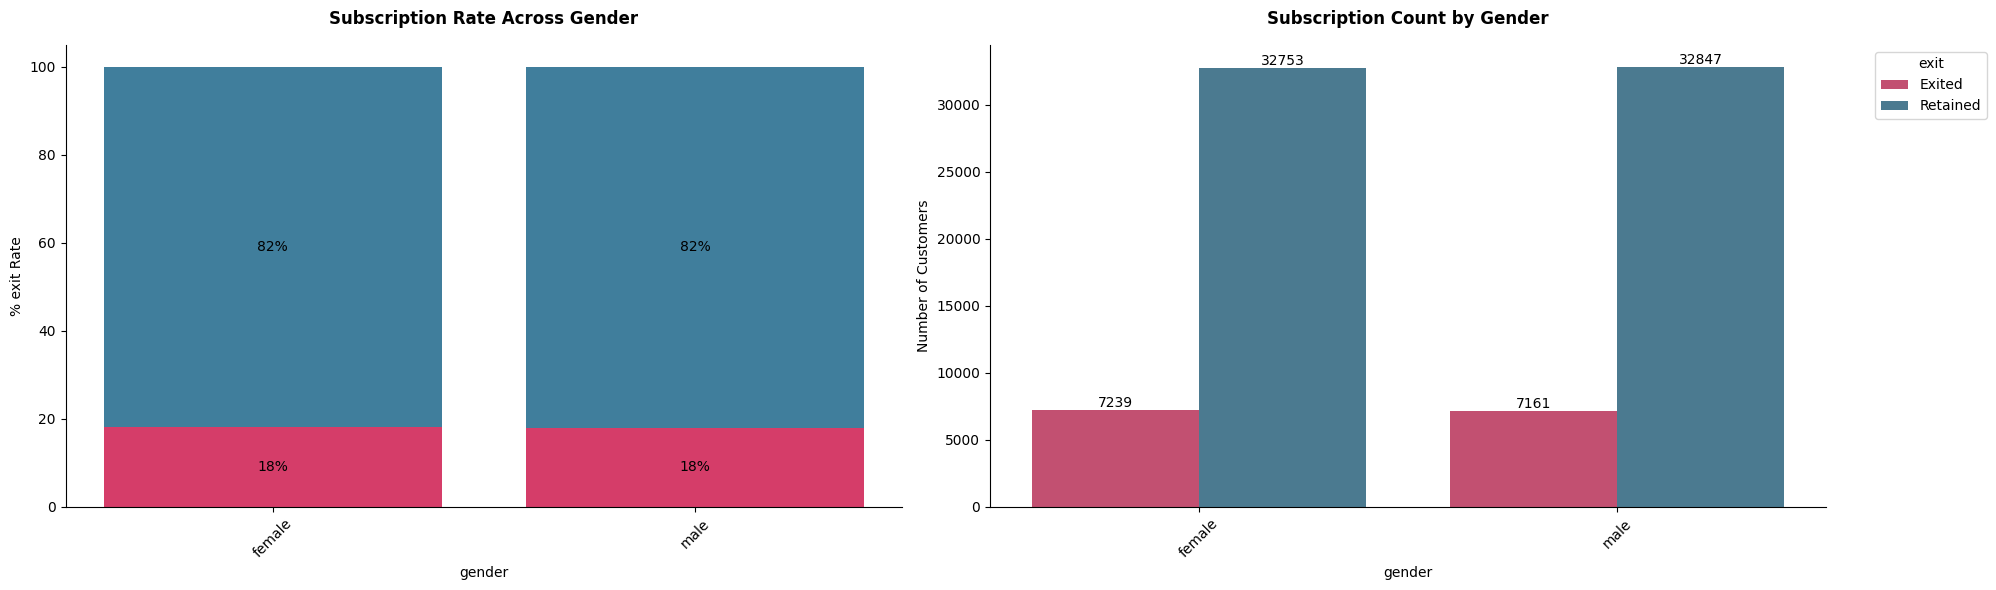

2026-07-24 18:58:38 | INFO     | Chi-Square Test of Independence: 'gender' vs. 'exit'...
2026-07-24 18:58:38 | INFO     | Chi-squared statistic: 0.540
2026-07-24 18:58:38 | INFO     | Degrees of freedom: 1
2026-07-24 18:58:38 | INFO     | p-value: 0.462275
2026-07-24 18:58:38 | WARNING  | Result: p-value ≥ 0.05 → Fail to reject H0
2026-07-24 18:58:38 | WARNING  | No statistically significant association detected between 'gender' and 'exit'.


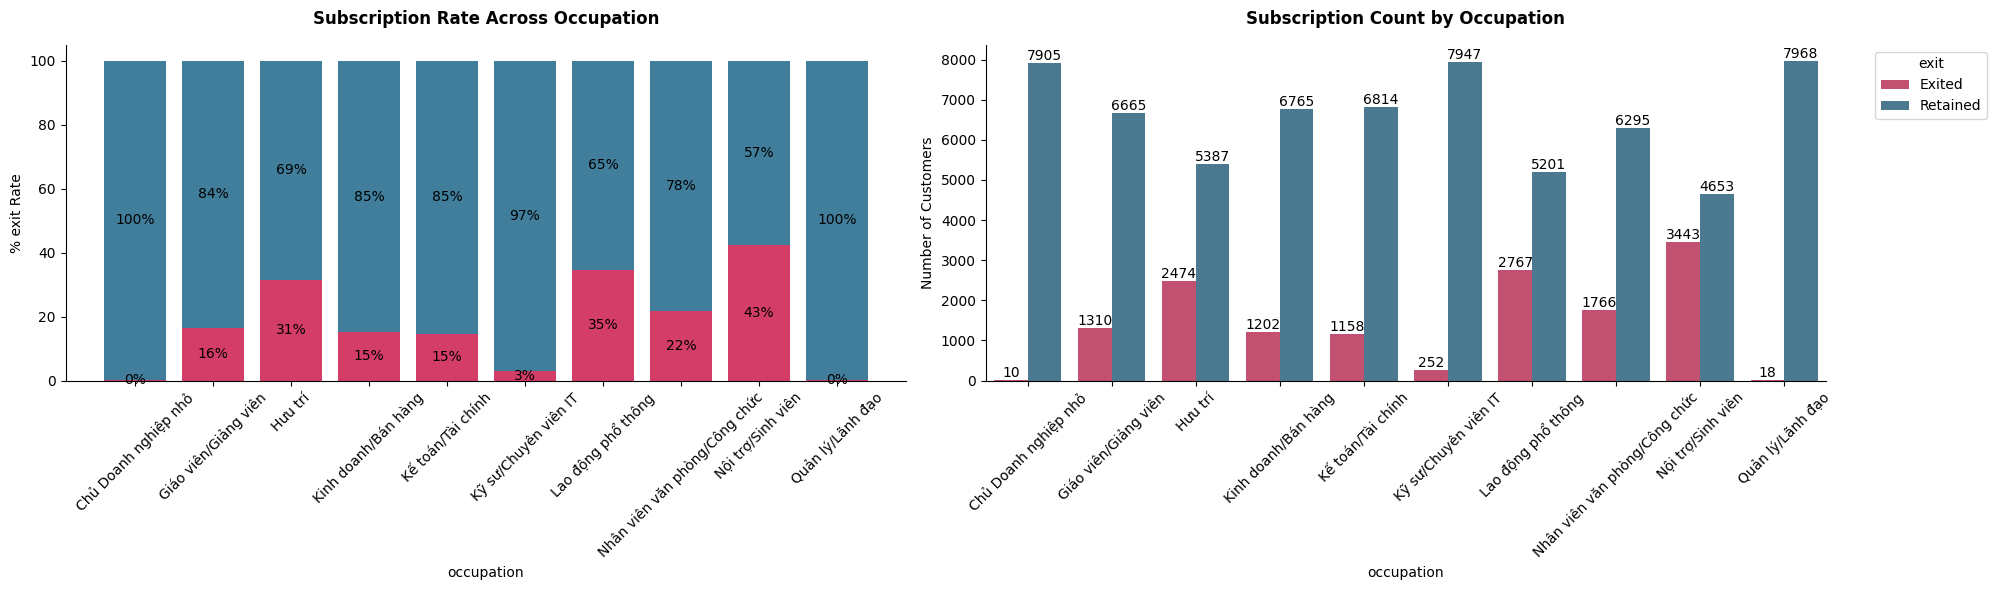

2026-07-24 18:58:38 | INFO     | Chi-Square Test of Independence: 'occupation' vs. 'exit'...
2026-07-24 18:58:38 | INFO     | Chi-squared statistic: 10644.572
2026-07-24 18:58:38 | INFO     | Degrees of freedom: 9
2026-07-24 18:58:38 | INFO     | p-value: 0.000000
2026-07-24 18:58:38 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-24 18:58:38 | INFO     | Variables 'occupation' and 'exit' are statistically associated.
2026-07-24 18:58:38 | DEBUG    | Displaying standardized residuals heatmap.


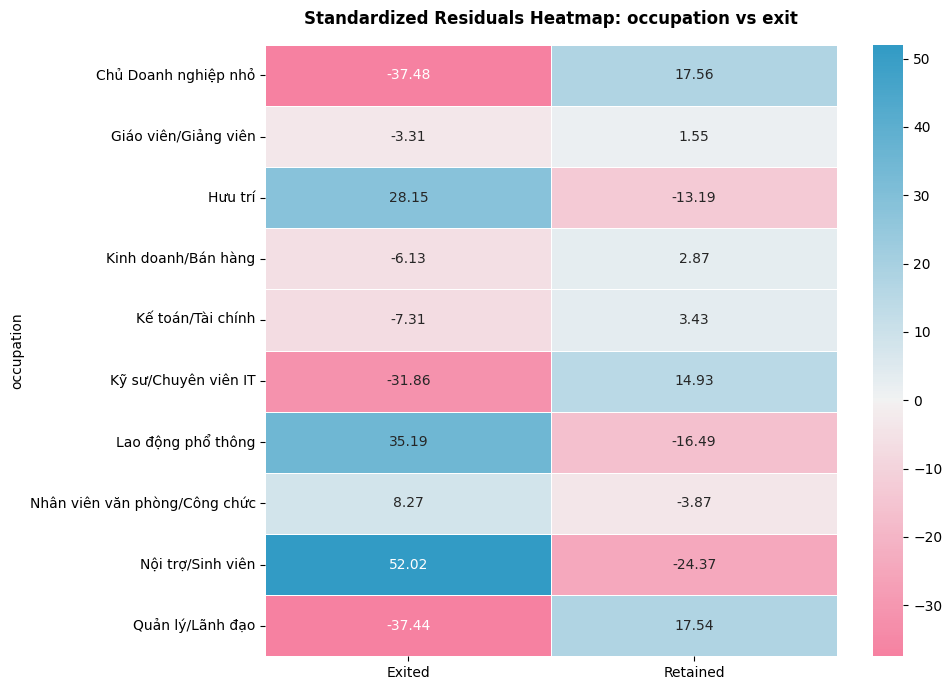

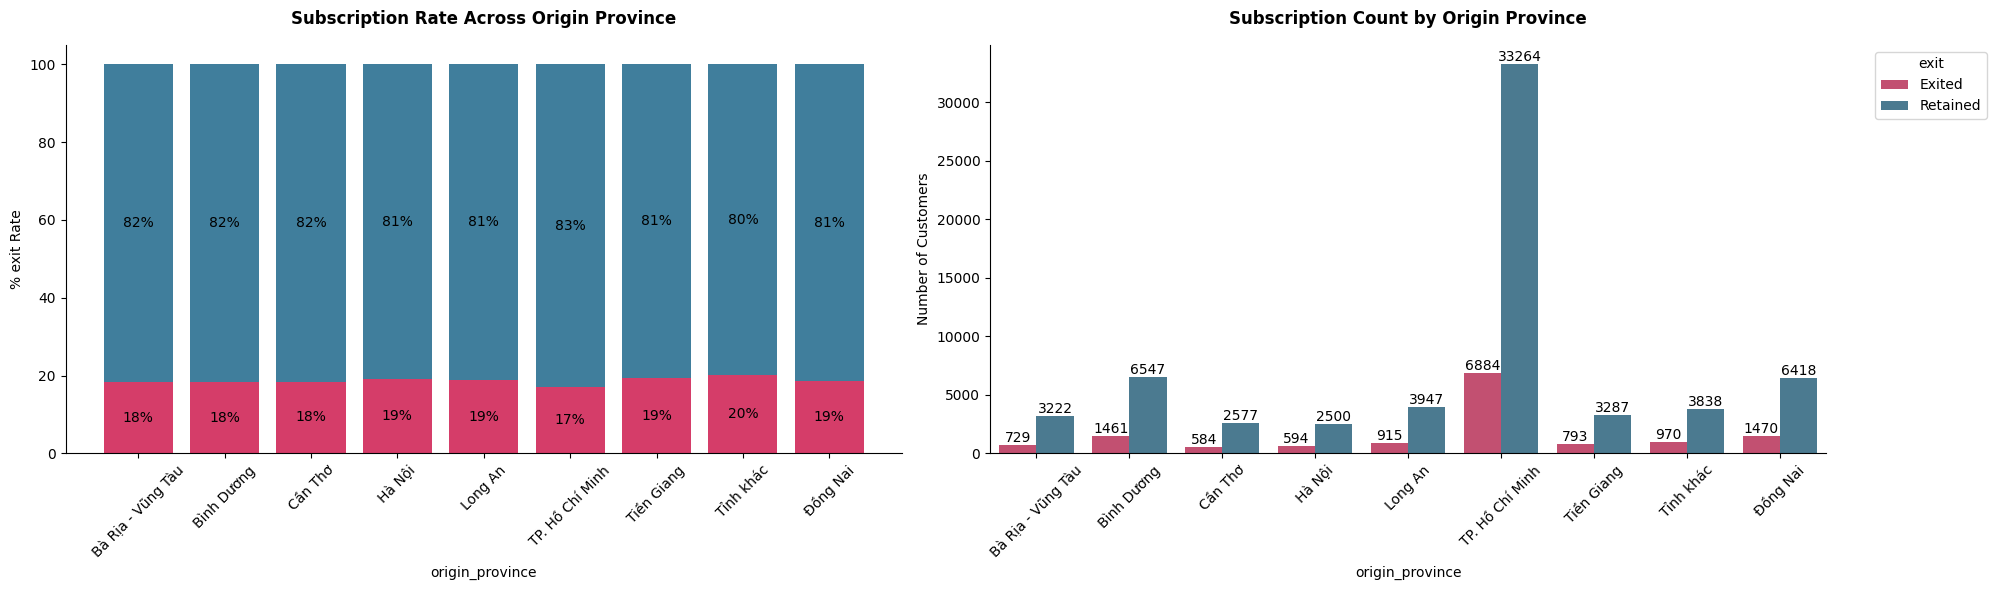

2026-07-24 18:58:39 | INFO     | Chi-Square Test of Independence: 'origin_province' vs. 'exit'...
2026-07-24 18:58:39 | INFO     | Chi-squared statistic: 49.655
2026-07-24 18:58:39 | INFO     | Degrees of freedom: 8
2026-07-24 18:58:39 | INFO     | p-value: 0.000000
2026-07-24 18:58:39 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-24 18:58:39 | INFO     | Variables 'origin_province' and 'exit' are statistically associated.
2026-07-24 18:58:39 | DEBUG    | Displaying standardized residuals heatmap.


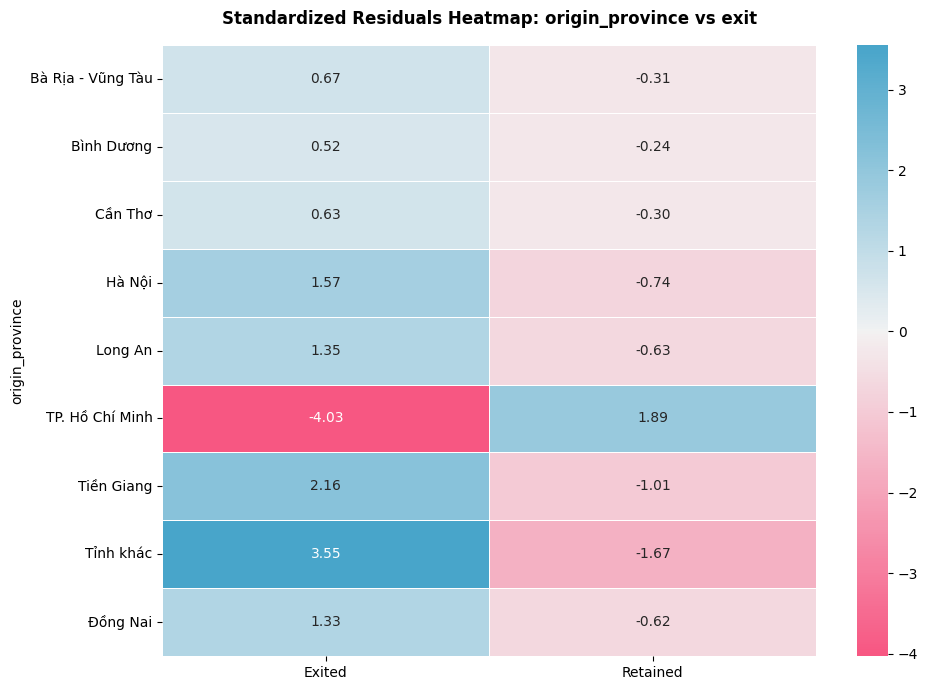

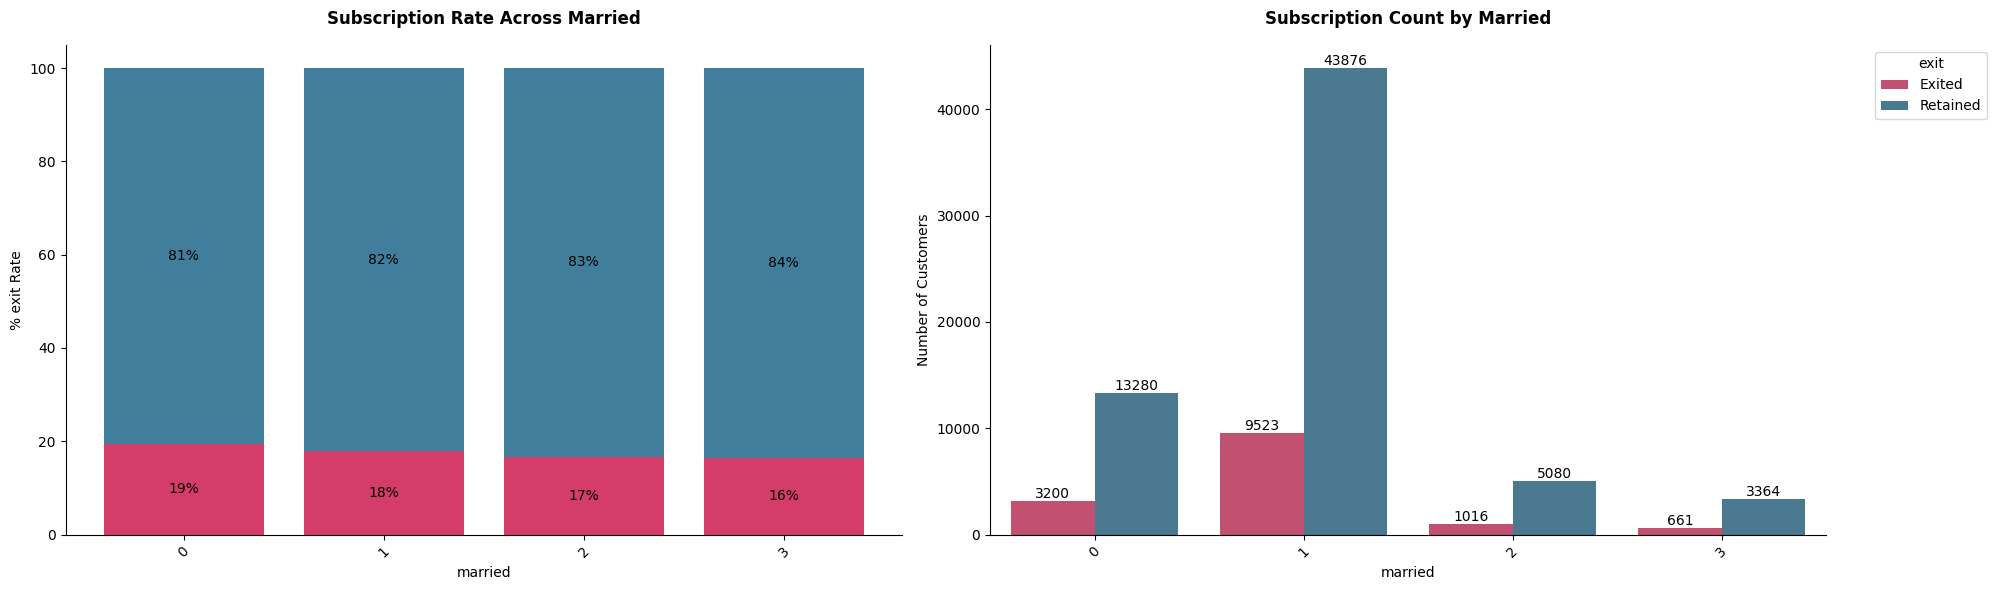

2026-07-24 18:58:40 | INFO     | Chi-Square Test of Independence: 'married' vs. 'exit'...
2026-07-24 18:58:40 | INFO     | Chi-squared statistic: 37.564
2026-07-24 18:58:40 | INFO     | Degrees of freedom: 3
2026-07-24 18:58:40 | INFO     | p-value: 0.000000
2026-07-24 18:58:40 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-24 18:58:40 | INFO     | Variables 'married' and 'exit' are statistically associated.
2026-07-24 18:58:40 | DEBUG    | Displaying standardized residuals heatmap.


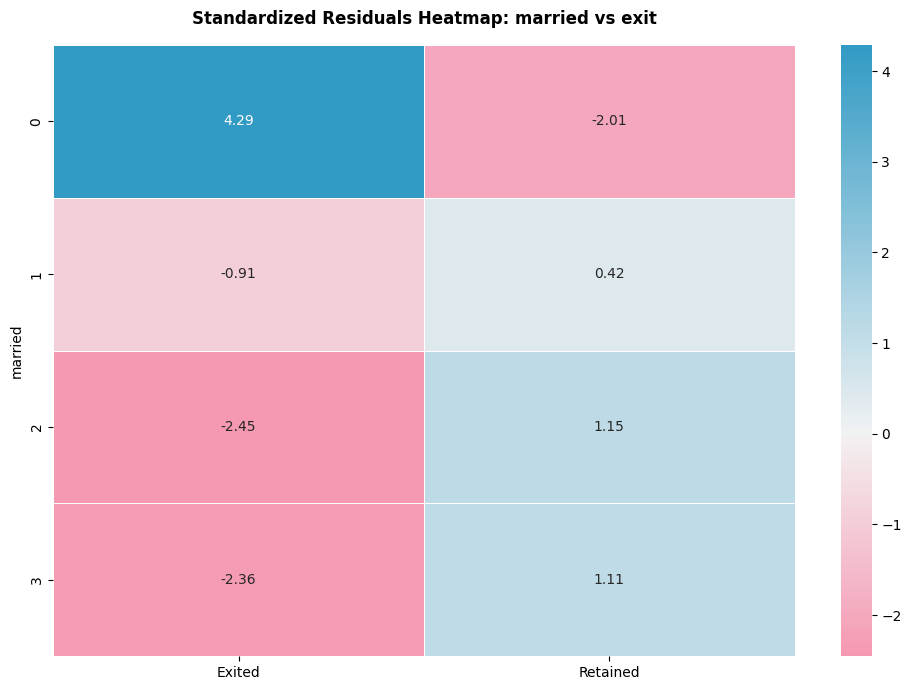

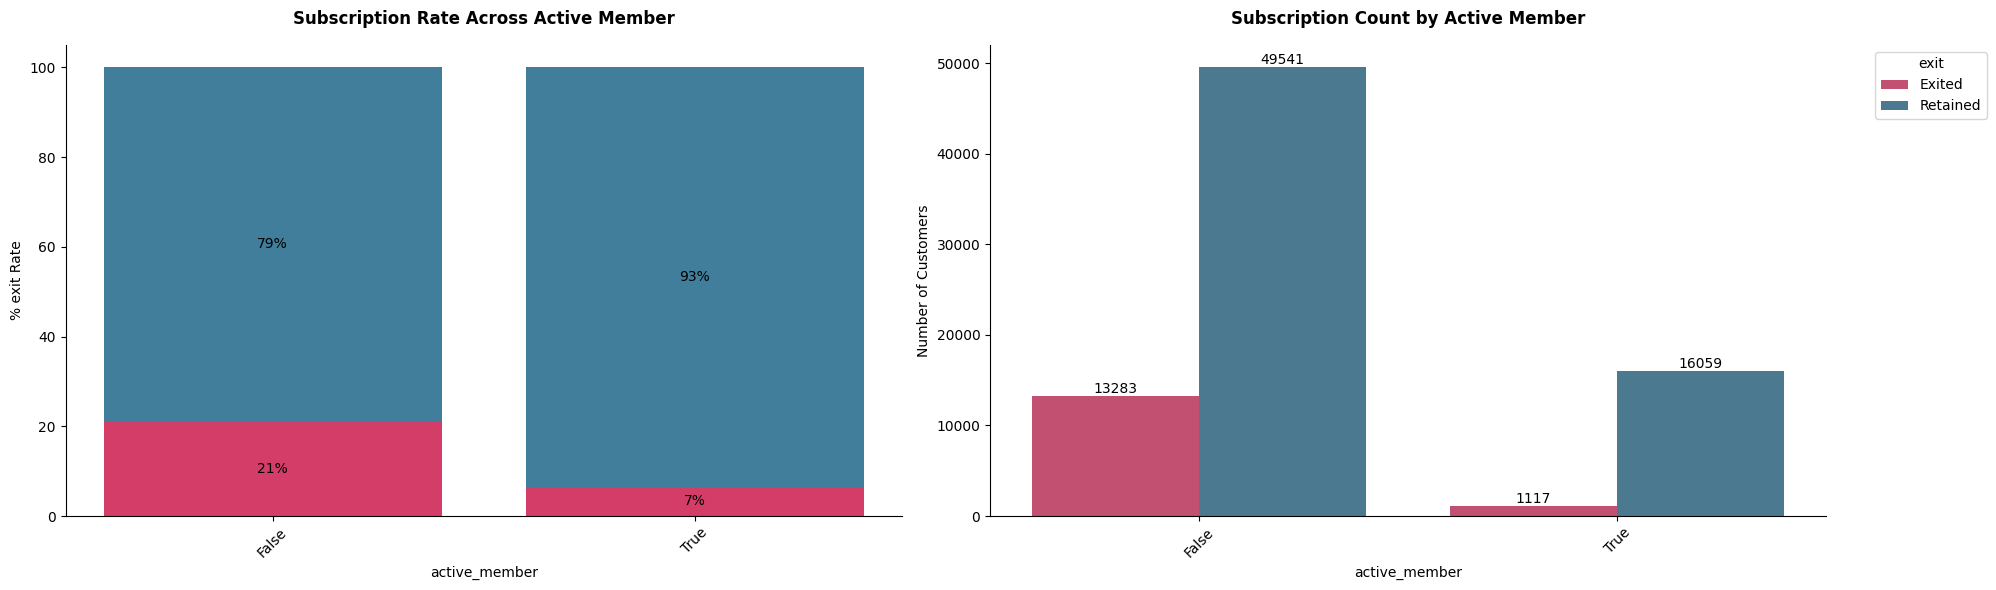

2026-07-24 18:58:40 | INFO     | Chi-Square Test of Independence: 'active_member' vs. 'exit'...
2026-07-24 18:58:40 | INFO     | Chi-squared statistic: 1957.625
2026-07-24 18:58:40 | INFO     | Degrees of freedom: 1
2026-07-24 18:58:40 | INFO     | p-value: 0.000000
2026-07-24 18:58:40 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-24 18:58:40 | INFO     | Variables 'active_member' and 'exit' are statistically associated.
2026-07-24 18:58:40 | DEBUG    | Displaying standardized residuals heatmap.


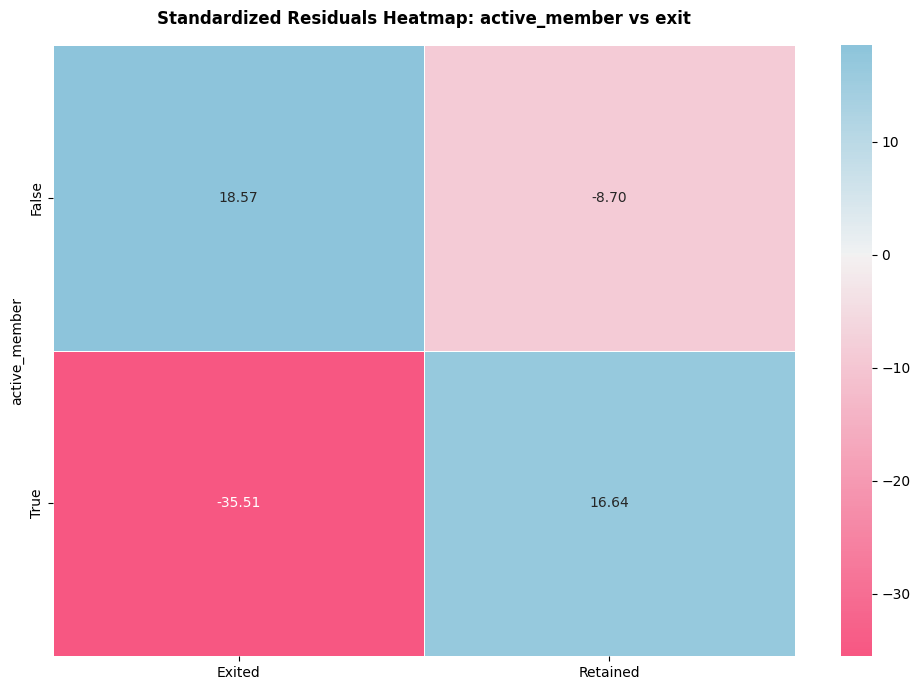

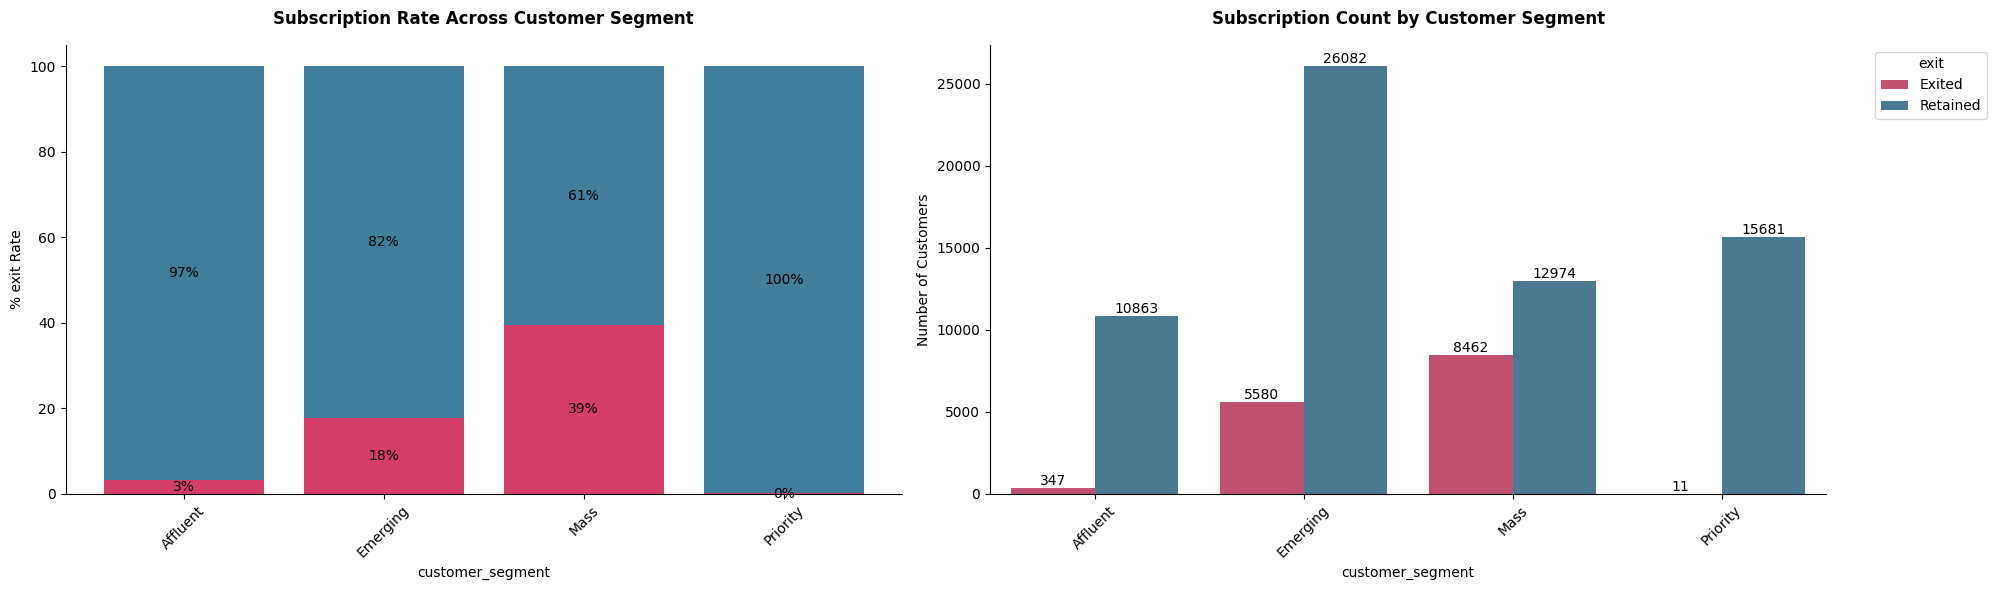

2026-07-24 18:58:40 | INFO     | Chi-Square Test of Independence: 'customer_segment' vs. 'exit'...
2026-07-24 18:58:40 | INFO     | Chi-squared statistic: 11806.084
2026-07-24 18:58:40 | INFO     | Degrees of freedom: 3
2026-07-24 18:58:40 | INFO     | p-value: 0.000000
2026-07-24 18:58:40 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-24 18:58:40 | INFO     | Variables 'customer_segment' and 'exit' are statistically associated.
2026-07-24 18:58:40 | DEBUG    | Displaying standardized residuals heatmap.


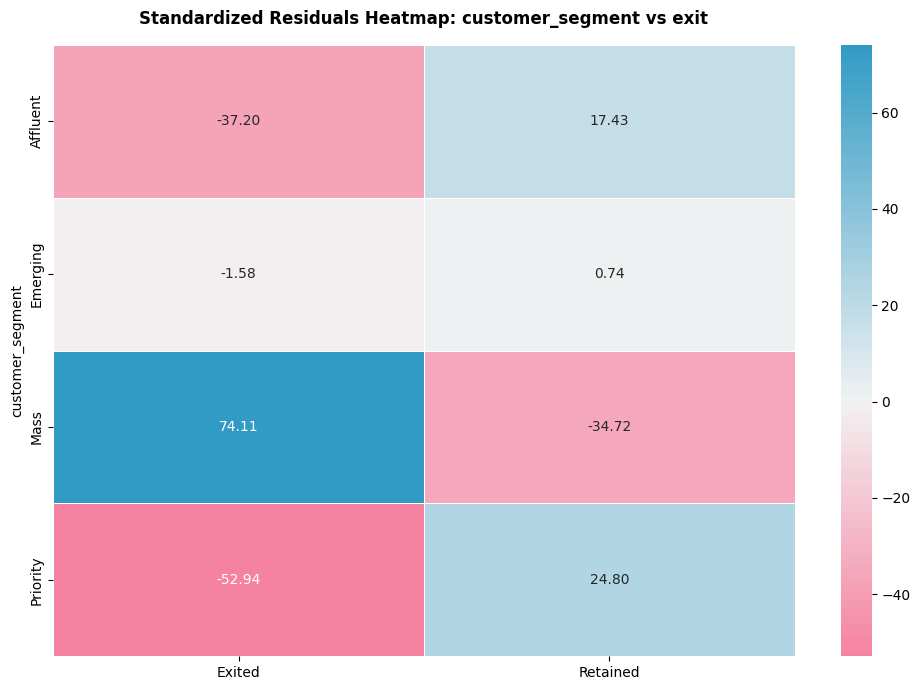

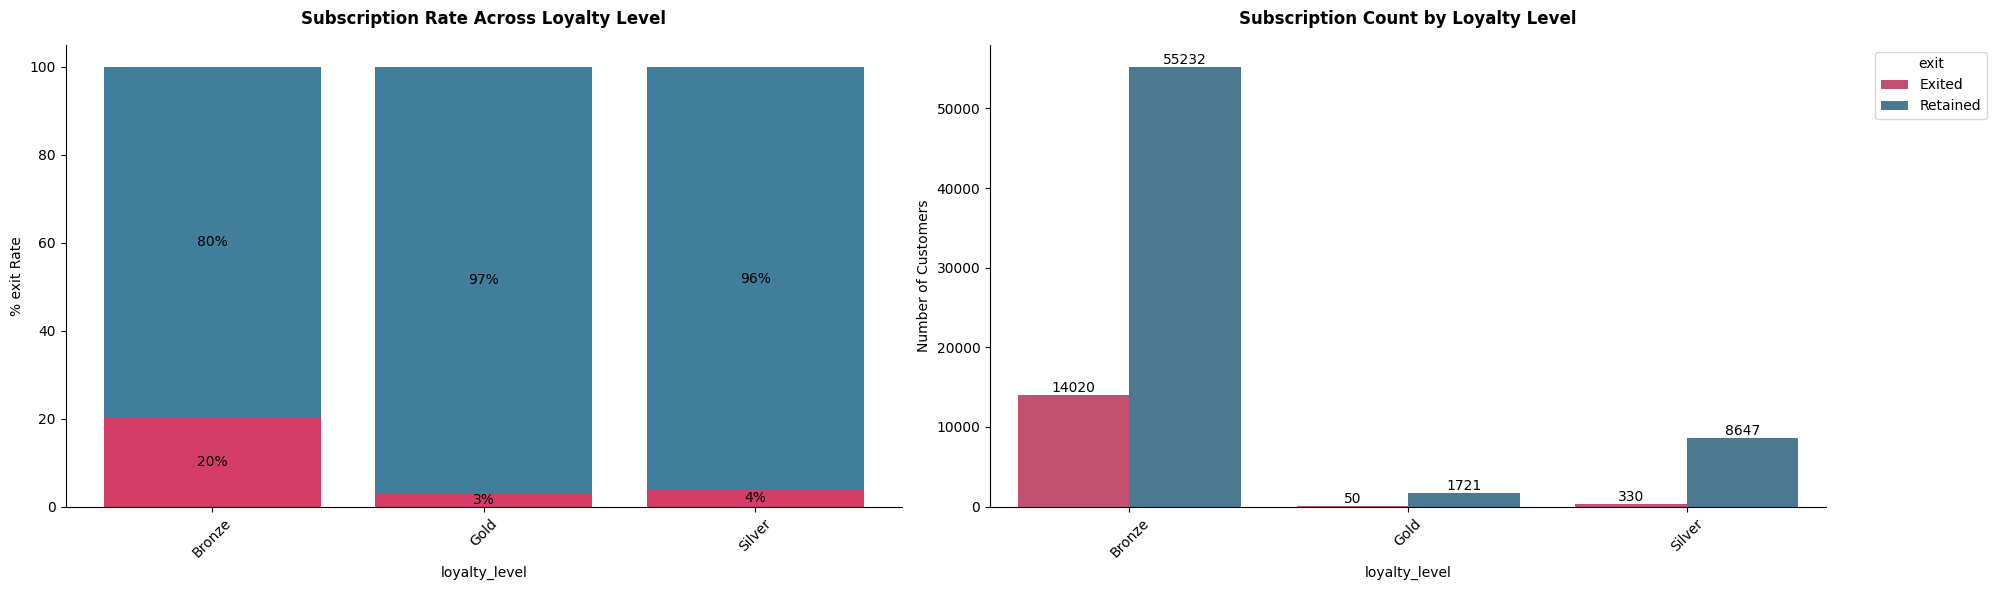

2026-07-24 18:58:41 | INFO     | Chi-Square Test of Independence: 'loyalty_level' vs. 'exit'...
2026-07-24 18:58:41 | INFO     | Chi-squared statistic: 1760.691
2026-07-24 18:58:41 | INFO     | Degrees of freedom: 2
2026-07-24 18:58:41 | INFO     | p-value: 0.000000
2026-07-24 18:58:41 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-24 18:58:41 | INFO     | Variables 'loyalty_level' and 'exit' are statistically associated.
2026-07-24 18:58:41 | DEBUG    | Displaying standardized residuals heatmap.


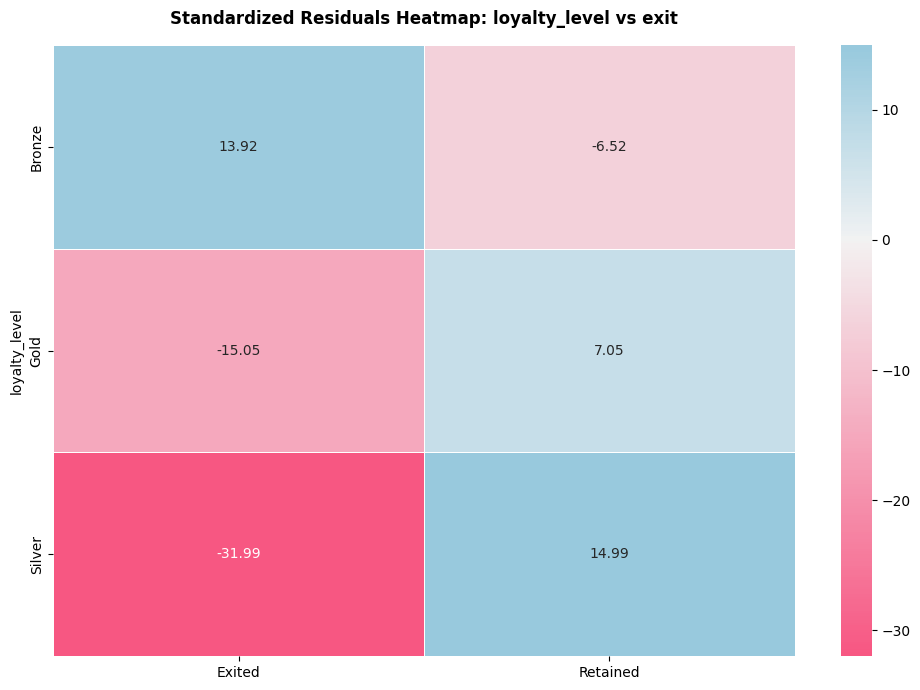

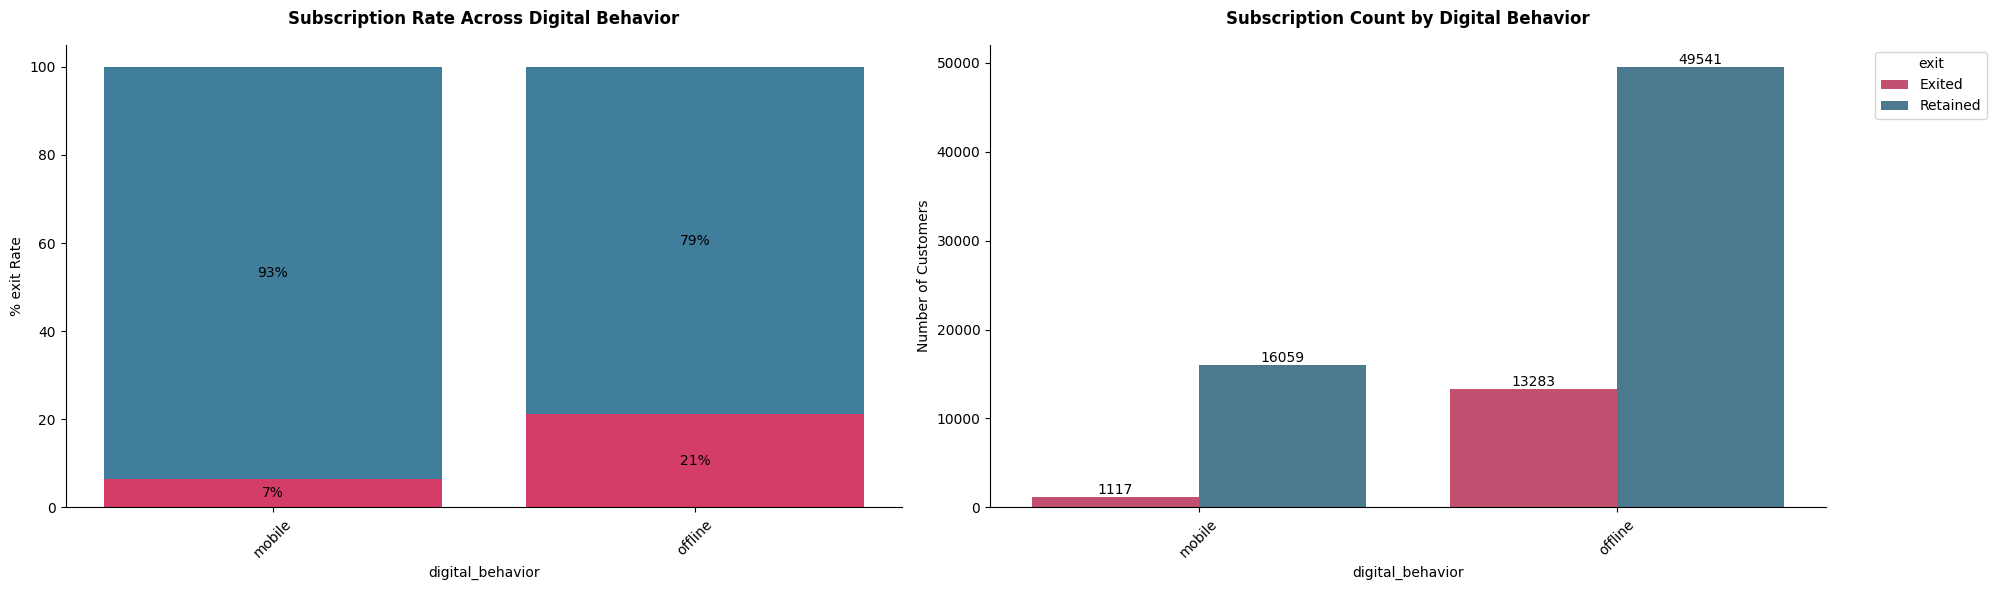

2026-07-24 18:58:42 | INFO     | Chi-Square Test of Independence: 'digital_behavior' vs. 'exit'...
2026-07-24 18:58:42 | INFO     | Chi-squared statistic: 1957.625
2026-07-24 18:58:42 | INFO     | Degrees of freedom: 1
2026-07-24 18:58:42 | INFO     | p-value: 0.000000
2026-07-24 18:58:42 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-24 18:58:42 | INFO     | Variables 'digital_behavior' and 'exit' are statistically associated.
2026-07-24 18:58:42 | DEBUG    | Displaying standardized residuals heatmap.


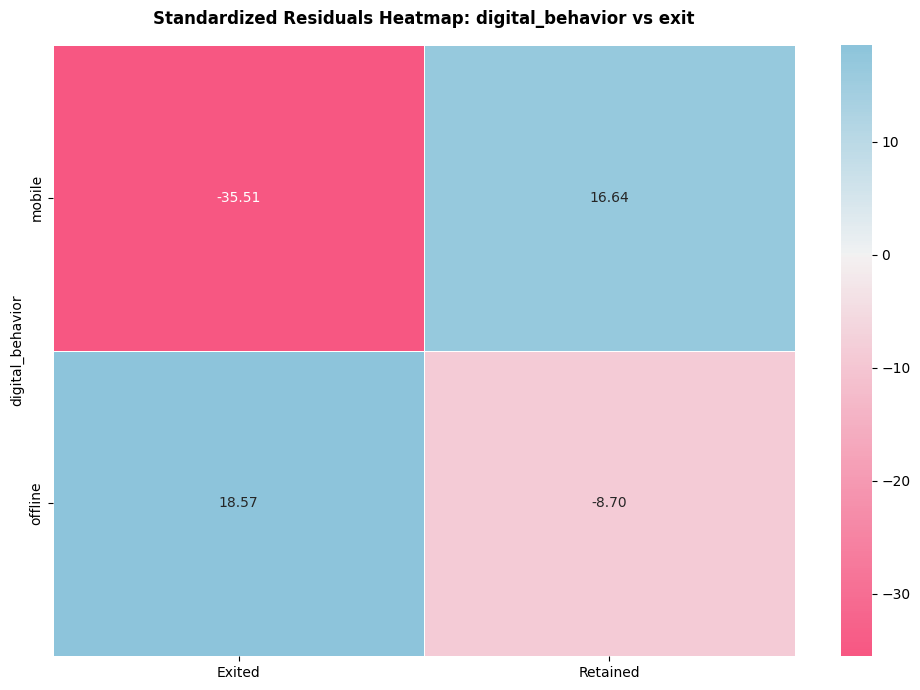

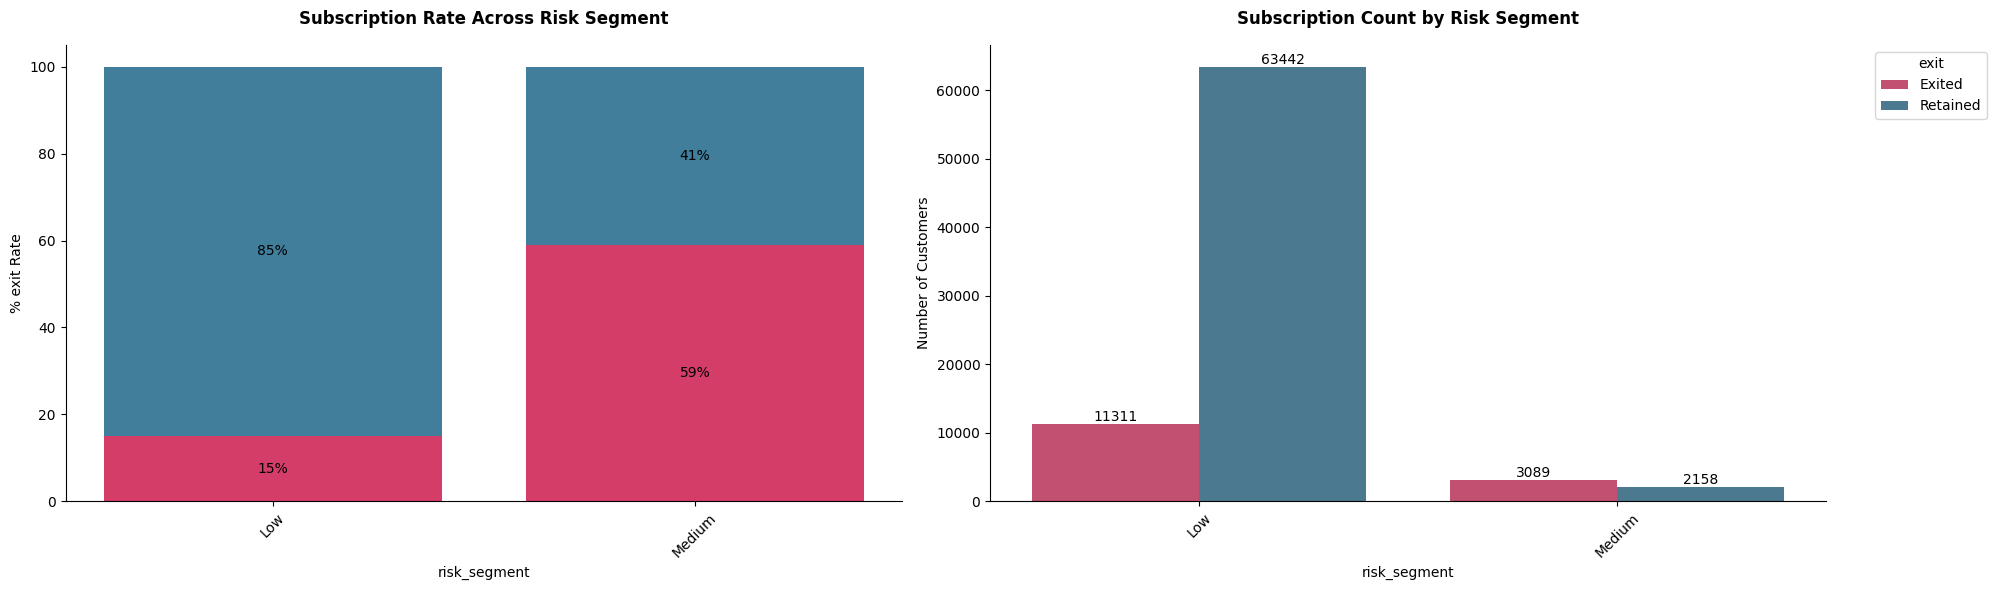

2026-07-24 18:58:42 | INFO     | Chi-Square Test of Independence: 'risk_segment' vs. 'exit'...
2026-07-24 18:58:42 | INFO     | Chi-squared statistic: 6352.281
2026-07-24 18:58:42 | INFO     | Degrees of freedom: 1
2026-07-24 18:58:42 | INFO     | p-value: 0.000000
2026-07-24 18:58:42 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-24 18:58:42 | INFO     | Variables 'risk_segment' and 'exit' are statistically associated.
2026-07-24 18:58:42 | DEBUG    | Displaying standardized residuals heatmap.


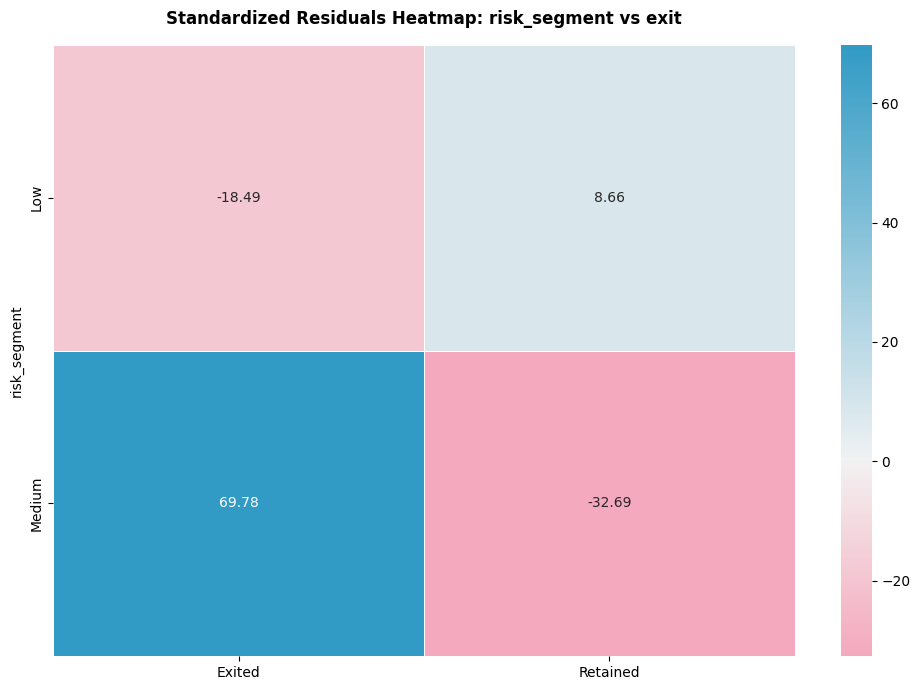

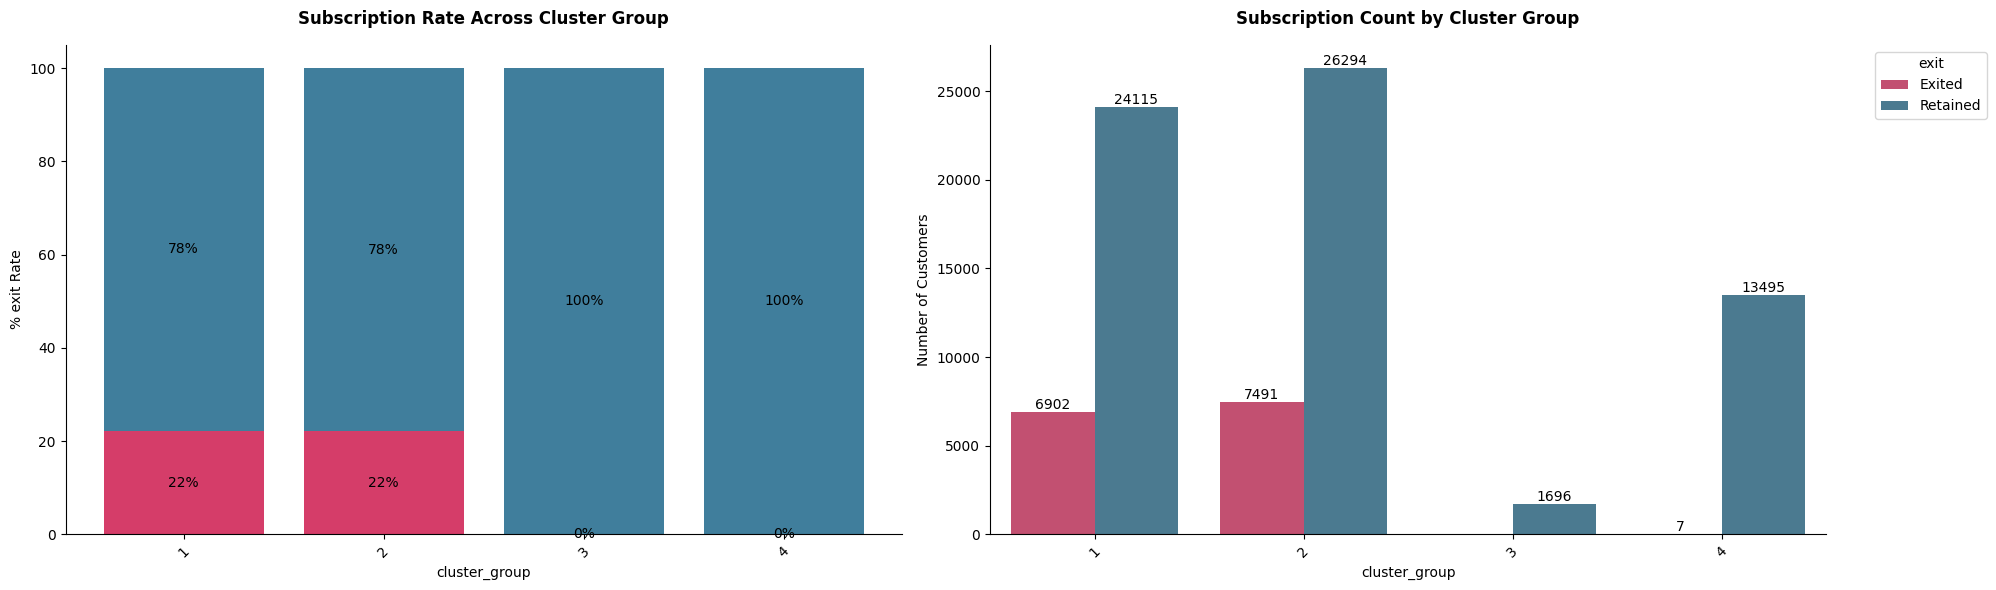

2026-07-24 18:58:42 | INFO     | Chi-Square Test of Independence: 'cluster_group' vs. 'exit'...
2026-07-24 18:58:42 | INFO     | Chi-squared statistic: 4097.594
2026-07-24 18:58:42 | INFO     | Degrees of freedom: 3
2026-07-24 18:58:42 | INFO     | p-value: 0.000000
2026-07-24 18:58:42 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-24 18:58:42 | INFO     | Variables 'cluster_group' and 'exit' are statistically associated.
2026-07-24 18:58:42 | DEBUG    | Displaying standardized residuals heatmap.


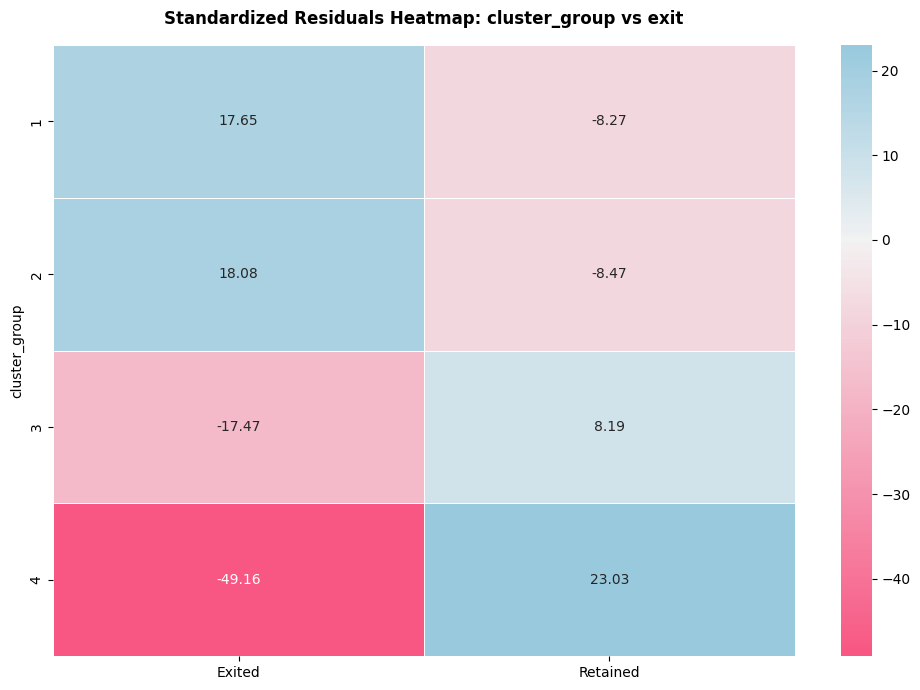

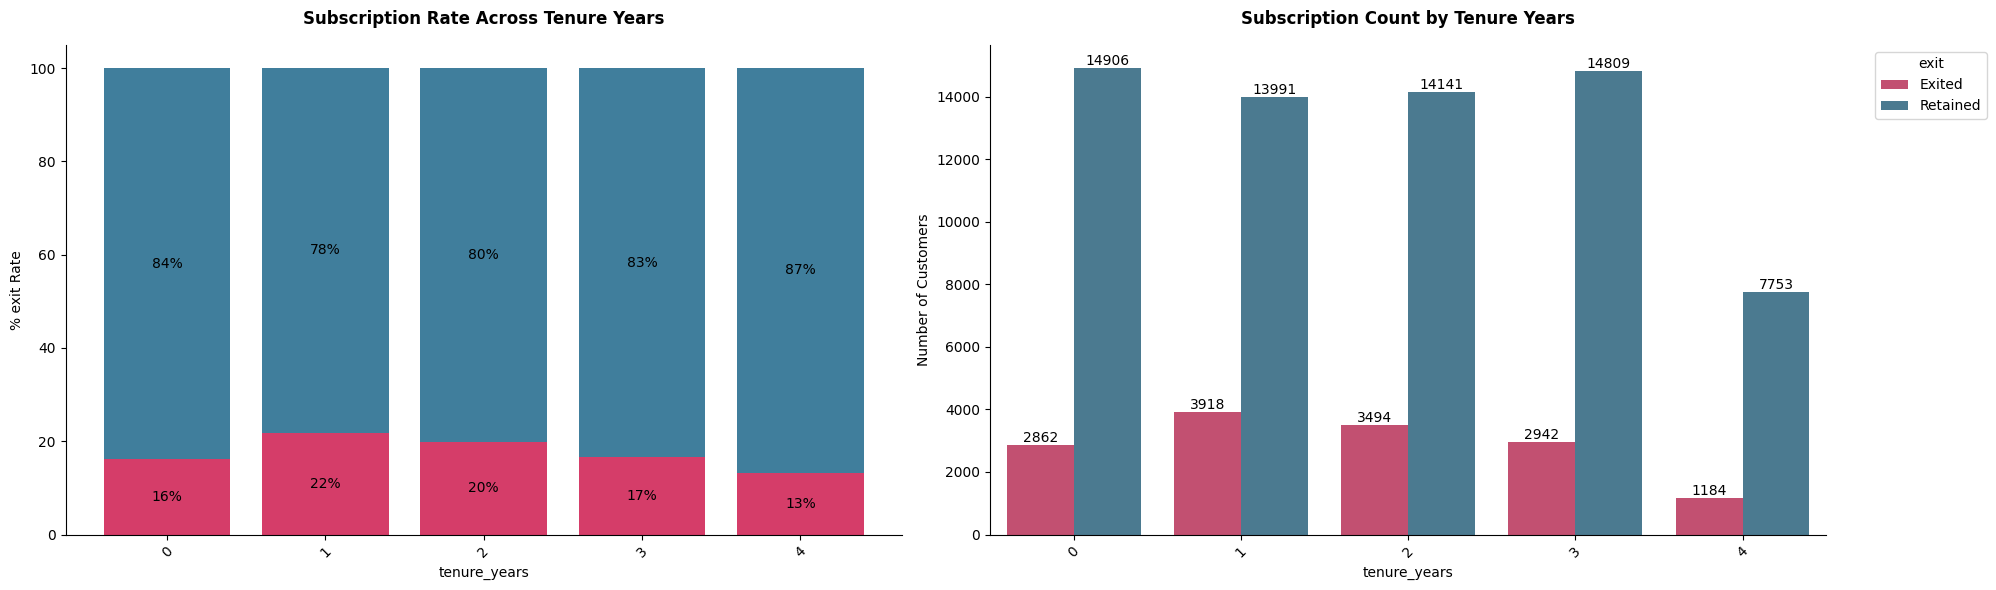

2026-07-24 18:58:43 | INFO     | Chi-Square Test of Independence: 'tenure_years' vs. 'exit'...
2026-07-24 18:58:43 | INFO     | Chi-squared statistic: 425.958
2026-07-24 18:58:43 | INFO     | Degrees of freedom: 4
2026-07-24 18:58:43 | INFO     | p-value: 0.000000
2026-07-24 18:58:43 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-24 18:58:43 | INFO     | Variables 'tenure_years' and 'exit' are statistically associated.
2026-07-24 18:58:43 | DEBUG    | Displaying standardized residuals heatmap.


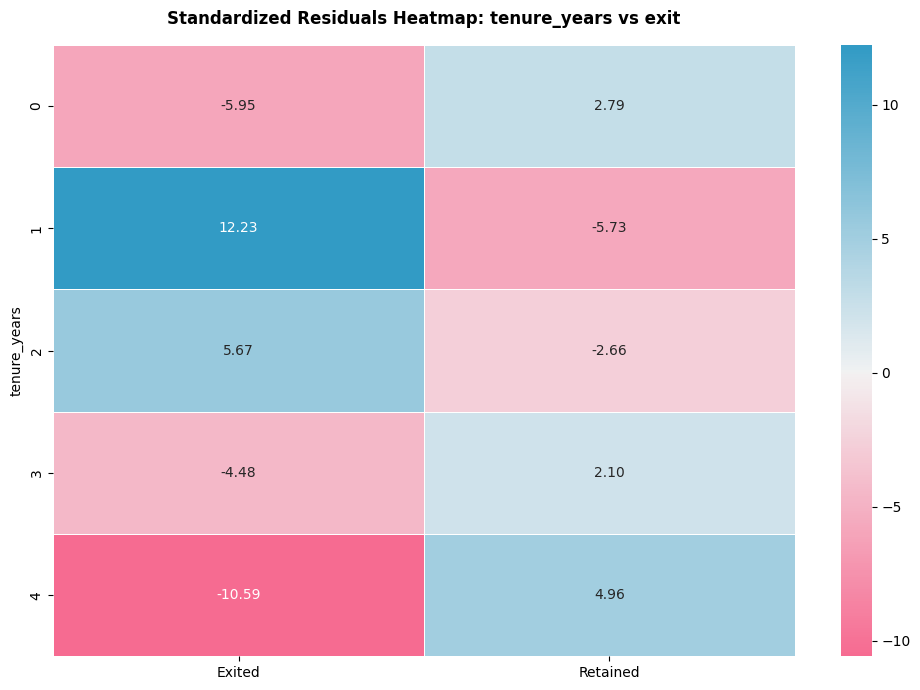

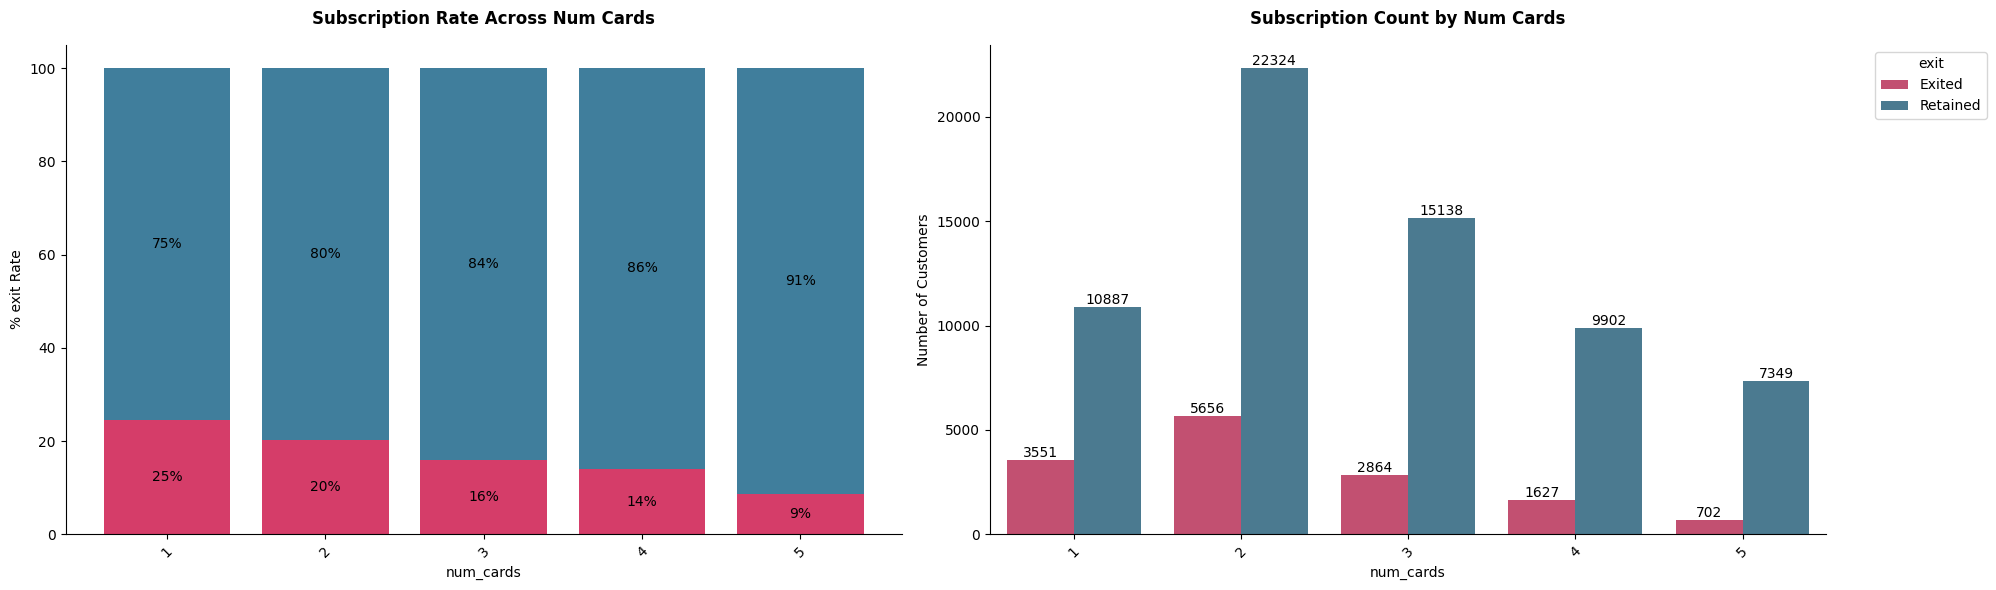

2026-07-24 18:58:43 | INFO     | Chi-Square Test of Independence: 'num_cards' vs. 'exit'...
2026-07-24 18:58:43 | INFO     | Chi-squared statistic: 1159.558
2026-07-24 18:58:43 | INFO     | Degrees of freedom: 4
2026-07-24 18:58:43 | INFO     | p-value: 0.000000
2026-07-24 18:58:43 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-24 18:58:43 | INFO     | Variables 'num_cards' and 'exit' are statistically associated.
2026-07-24 18:58:43 | DEBUG    | Displaying standardized residuals heatmap.


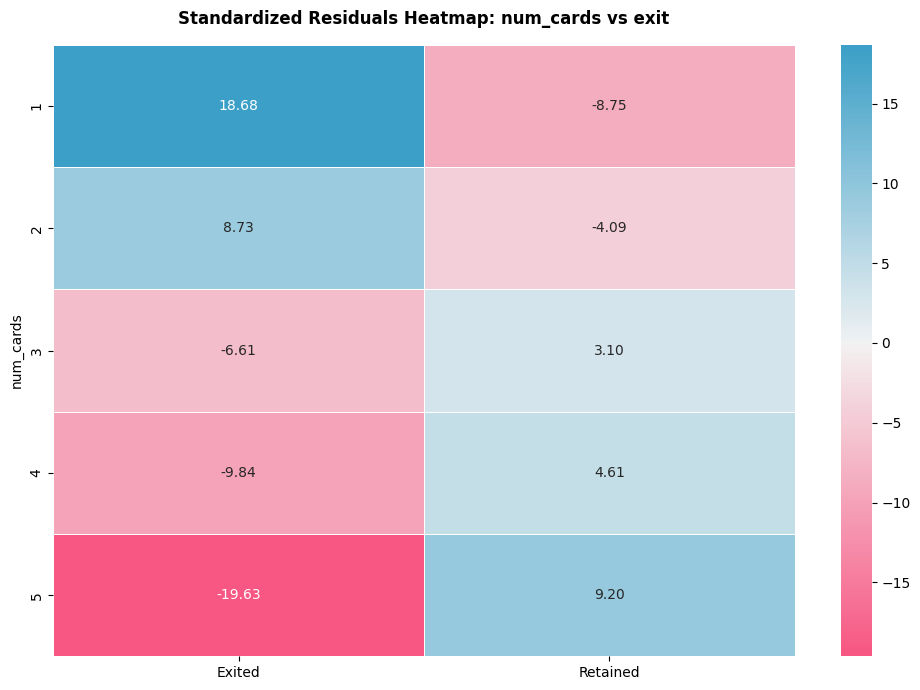

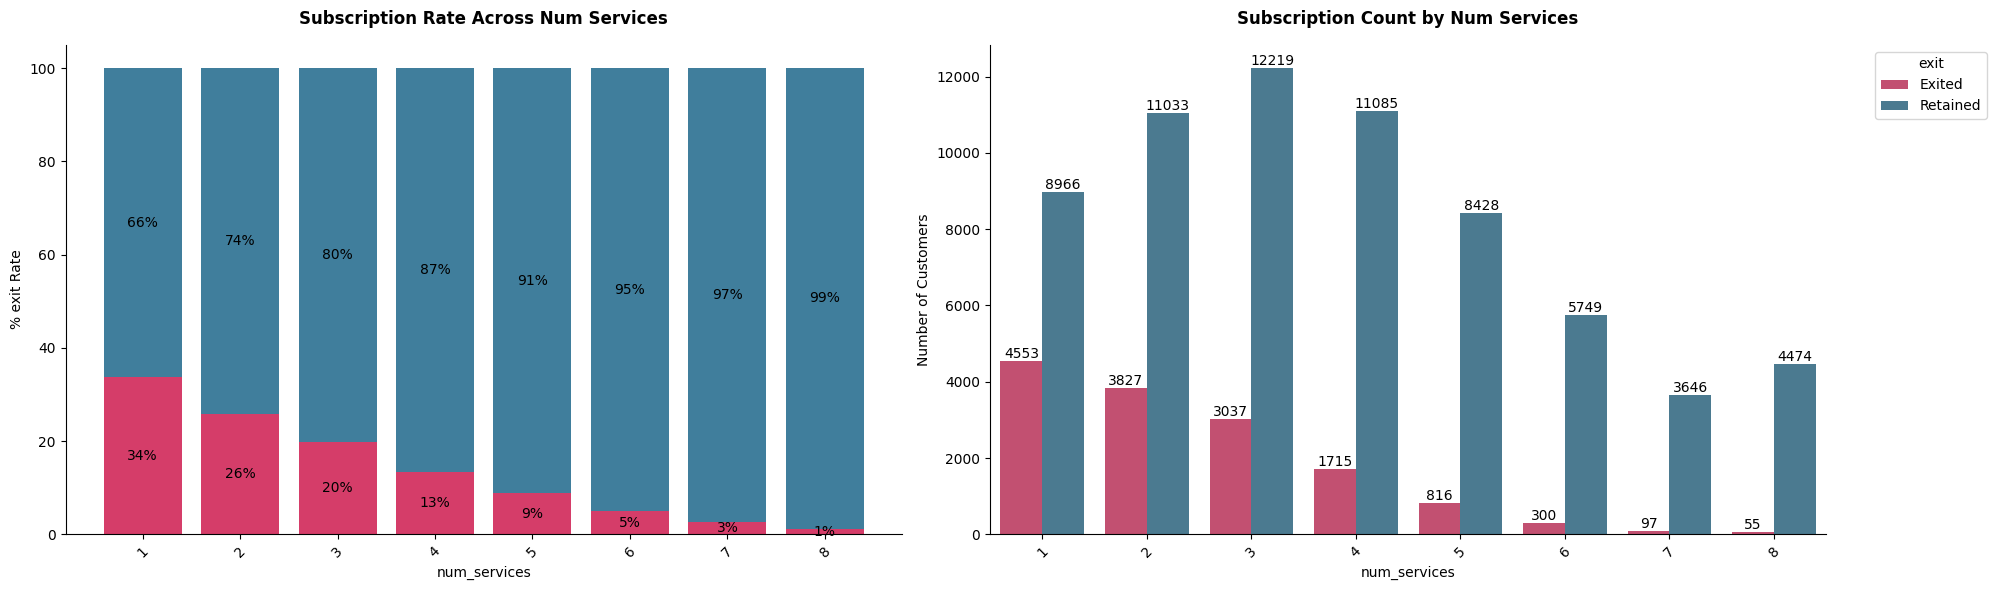

2026-07-24 18:58:44 | INFO     | Chi-Square Test of Independence: 'num_services' vs. 'exit'...
2026-07-24 18:58:44 | INFO     | Chi-squared statistic: 5768.463
2026-07-24 18:58:44 | INFO     | Degrees of freedom: 7
2026-07-24 18:58:44 | INFO     | p-value: 0.000000
2026-07-24 18:58:44 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-07-24 18:58:44 | INFO     | Variables 'num_services' and 'exit' are statistically associated.
2026-07-24 18:58:44 | DEBUG    | Displaying standardized residuals heatmap.


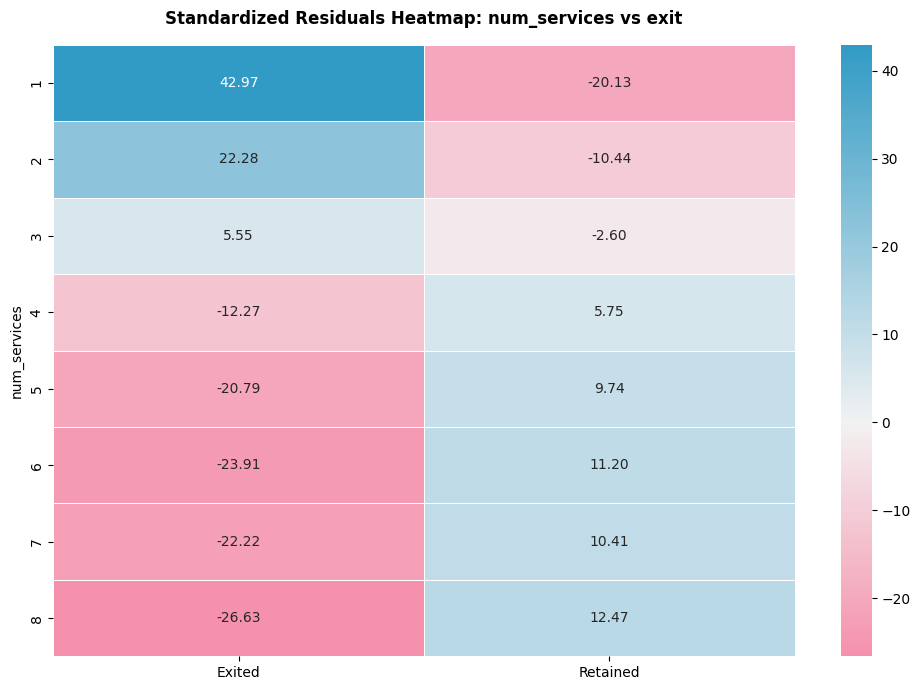

In [18]:
for feature in cat_features:
    StatUtils.analyze_categorical_feature_vs_target(cat = feature, target_feature=CFG.TARGET_FEATURE,
                                                    logger=logger, df=df_churn)

<div style="
    background: linear-gradient(135deg, #064e3b, #065f46, #047857);
    color: #f8fafc;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 8px 20px rgba(20,83,45,0.35);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size: 22px;
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Categorical Feature Insights
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>
<b>Gender:</b> Male and female customers have nearly identical churn rates (~18%).
The association is not statistically significant (<b>p = 0.462</b>), suggesting that
<code>gender</code> has little relevance to churn.
</li>

<li>
<b>Occupation:</b> Churn differs significantly across occupations (<b>p &lt; 0.001</b>).
<code>Nội trợ/Sinh viên</code>, <code>Lao động phổ thông</code>, and <code>Hưu trí</code>
show the highest churn rates.
</li>

<li>
<b>Origin Province:</b> Although statistically significant (<b>p &lt; 0.001</b>),
churn rates remain relatively similar across regions (~17–20%), suggesting
a limited practical regional effect.
</li>

<li>
<b>Married:</b> Churn varies only slightly across marital-status groups (~16–19%).
Despite statistical significance (<b>p &lt; 0.001</b>), the practical effect appears limited.
</li>

<li>
<b>Active Member:</b> Inactive customers have a substantially higher churn rate
(<b>21%</b>) than active customers (<b>7%</b>), indicating a strong relationship
between customer activity and retention (<b>p &lt; 0.001</b>).
</li>

<li>
<b>Customer Segment:</b> The <code>Mass</code> segment has the highest churn rate
(~39%), while <code>Affluent</code> and <code>Priority</code> customers show much stronger
retention (<b>p &lt; 0.001</b>).
</li>

<li>
<b>Loyalty Level:</b> <code>Bronze</code> customers have much higher churn (~20%)
than <code>Silver</code> and <code>Gold</code> customers (~3–4%), showing a strong
relationship between loyalty and retention (<b>p &lt; 0.001</b>).
</li>

<li>
<b>Digital Behavior:</b> Offline customers have substantially higher churn
(<b>21%</b>) than mobile customers (<b>7%</b>), suggesting digital engagement
is strongly associated with retention (<b>p &lt; 0.001</b>).
</li>

<li>
<b>Risk Segment:</b> <code>Medium</code>-risk customers have a dramatically higher
churn rate (<b>59%</b>) than <code>Low</code>-risk customers (<b>15%</b>), making
<code>risk_segment</code> a strong churn indicator (<b>p &lt; 0.001</b>).
</li>

<li>
<b>Cluster Group:</b> Clusters <code>1–2</code> show much higher churn (~22%),
while Clusters <code>3–4</code> are almost entirely retained, indicating clear
separation of churn-risk profiles (<b>p &lt; 0.001</b>).
</li>

<li>
<b>Tenure Years:</b> Churn is highest at <code>1–2 years</code> (~22% and 20%)
and falls to ~13% at 4 years, suggesting stronger retention among longer-tenured
customers (<b>p &lt; 0.001</b>).
</li>

<li>
<b>Number of Cards:</b> Churn steadily declines from ~25% for customers with
<code>1 card</code> to ~9% for those with <code>5 cards</code>, suggesting greater
card adoption is associated with retention (<b>p &lt; 0.001</b>).
</li>

<li>
<b>Number of Services:</b> Churn decreases sharply from ~34% among customers using
<code>1 service</code> to ~1% among those using <code>8 services</code>, indicating
that deeper product adoption is strongly associated with retention (<b>p &lt; 0.001</b>).
</li>

</ul>

</div>


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Overall Picture</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #064e3b, #065f46 35%, #047857 70%, #10b981);
    text-align: center; 
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Overall Picture
    </h1>
</div>


<div style="
    background: linear-gradient(135deg, #0b3d2e, #145a32);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.30);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Overall Picture
</div>

<table style="
    width:100%;
    border-collapse: collapse;
    background-color: rgba(255,255,255,0.04);
    font-size: 14px;
">

<tr style="background-color: rgba(249,231,159,0.15);">
    <th style="padding:12px; border:1px solid #5d8a72; text-align:left;">
        Feature
    </th>
    <th style="padding:12px; border:1px solid #5d8a72; text-align:left;">
        Key Insight
    </th>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#ff6b6b;">Credit Score</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Strong churn indicator → retained customers have substantially higher credit scores than exited customers.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;"><b>Age</b></td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Limited practical impact → exited customers are slightly younger, but the difference is small.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#ff6b6b;">Balance</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Strong retention signal → customers with higher account balances are substantially more likely to remain.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#f9e79f;">Monthly Income</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Higher-income customers show considerably stronger retention than lower-income customers.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;"><b>Last Transaction Amount</b></td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Limited practical influence → transaction amounts differ between groups, but the overall churn effect is small.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#f9e79f;">Engagement Score</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Stronger customer engagement is associated with substantially better retention.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#ff6b6b;">Risk Score</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Strong churn indicator → exited customers have substantially higher risk scores.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;"><b>Gender</b></td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        No meaningful churn relationship → male and female customers show nearly identical churn rates.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#f9e79f;">Occupation</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Churn varies substantially by occupation, with students/homemakers, manual workers, and retirees showing higher risk.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;"><b>Origin Province</b></td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Limited regional impact → churn rates remain relatively similar across provinces.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;"><b>Married</b></td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Marital status shows only minor differences in churn behavior and limited practical influence.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#ff6b6b;">Active Member</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Strong retention driver → inactive customers churn substantially more often than active customers.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#ff6b6b;">Customer Segment</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Strong segmentation effect → Mass customers show the highest churn, while Affluent and Priority customers retain much better.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#ff6b6b;">Loyalty Level</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Higher loyalty strongly improves retention → Bronze customers churn considerably more than Silver and Gold customers.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#ff6b6b;">Digital Behavior</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Digital engagement matters → offline customers churn substantially more often than mobile customers.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#ff6b6b;">Risk Segment</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Strong churn indicator → Medium-risk customers show dramatically higher churn than Low-risk customers.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#ff6b6b;">Cluster Group</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Clear churn-risk separation → Clusters 1–2 show higher churn, while Clusters 3–4 are strongly retained.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#f9e79f;">Tenure Years</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Longer customer relationships generally improve retention, with churn declining among longer-tenured customers.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#f9e79f;">Number of Cards</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Greater card adoption is associated with stronger retention, as churn steadily decreases with more cards.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#ff6b6b;">Number of Services</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Strong retention driver → churn falls sharply as customers use more banking services.
    </td>
</tr>

</table>

<div style="
    margin-top:18px;
    padding:12px 15px;
    background-color:rgba(0,0,0,0.15);
    border-radius:8px;
    font-size:13px;
">
    <span style="color:#ff6b6b;"><b>● Strong relationship</b></span>
    &nbsp;&nbsp;|&nbsp;&nbsp;
    <span style="color:#f9e79f;"><b>● Notable relationship</b></span>
    &nbsp;&nbsp;|&nbsp;&nbsp;
    <span style="color:#ecf0f1;"><b>● Limited / no practical impact</b></span>
</div>

</div>


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Metric</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #064e3b, #065f46 35%, #047857 70%, #10b981);
    text-align: center; 
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Metric
    </h1>
</div>


**AUC-ROC Overview**

**AUC-ROC** evaluates a model’s ability to **distinguish between two classes**.

- **ROC curve** plots **TPR vs FPR**
- **AUC** = Area under ROC curve → **ranking quality of predictions**

**Why AUC-ROC?**

- Robust to **class imbalance**
- Measures **ranking ability**, not fixed threshold (0.5)
- Common metric in **credit risk & fraud prediction**

> Higher AUC → better separation between _Paid_ vs _Default_

**Interpretation**

| AUC Score     | Meaning                  |
| ------------- | ------------------------ |
| **1.0**       | Perfect model            |
| **0.9+**      | Excellent discrimination |
| **0.7 – 0.9** | Good                     |
| **0.5**       | Random guessing          |
| **< 0.5**     | Worse than random        |

(Source: [ROC AUC](https://en.wikipedia.org/wiki/Receiver_operating_characteristic))


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Feature Engineering</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #064e3b, #065f46 35%, #047857 70%, #10b981);
    text-align: center; 
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Feature Engineering
    </h1>
</div>


In [19]:
logger.info("-" * 80)
logger.info("Starting date-based feature engineering...")

# Convert raw date columns to datetime format
df_churn["created_date"] = pd.to_datetime(df_churn["created_date"], errors="coerce")
df_churn["last_active_date"] = pd.to_datetime(df_churn["last_active_date"], errors="coerce")

# Calculate the number of days between customer creation
# and the customer's most recent activity
df_churn["active_duration_days"] = (df_churn["last_active_date"] - df_churn["created_date"]).dt.days

# Define observation/snapshot date
reference_date = df_churn["last_active_date"].max()

# Calculate customer inactivity recency:
# number of days since the customer's most recent activity
df_churn["days_since_last_active"] = (reference_date - df_churn["last_active_date"]).dt.days

# Remove raw dates
df_churn.drop(columns=["created_date", "last_active_date"], inplace=True)

logger.info("Removed raw date columns: ['created_date', 'last_active_date']")
logger.info("Date-based feature engineering completed successfully.")
logger.info("-" * 80)

# Numerical Features
num_features = ["credit_score", "age", "balance", "monthly_income", "last_transaction_amount", "engagement_score",
                "risk_score", "active_duration_days", "days_since_last_active"]

df_churn = Utils.reduce_mem_usage(cols=num_features, df=df_churn)
df_churn = Utils.convert_cat(features=cat_features, df=df_churn)

df_churn.info()

2026-07-24 18:58:44 | INFO     | --------------------------------------------------------------------------------
2026-07-24 18:58:44 | INFO     | Starting date-based feature engineering...
2026-07-24 18:58:44 | INFO     | Removed raw date columns: ['created_date', 'last_active_date']
2026-07-24 18:58:44 | INFO     | Date-based feature engineering completed successfully.
2026-07-24 18:58:44 | INFO     | --------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   credit_score             80000 non-null  int16   
 1   gender                   80000 non-null  category
 2   age                      80000 non-null  int8    
 3   occupation               80000 non-null  category
 4   balance                  80000 non-null  int32   
 5   monthly_incom

In [20]:
for col in cat_features:
    logger.info(
        f"{col:<20} | "
        f"dtype={df_churn[col].dtype} | "
        f"cat_dtype={df_churn[col].cat.categories.dtype} | "
        f"categories={df_churn[col].cat.categories.tolist()}"
    )

# Fix boolean categorical feature for XGBoost
df_churn["active_member"] = (
    df_churn["active_member"]
    .astype(str)
    .astype("category")
)
logger.info("-" * 80)
logger.info(df_churn["active_member"].cat.categories)
logger.info(df_churn["active_member"].cat.categories.dtype)

2026-07-24 18:58:44 | INFO     | gender               | dtype=category | cat_dtype=object | categories=['female', 'male']
2026-07-24 18:58:44 | INFO     | occupation           | dtype=category | cat_dtype=object | categories=['Chủ Doanh nghiệp nhỏ', 'Giáo viên/Giảng viên', 'Hưu trí', 'Kinh doanh/Bán hàng', 'Kế toán/Tài chính', 'Kỹ sư/Chuyên viên IT', 'Lao động phổ thông', 'Nhân viên văn phòng/Công chức', 'Nội trợ/Sinh viên', 'Quản lý/Lãnh đạo']
2026-07-24 18:58:44 | INFO     | origin_province      | dtype=category | cat_dtype=object | categories=['Bà Rịa - Vũng Tàu', 'Bình Dương', 'Cần Thơ', 'Hà Nội', 'Long An', 'TP. Hồ Chí Minh', 'Tiền Giang', 'Tỉnh khác', 'Đồng Nai']
2026-07-24 18:58:44 | INFO     | married              | dtype=category | cat_dtype=int64 | categories=[0, 1, 2, 3]
2026-07-24 18:58:44 | INFO     | active_member        | dtype=category | cat_dtype=bool | categories=[False, True]
2026-07-24 18:58:44 | INFO     | customer_segment     | dtype=category | cat_dtype=object | 

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #064e3b, #065f46 35%, #047857 70%, #10b981);
    text-align: center; 
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>


## Create Test Set


In [21]:
df_churn[CFG.TARGET_FEATURE] = df_churn[CFG.TARGET_FEATURE].map({"Retained": 0, "Exited": 1})
X = df_churn.drop(columns=CFG.TARGET_FEATURE)
y = df_churn[CFG.TARGET_FEATURE]

split = StratifiedShuffleSplit(n_splits=CFG.SPLIT["n_splits"], test_size=CFG.SPLIT["test_size"], 
                               random_state=CFG.RANDOM_STATE)

for train_idx, test_idx in split.split(X, y):
    X_train = X.iloc[train_idx]
    X_val = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[test_idx]

## CatBoostClassifier


2026-07-24 18:58:45 | INFO     | --------------------------------------------------------------------------------
2026-07-24 18:58:45 | INFO     | Starting CatBoost hyperparameter tuning
2026-07-24 18:58:57 | DEBUG    | Trial 0 | Fold 1/5 | AUC: 0.85247 | Best iteration: 104
2026-07-24 18:59:08 | DEBUG    | Trial 0 | Fold 2/5 | AUC: 0.85232 | Best iteration: 67
2026-07-24 18:59:19 | DEBUG    | Trial 0 | Fold 3/5 | AUC: 0.86038 | Best iteration: 85
2026-07-24 18:59:31 | DEBUG    | Trial 0 | Fold 4/5 | AUC: 0.85090 | Best iteration: 74
2026-07-24 18:59:44 | DEBUG    | Trial 0 | Fold 5/5 | AUC: 0.85723 | Best iteration: 134
2026-07-24 18:59:44 | INFO     | Trial 0 finished | Mean AUC: 0.85466 | Std: 0.00357
2026-07-24 19:00:09 | DEBUG    | Trial 1 | Fold 1/5 | AUC: 0.85296 | Best iteration: 561
2026-07-24 19:00:34 | DEBUG    | Trial 1 | Fold 2/5 | AUC: 0.85265 | Best iteration: 602
2026-07-24 19:01:00 | DEBUG    | Trial 1 | Fold 3/5 | AUC: 0.86082 | Best iteration: 582
2026-07-24 19:01:29

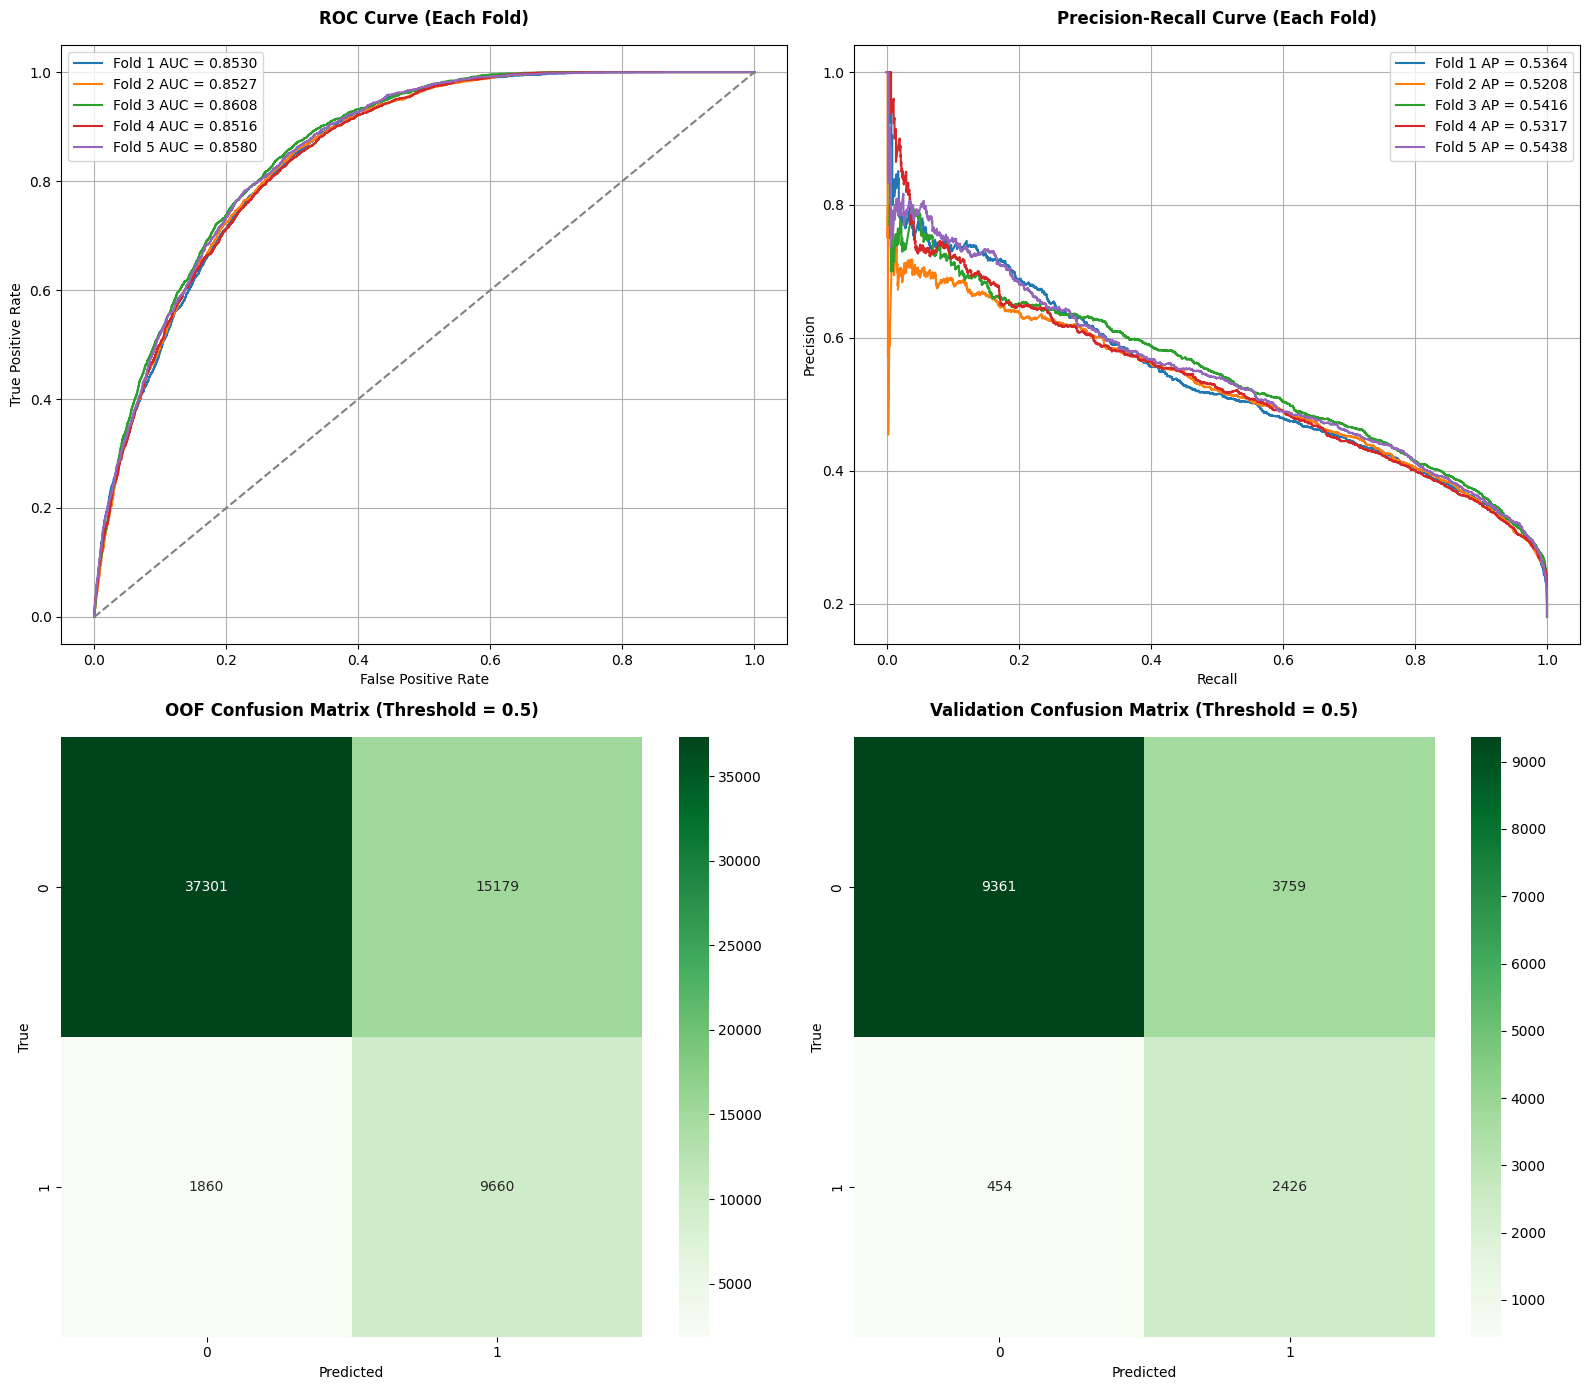

2026-07-24 19:10:22 | INFO     | CatBoost OOF evaluation completed
2026-07-24 19:10:22 | INFO     | --------------------------------------------------------------------------------


In [ ]:
logger.info("-" * 80)
logger.info("Starting CatBoost hyperparameter tuning")
study_cb = optuna.create_study(direction="maximize", study_name="catboost_churn_tuning")
study_cb.optimize(
    lambda trial: objective_catboost(
        trial=trial,
        X=X_train,
        y=y_train,
        cat_features=cat_features,
        logger=logger,
        n_splits=CFG.CV["n_splits"],
        random_state=CFG.RANDOM_STATE
    ),
    n_trials=5
)

logger.info("CatBoost hyperparameter tuning completed")
logger.info(f"Best CV AUC: {study_cb.best_value:.5f}")
logger.info(f"Best trial: {study_cb.best_trial.number}")
logger.info(f"Best parameters: {study_cb.best_params}")

logger.info("-" * 80)
logger.info("Initializing CatBoost model with best hyperparameters")

model_cb = CatBoostClassifier(**study_cb.best_params, loss_function="Logloss", auto_class_weights="Balanced", random_seed=CFG.RANDOM_STATE,
                              verbose = 0, thread_count=-1, eval_metric="Logloss", allow_writing_files = False, task_type="GPU", devices="0")
logger.info("-" * 80)
logger.info("Starting CatBoost OOF evaluation")
logger.info(
    f"Training samples: {len(X_train):,} | "
    f"Validation samples: {len(X_val):,} | "
    f"Features: {X_train.shape[1]} | "
    f"Categorical features: {len(cat_features)} | "
    f"CV Folds: {CFG.CV['n_splits']}"
)

results_cb = run_oof(model=model_cb, X=X_train, y=y_train, X_val=X_val, y_val=y_val, cat_features=cat_features, logger=logger)
logger.info("CatBoost OOF evaluation completed")
logger.info("-" * 80)

## LGBMClassifier


2026-07-24 19:10:22 | INFO     | --------------------------------------------------------------------------------
2026-07-24 19:10:22 | INFO     | Starting LightGBM hyperparameter tuning
2026-07-24 19:10:24 | DEBUG    | Trial 0 | Fold 1/5 | AUC: 0.84926 | Best iteration: 58
2026-07-24 19:10:26 | DEBUG    | Trial 0 | Fold 2/5 | AUC: 0.85039 | Best iteration: 113
2026-07-24 19:10:27 | DEBUG    | Trial 0 | Fold 3/5 | AUC: 0.85863 | Best iteration: 46
2026-07-24 19:10:29 | DEBUG    | Trial 0 | Fold 4/5 | AUC: 0.84925 | Best iteration: 126
2026-07-24 19:10:31 | DEBUG    | Trial 0 | Fold 5/5 | AUC: 0.85566 | Best iteration: 49
2026-07-24 19:10:31 | INFO     | Trial 0 finished | Mean AUC: 0.85264 | Std: 0.00382
2026-07-24 19:10:32 | DEBUG    | Trial 1 | Fold 1/5 | AUC: 0.85100 | Best iteration: 58
2026-07-24 19:10:34 | DEBUG    | Trial 1 | Fold 2/5 | AUC: 0.85199 | Best iteration: 98
2026-07-24 19:10:35 | DEBUG    | Trial 1 | Fold 3/5 | AUC: 0.85958 | Best iteration: 48
2026-07-24 19:10:36 | 

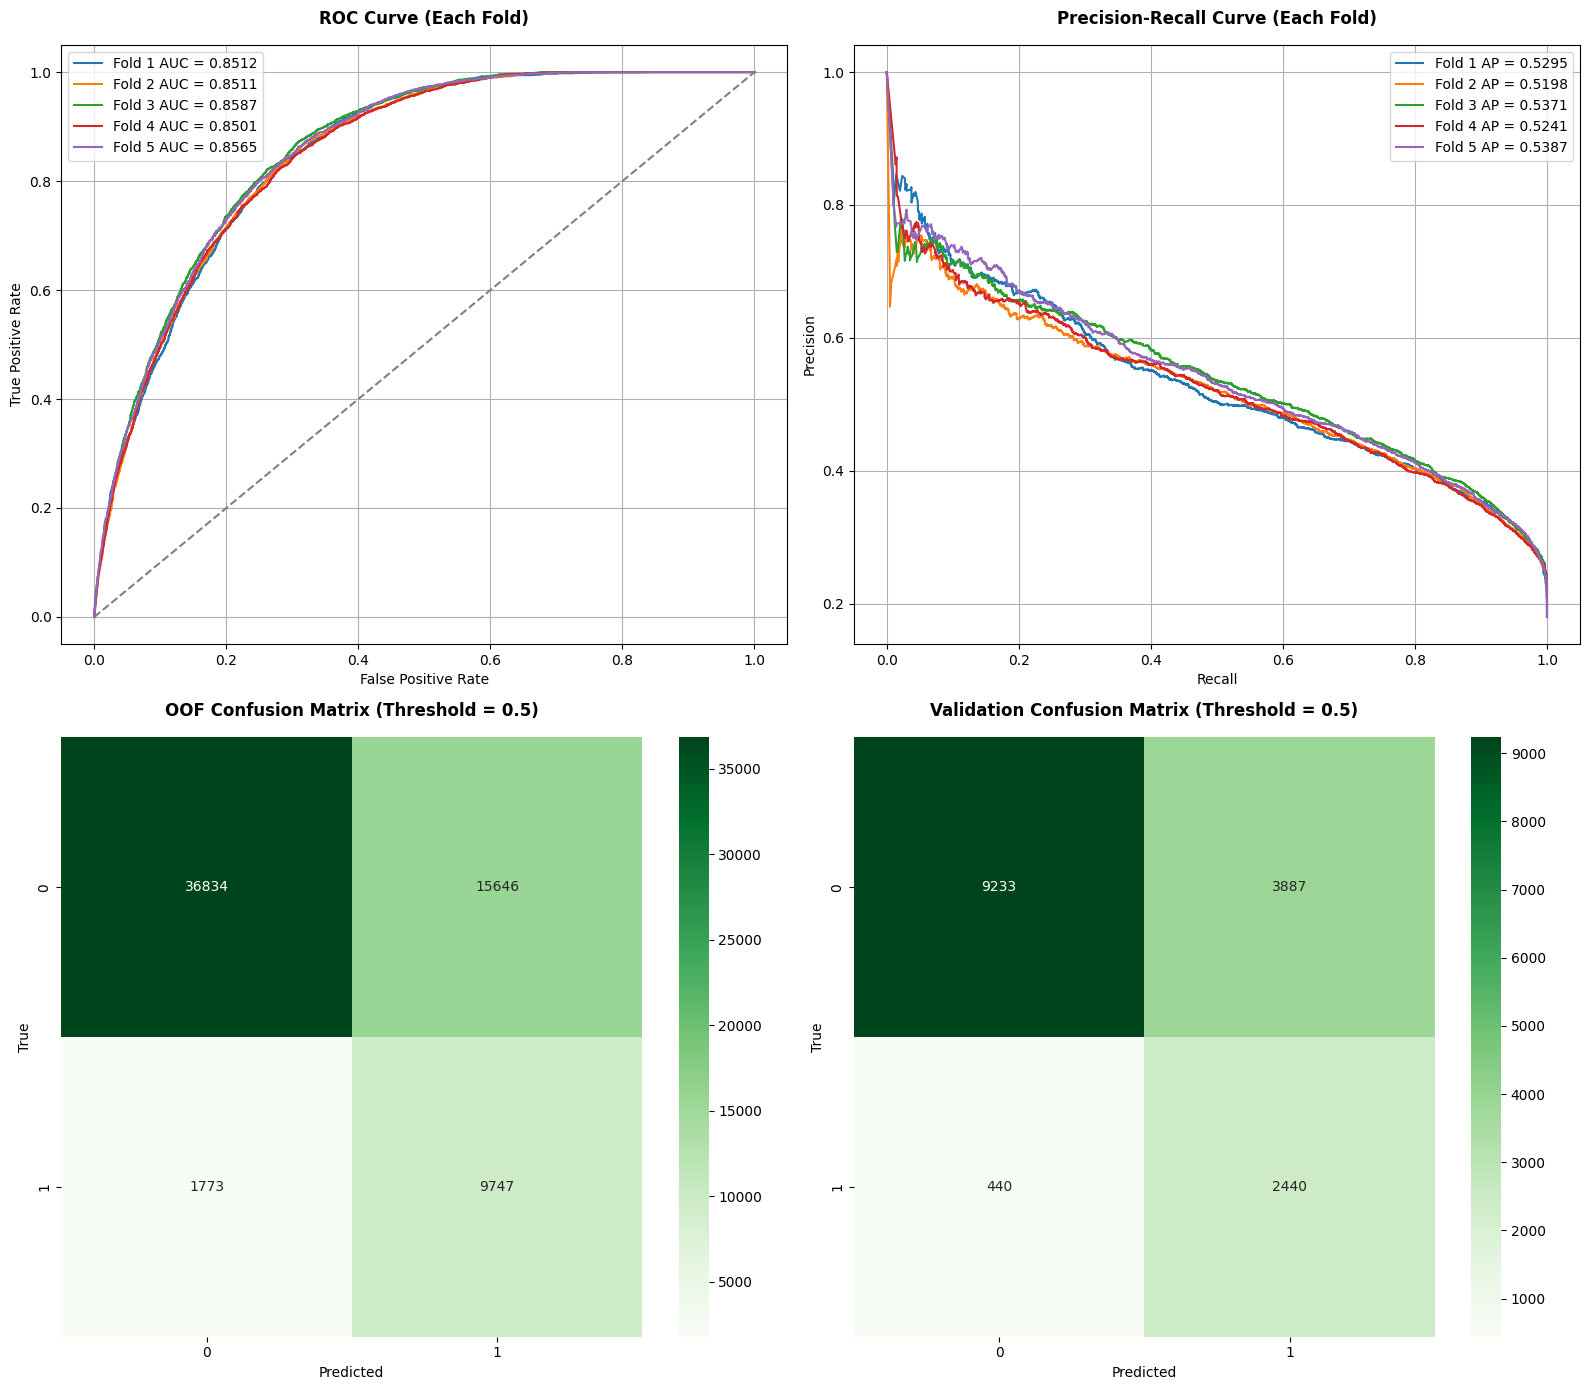

2026-07-24 19:11:54 | INFO     | LightGBM OOF evaluation completed
2026-07-24 19:11:54 | INFO     | --------------------------------------------------------------------------------


In [23]:
logger.info("-" * 80)
logger.info("Starting LightGBM hyperparameter tuning")
study_lgbm = optuna.create_study(direction="maximize", study_name="lightgbm_churn_tuning")
study_lgbm.optimize(
    lambda trial: objective_lgbm(
        trial=trial,
        X=X_train,
        y=y_train,
        cat_features=cat_features,
        logger=logger
    ),
    n_trials=10
)

logger.info("LightGBM hyperparameter tuning completed")
logger.info(f"Best CV AUC: {study_lgbm.best_value:.5f}")
logger.info(f"Best trial: {study_lgbm.best_trial.number}")
logger.info(f"Best parameters: {study_lgbm.best_params}")

logger.info("-" * 80)
logger.info("Initializing LightGBM model with best hyperparameters")

model_lgbm = lgb.LGBMClassifier(**study_lgbm.best_params, objective="binary", metric="auc",
                                verbosity=-1, n_jobs=-1, boosting_type="gbdt",
                                class_weight="balanced", random_state=CFG.RANDOM_STATE)
logger.info("-" * 80)
logger.info("Starting LightGBM OOF evaluation")
logger.info(
    f"Training samples: {len(X_train):,} | "
    f"Validation samples: {len(X_val):,} | "
    f"Features: {X_train.shape[1]} | "
    f"Categorical features: {len(cat_features)} | "
    f"CV Folds: {CFG.CV['n_splits']}"
)

results_lgbm = run_oof(model=model_lgbm, X=X_train, y=y_train, X_val=X_val, y_val=y_val, cat_features=cat_features, logger=logger)
logger.info("LightGBM OOF evaluation completed")
logger.info("-" * 80)

## XGBClassifier


2026-07-24 19:11:54 | INFO     | --------------------------------------------------------------------------------
2026-07-24 19:11:54 | INFO     | Starting XGBoost hyperparameter tuning
2026-07-24 19:11:54 | DEBUG    | Trial 0 | scale_pos_weight: 4.5556
2026-07-24 19:11:54 | DEBUG    | Trial 0 | Starting Fold 1/5
2026-07-24 19:11:56 | DEBUG    | Trial 0 | Fold 1/5 | AUC: 0.85279 | Best iteration: 122
2026-07-24 19:11:56 | DEBUG    | Trial 0 | Starting Fold 2/5
2026-07-24 19:11:58 | DEBUG    | Trial 0 | Fold 2/5 | AUC: 0.85311 | Best iteration: 131
2026-07-24 19:11:58 | DEBUG    | Trial 0 | Starting Fold 3/5
2026-07-24 19:11:59 | DEBUG    | Trial 0 | Fold 3/5 | AUC: 0.86053 | Best iteration: 134
2026-07-24 19:11:59 | DEBUG    | Trial 0 | Starting Fold 4/5
2026-07-24 19:12:01 | DEBUG    | Trial 0 | Fold 4/5 | AUC: 0.85185 | Best iteration: 134
2026-07-24 19:12:01 | DEBUG    | Trial 0 | Starting Fold 5/5
2026-07-24 19:12:02 | DEBUG    | Trial 0 | Fold 5/5 | AUC: 0.85840 | Best iteration: 

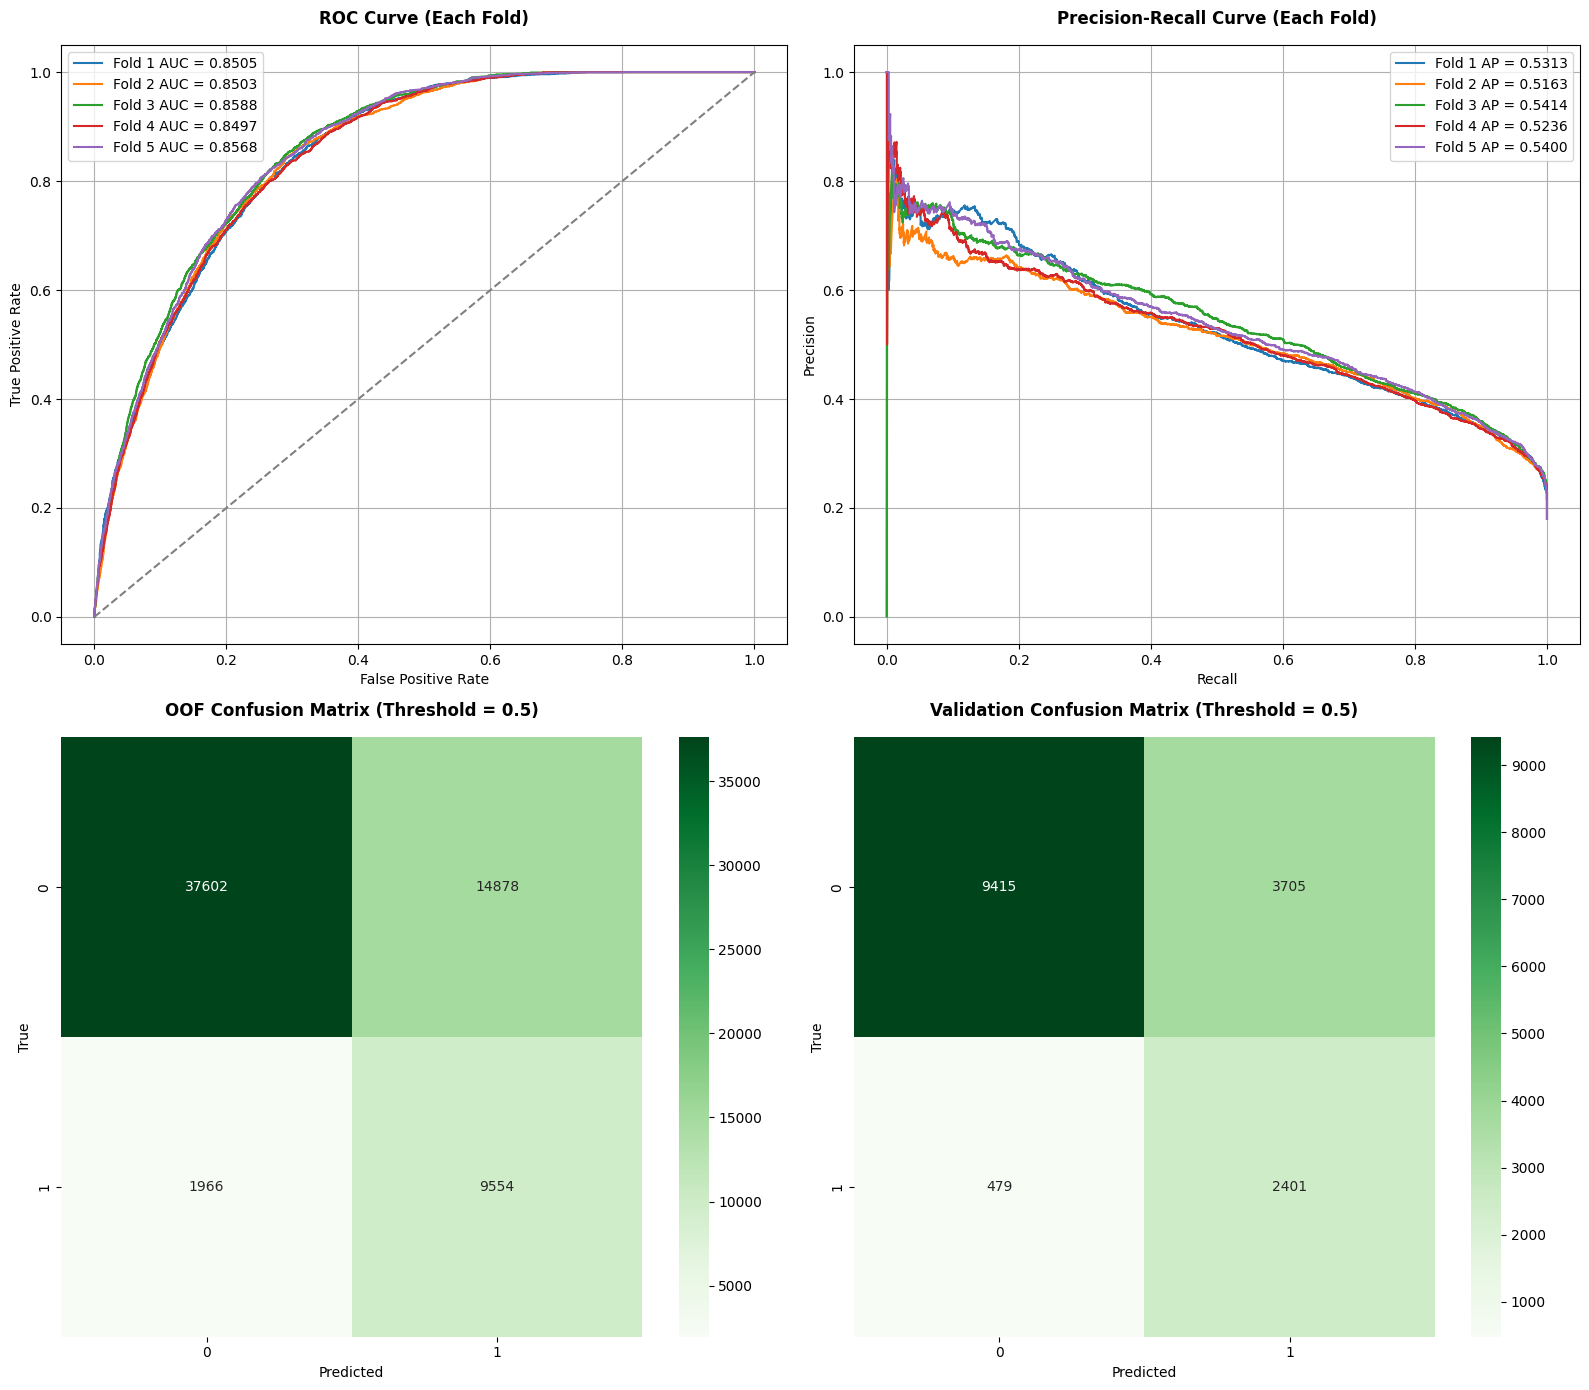

2026-07-24 19:14:01 | INFO     | XGBoost OOF evaluation completed
2026-07-24 19:14:01 | INFO     | --------------------------------------------------------------------------------


In [24]:
logger.info("-" * 80)
logger.info("Starting XGBoost hyperparameter tuning")
study_xgb = optuna.create_study(direction="maximize", study_name="xgboost_churn_tuning")
study_xgb.optimize(
    lambda trial: objective_xgb(
        trial=trial,
        X=X_train,
        y=y_train,
        cat_features=cat_features,
        logger=logger
    ),
    n_trials=10
)

logger.info("XGBoost hyperparameter tuning completed")
logger.info(f"Best CV AUC: {study_xgb.best_value:.5f}")
logger.info(f"Best trial: {study_xgb.best_trial.number}")
logger.info(f"Best parameters: {study_xgb.best_params}")

logger.info("-" * 80)
logger.info("Initializing XGBoost model with best hyperparameters")

# Calculate class imbalance
n_negative = (y == 0).sum()
n_positive = (y == 1).sum()

if n_positive == 0:
    raise ValueError("Target contains no positive samples.")

scale_pos_weight = n_negative / n_positive

model_xgb = XGBClassifier(**study_xgb.best_params, objective="binary:logistic", metric="auc",
                            verbosity=0, n_jobs=-1, boosting_type="gbdt",
                            class_weight="balanced", random_state=CFG.RANDOM_STATE,
                            tree_method="hist", device= "cuda", enable_categorical= True,
                            scale_pos_weight = scale_pos_weight)
logger.info("-" * 80)
logger.info("Starting XGBoost OOF evaluation")
logger.info(
    f"Training samples: {len(X_train):,} | "
    f"Validation samples: {len(X_val):,} | "
    f"Features: {X_train.shape[1]} | "
    f"Categorical features: {len(cat_features)} | "
    f"CV Folds: {CFG.CV['n_splits']}"
)

results_xgb = run_oof(model=model_xgb, X=X_train, y=y_train, X_val=X_val, y_val=y_val, 
                      cat_features=cat_features, logger=logger)
logger.info("XGBoost OOF evaluation completed")
logger.info("-" * 80)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Evaluation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #064e3b, #065f46 35%, #047857 70%, #10b981);
    text-align: center; 
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Evaluation
    </h1>
</div>


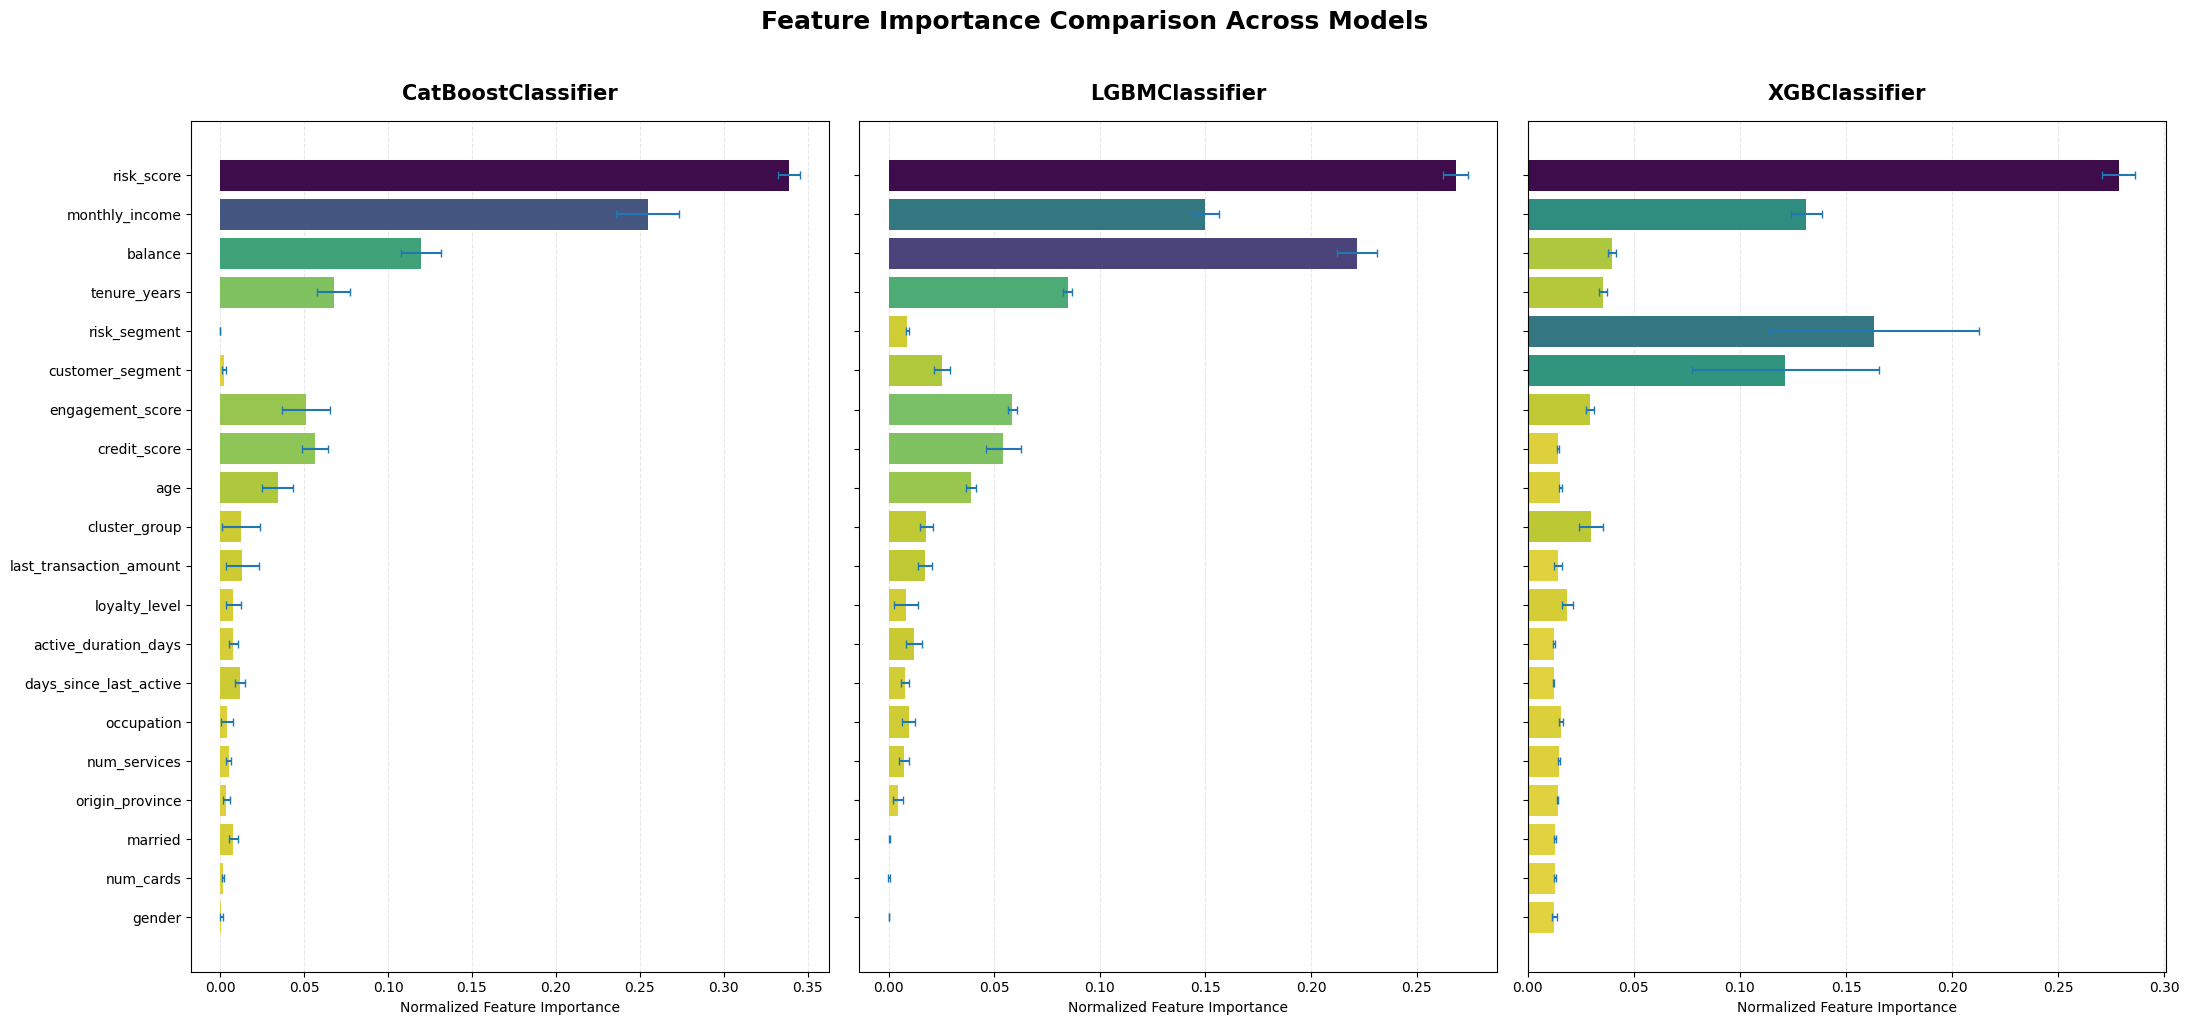

In [36]:
feature_importances = {
    "CatBoostClassifier": results_cb["feature_importance"],
    "LGBMClassifier": results_lgbm["feature_importance"],
    "XGBClassifier": results_xgb["feature_importance"]
}

fig = plot_feature_importance_comparison(
    feature_importances=feature_importances,
    top_n=20,
    figsize=(22, 10),
    show_std=True
)

2026-07-24 19:34:42 | INFO     | Individual model OOF performance
2026-07-24 19:34:42 | INFO     | CatBoost OOF AUC : 0.85514
2026-07-24 19:34:42 | INFO     | LightGBM OOF AUC : 0.85344
2026-07-24 19:34:42 | INFO     | XGBoost OOF AUC  : 0.85316
2026-07-24 19:34:42 | INFO     | AUC-weighted ensemble weights
2026-07-24 19:34:42 | INFO     | CatBoost weight : 0.3338
2026-07-24 19:34:42 | INFO     | LightGBM weight : 0.3331
2026-07-24 19:34:42 | INFO     | XGBoost weight  : 0.3330
2026-07-24 19:34:42 | INFO     | Ensemble performance
2026-07-24 19:34:42 | INFO     | Blended OOF AUC        : 0.85507
2026-07-24 19:34:42 | INFO     | Blended Validation AUC : 0.85601


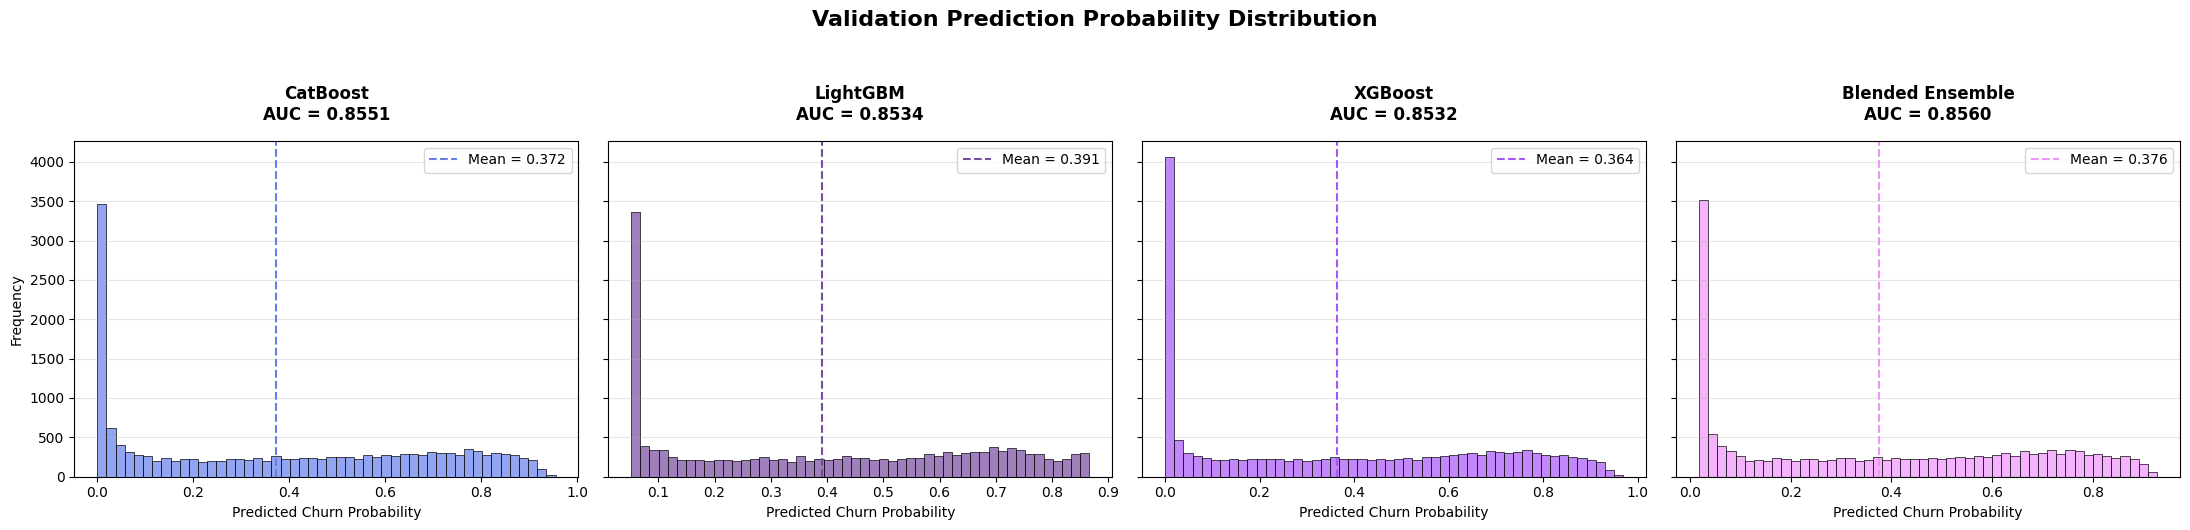

In [ ]:
# Extract OOF and validation predictions
oof_pred_cb = results_cb["oof_pred"]
oof_pred_lgbm = results_lgbm["oof_pred"]
oof_pred_xgb = results_xgb["oof_pred"]

val_pred_cb = results_cb["val_pred"]
val_pred_lgbm = results_lgbm["val_pred"]
val_pred_xgb = results_xgb["val_pred"]

# Calculate OOF ROC-AUC for each model
auc_cb = roc_auc_score(y_train, oof_pred_cb)
auc_lgbm = roc_auc_score(y_train, oof_pred_lgbm)
auc_xgb = roc_auc_score(y_train, oof_pred_xgb)

logger.info("Individual model OOF performance")
logger.info(f"CatBoost OOF AUC : {auc_cb:.5f}")
logger.info(f"LightGBM OOF AUC : {auc_lgbm:.5f}")
logger.info(f"XGBoost OOF AUC  : {auc_xgb:.5f}")

# Calculate AUC-based ensemble weights
total_auc = auc_cb + auc_lgbm + auc_xgb

weight_cb = auc_cb / total_auc
weight_lgbm = auc_lgbm / total_auc
weight_xgb = auc_xgb / total_auc

logger.info("AUC-weighted ensemble weights")
logger.info(f"CatBoost weight : {weight_cb:.4f}")
logger.info(f"LightGBM weight : {weight_lgbm:.4f}")
logger.info(f"XGBoost weight  : {weight_xgb:.4f}")

# Blend OOF predictions
blended_oof = (
    weight_cb * oof_pred_cb
    + weight_lgbm * oof_pred_lgbm
    + weight_xgb * oof_pred_xgb
)

# Blend external validation predictions
blended_val = (
    weight_cb * val_pred_cb
    + weight_lgbm * val_pred_lgbm
    + weight_xgb * val_pred_xgb
)

# Evaluate ensemble
blended_oof_auc = roc_auc_score(y_train, blended_oof)
blended_val_auc = roc_auc_score(y_val, blended_val)

logger.info("Ensemble performance")
logger.info(f"Blended OOF AUC        : {blended_oof_auc:.5f}")
logger.info(f"Blended Validation AUC : {blended_val_auc:.5f}")

# Prediction Distribution Visualization
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
prediction_data = [
    ("CatBoost", val_pred_cb, auc_cb),
    ("LightGBM", val_pred_lgbm, auc_lgbm),
    ("XGBoost",  val_pred_xgb, auc_xgb),
    ("Blended Ensemble", blended_val, blended_val_auc)
]

# Plot distributions
for i, (ax, (model_name, predictions, auc)) in enumerate(zip(axes, prediction_data)):
    sns.histplot(predictions, color=CFG.COLORS[i], alpha=0.7, ax=ax, bins=50)
    ax.axvline(predictions.mean(), color=CFG.COLORS[i], linestyle="--", linewidth=1.5, label=f"Mean = {predictions.mean():.3f}")
    ax.set_title(f"{model_name}\nAUC = {auc:.4f}", fontsize=12, fontweight="bold", pad=15)
    ax.set_xlabel("Predicted Churn Probability", fontsize=10)
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

# Final layout
fig.suptitle("Validation Prediction Probability Distribution", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
xgb_binary = (val_pred_xgb >= 0.5).astype(int)
lgb_binary = (val_pred_lgbm >= 0.5).astype(int)
cat_binary = (val_pred_cb >= 0.5).astype(int)

logger.info("CatBoost Classification Report:")
logger.info("\n" + classification_report(y_val, cat_binary, target_names=["Retained", "Exted"]))
logger.info("*" * 80)

logger.info("LightGBM Classification Report:")
logger.info("\n" + classification_report(y_val, lgb_binary, target_names=["Retained", "Exted"]))
logger.info("*" * 80)

logger.info("XGBoost Classification Report:")
logger.info("\n" + classification_report(y_val, xgb_binary, target_names=['No', 'Yes']))
logger.info("*" * 80)

2026-07-24 19:42:12 | INFO     | CatBoost Classification Report:
2026-07-24 19:42:12 | INFO     | 
              precision    recall  f1-score   support

    Retained       0.95      0.71      0.82     13120
       Exted       0.39      0.84      0.54      2880

    accuracy                           0.74     16000
   macro avg       0.67      0.78      0.68     16000
weighted avg       0.85      0.74      0.77     16000

2026-07-24 19:42:12 | INFO     | ********************************************************************************
2026-07-24 19:42:12 | INFO     | LightGBM Classification Report:
2026-07-24 19:42:12 | INFO     | 
              precision    recall  f1-score   support

    Retained       0.95      0.70      0.81     13120
       Exted       0.39      0.85      0.53      2880

    accuracy                           0.73     16000
   macro avg       0.67      0.78      0.67     16000
weighted avg       0.85      0.73      0.76     16000

2026-07-24 19:42:12 | INFO     | *

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Recommendation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #064e3b, #065f46 35%, #047857 70%, #10b981);
    text-align: center; 
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Recommendation
    </h1>
</div>


<div style="
    background: linear-gradient(135deg, #0b3d2e, #145a32);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.30);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size: 22px;
    font-weight: 600;
    letter-spacing: 0.5px;
">
💡 Business Recommendations
</div>

<table style="
    width:100%;
    border-collapse: collapse;
    background-color: rgba(255,255,255,0.04);
    font-size: 14px;
">

<tr style="background-color: rgba(249,231,159,0.15);">
    <th style="padding:12px; border:1px solid #5d8a72; text-align:left;">
        Priority
    </th>
    <th style="padding:12px; border:1px solid #5d8a72; text-align:left;">
        Recommendation
    </th>
    <th style="padding:12px; border:1px solid #5d8a72; text-align:left;">
        Business Action
    </th>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#ff6b6b;">High</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b>Prioritize customers with elevated risk scores</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Risk Score is the strongest predictive feature across CatBoost,
        LightGBM, and XGBoost. The bank should use it as a core signal in
        churn early-warning systems and prioritize high-risk customers
        for proactive retention campaigns.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#ff6b6b;">High</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b>Protect high-value customer relationships</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Monthly Income and Balance are consistently important across the
        models. High-value customers showing increasing churn risk should
        receive prioritized relationship management, personalized offers,
        and targeted retention incentives.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#ff6b6b;">High</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b>Build a risk-based retention strategy</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Instead of applying the same retention campaign to all customers,
        combine churn probability with Risk Score, Balance, Monthly Income,
        and Customer Segment to identify customers who are both likely to
        leave and economically valuable to retain.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#f9e79f;">Medium</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b>Strengthen early-stage customer relationships</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Tenure Years is consistently useful across all three models, while
        the exploratory analysis indicates better retention among
        longer-tenured customers. The bank should strengthen onboarding
        and early-lifecycle engagement before customer relationships mature.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#f9e79f;">Medium</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b>Improve engagement among vulnerable segments</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Engagement Score contributes meaningful predictive information,
        while the exploratory analysis also identifies differences across
        customer engagement and loyalty groups. Targeted communication,
        personalized offers, and relationship-building programs can be
        focused on customers showing weak engagement.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#f9e79f;">Medium</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b>Use customer segmentation for targeted intervention</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Customer Segment and Risk Segment show strong churn differences in
        exploratory analysis and receive notable importance particularly
        from XGBoost. Retention campaigns should therefore be differentiated
        by segment rather than designed as one-size-fits-all programs.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b style="color:#f9e79f;">Medium</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b>Encourage deeper product and digital engagement</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Number of Services, Loyalty Level, Active Member status, and Digital
        Behavior have relatively low standalone model importance, but the
        exploratory analysis shows meaningful retention differences across
        these groups. They can therefore support cross-selling, loyalty,
        and digital-engagement strategies rather than serve as primary
        churn triggers.
    </td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b>Low</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        <b>Avoid over-targeting weak demographic signals</b>
    </td>
    <td style="padding:10px; border:1px solid #5d8a72;">
        Gender, Origin Province, and Marital Status contribute little
        predictive information across the models and show limited practical
        churn differences. Retention resources should therefore be allocated
        primarily using behavioral, financial, and risk-related indicators.
    </td>
</tr>

</table>

<div style="
    margin-top:20px;
    padding:15px 18px;
    background-color:rgba(0,0,0,0.18);
    border-radius:8px;
    line-height:1.6;
">
    <b style="color:#f9e79f;">🎯 Recommended Retention Framework:</b><br>
    Use the churn model to identify customers with high predicted churn
    probability, then prioritize interventions based on
    <b>Risk Score → Customer Value (Balance / Income) → Tenure & Engagement
    → Customer Segment</b>. This allows the bank to focus retention spending
    on customers where intervention is both necessary and economically valuable.
</div>

<div style="
    margin-top:15px;
    padding:15px 18px;
    background-color:rgba(249,231,159,0.10);
    border-left:4px solid #f9e79f;
    border-radius:6px;
    line-height:1.6;
">
    <b style="color:#f9e79f;">⚠️ Interpretation Note:</b><br>
    Feature importance indicates how strongly a variable contributes to model
    predictions; it does not establish that the feature causes churn.
    Retention decisions should therefore combine model predictions with
    business context and customer-level economic value.
</div>

</div>


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #064e3b, #065f46 35%, #047857 70%, #10b981);
    text-align: center; 
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy coding 🙌😊
    </p>
</div>
